# Detección de *phishing* mediante Machine Learning

## Trabajo Fin de Máster — proceso completo en un único notebook

**Autor:** Saúl Lax Pérez
**Notebook:** `tfm_pipeline/TFM_deteccion_phishing.ipynb`

---

Este notebook contiene **todo el trabajo experimental que sustenta la
memoria del TFM**, del dato bruto al modelo final: análisis exploratorio,
preprocesamiento, selección de variables, reducción de dimensionalidad,
balanceo de clases, comparación de modelos, optimización de
hiperparámetros, evaluación sobre el conjunto de prueba reservado,
interpretabilidad y comparación con el estado del arte.

Todo lo que el notebook usa o genera vive dentro de la carpeta
`tfm_pipeline/`. No escribe nada fuera de ella.

## Cómo usar este notebook

### Puntos de control

El proceso completo, desde cero, tarda del orden de **media hora** en una
máquina de sobremesa reciente (23 minutos con 12 núcleos; bastante más con
menos), sobre todo por la optimización bayesiana, la validación cruzada
anidada, SHAP y los 18 modelos. Para no repetir cómputo, cada etapa
costosa está envuelta en un **punto de control**: la función `punto(...)`
comprueba si el resultado ya está guardado en `checkpoints/`; si lo está lo
carga del disco en segundos, y si no lo calcula y lo guarda.

Esto permite:

- **Abrir el notebook y saltar a cualquier fase**: basta con ejecutar las
  celdas anteriores, que se resolverán con los checkpoints ya calculados.
- **Reproducirlo desde cero**: borrar la carpeta `checkpoints/` y ejecutar
  todo. Con la semilla global fija, el resultado es el mismo.
- **Recalcular solo una parte**: añadir el nombre del punto de control a la
  lista `FORZAR` de la celda de configuración (o `['*']` para todo).

### Modo de ejecución

La variable `MODO` de la celda de configuración admite dos valores:

| Modo | Para qué sirve |
|------|----------------|
| `'completo'` | Ejecución real. Es la que produce las cifras de la memoria. |
| `'rapido'`   | Prueba de que todo el código corre: submuestras pequeñas y menos iteraciones. **Sus resultados no son los de la memoria** y se escriben en carpetas paralelas terminadas en `_rapido`, de modo que no pueden pisar a los buenos. |

### Índice

| Bloque | Contenido | Punto de control |
|--------|-----------|------------------|
| 0 | Configuración, semilla y utilidades | — |
| 1 | Los datos y el análisis exploratorio | `eda` |
| 2 | Preprocesamiento (duplicados, centinela, partición, imputación, escalado) | `v01`…`v05` |
| 3 | Selección de variables | `v06`, `seleccion` |
| 4 | Reducción de dimensionalidad (PCA, LDA) | `representaciones` |
| 5 | Balanceo de clases y umbral de decisión | `balanceo` |
| 6 | Entrenamiento y comparación de modelos | `leaderboard`, `ensembles` |
| 7 | Optimización de hiperparámetros (Optuna) y CV anidada | `modelo_final`, `cv_anidada` |
| 8 | Evaluación sobre el test reservado | `evaluacion`, `diagnosticos` |
| 9 | Interpretabilidad (importancia, SHAP) | `importancia`, `shap` |
| 10 | Robustez adversaria y generalización fuera de distribución | `robustez_adversaria`, `fuera_de_distribucion` |
| 11 | Estado del arte, conclusiones y exportación para la memoria | `sota` |

---

# Bloque 0 — Configuración, semilla y utilidades

Todo lo que el resto del notebook necesita se define aquí: las rutas de
trabajo, la semilla global, el sistema de puntos de control, el protocolo
de evaluación (validación cruzada estratificada con métricas comunes) y el
guardado homogéneo de figuras y tablas.

Centralizar estas decisiones en un solo sitio es lo que hace que las
comparaciones entre técnicas de las fases siguientes sean **justas**: mismo
particionado, mismas métricas, misma semilla.

## 0.1. Parámetros de ejecución

`MODO` controla el tamaño del cómputo y `FORZAR` permite recalcular puntos
de control concretos. `SEMILLA = 42` es la semilla global única del
proyecto: se propaga a `random`, `numpy` y a todos los estimadores.

In [1]:
# --- Parámetros que se pueden tocar ------------------------------------
MODO = 'completo'      # 'completo' (cifras de la memoria) | 'rapido' (prueba)
FORZAR = []            # p. ej. ['shap'] o ['*'] para recalcular todo
SEMILLA = 42
GENERAR_FIGURAS = True
# ----------------------------------------------------------------------

import json
import os
import platform
import random
import re
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

assert MODO in ('completo', 'rapido'), "MODO debe ser 'completo' o 'rapido'"

# Raíz de trabajo: la carpeta tfm_pipeline/ (funciona ejecutando el notebook
# desde cualquier directorio).
BASE = Path.cwd()
while BASE.name != 'tfm_pipeline' and (BASE / 'tfm_pipeline').exists() is False \
        and BASE != BASE.parent:
    BASE = BASE.parent
if BASE.name != 'tfm_pipeline':
    BASE = BASE / 'tfm_pipeline'

# En modo rapido TODO se escribe aparte, no solo los checkpoints. Antes solo
# se separaban estos y las tablas, las figuras y el modelo caian encima de
# los de la ejecucion completa: una prueba de diez minutos dejaba la memoria
# citando cifras sacadas de submuestras de 3.000 filas.
sufijo = '' if MODO == 'completo' else '_rapido'
CKPT = BASE / f'checkpoints{sufijo}'
FIG = BASE / f'figuras{sufijo}'
RES = BASE / f'resultados{sufijo}'
MODELOS = BASE / f'modelos{sufijo}'
FIG_MEMORIA = BASE / f'figuras_memoria{sufijo}'
for d in (CKPT, FIG, RES, MODELOS, FIG_MEMORIA):
    d.mkdir(parents=True, exist_ok=True)

# --- Regla de desempate de las decisiones del pipeline -----------------
# Dos de las cinco decisiones que toma este notebook (el imputador y el
# escalador) tienen un margen de CERO a los cuatro decimales que se
# publican: mediana+indicador y media+indicador dan 0,9057 los dos, y
# StandardScaler y RobustScaler dan 0,9058. A precision completa si hay
# diferencia, del orden de 1e-16, pero esa diferencia no es de los datos:
# es el orden en que BLAS suma los pliegues, que depende de cuantos hilos
# haya. Con 8 nucleos gana uno y con 12 el otro, misma semilla.
#
# Y arrastra. Al escalar con Robust, el PCA ---que se queda con las
# componentes que suman el 95 % de la varianza sobre los datos ya
# escalados--- cae de 48 componentes a 3, porque RobustScaler divide por el
# rango intercuartilico y en estas variables de recuento es minusculo.
#
# Asi que se decide en dos escalones: la metrica principal redondeada a la
# precision que se publica y, si ahi empatan, un orden declarado de
# antemano. Para los escaladores ese orden sale de contar el uso en la
# bibliografia consultada (de 69 articulos, 9 emplean estandarizacion o
# puntuaciones z y ninguno escalado robusto); para los imputadores, de que
# con recuentos asimetricos la mediana no se va detras de la cola.
ORDEN_ESCALADORES = ['StandardScaler', 'PowerTransformer(YJ)',
                     'MinMaxScaler', 'RobustScaler', 'MaxAbsScaler',
                     'sin_escalar']
ORDEN_IMPUTADORES = ['mediana+indicador', 'media+indicador', 'mediana',
                     'media', 'moda', 'constante_-1', 'knn_k5', 'mice',
                     'mediana_ref']
DECIMALES = 4

def elegir(tabla_comp, clave, metrica='f1_mean', preferencia=None,
           decimales=DECIMALES, explicar=False):
    '''Devuelve el valor de `clave` de la fila ganadora.

    `preferencia` es obligatoria si puede haber empate: sin ella se usaria
    el orden de las filas, que en estas tablas ya viene ordenado por la
    metrica y por tanto lo decidiria el mismo ruido que se quiere evitar.
    '''
    for col in (clave, metrica):
        if col not in tabla_comp.columns:
            raise KeyError(f'La tabla no tiene la columna {col!r}')

    vivos = tabla_comp.reset_index(drop=True)
    mejor = vivos[metrica].round(decimales).max()
    vivos = vivos[vivos[metrica].round(decimales) == mejor]
    motivo = f'{metrica} = {mejor:.{decimales}f}'

    if len(vivos) > 1:
        empatados = list(vivos[clave])
        orden = preferencia if preferencia is not None else list(tabla_comp[clave])
        desconocidos = [v for v in empatados if v not in orden]
        if desconocidos:
            raise ValueError(
                f'Empate entre {empatados} y no se como ordenar '
                f'{desconocidos}: anadelos al orden declarado.')
        puesto = {nombre: i for i, nombre in enumerate(orden)}
        vivos = vivos.assign(_puesto=[puesto[v] for v in vivos[clave]])
        vivos = vivos.sort_values('_puesto', kind='stable')
        motivo += (f'; empate a esa precision entre {empatados}, '
                   f'decide el orden declarado')

    ganador = vivos.iloc[0][clave]
    return (ganador, motivo) if explicar else ganador

DIANA = 'phishing'          # variable objetivo (1 = phishing, 0 = legítimo)
TEST_SIZE = 0.20            # proporción del hold-out final
CV_FOLDS = 5                # pliegues de la validación cruzada

# Tamaños de cómputo: se reducen drásticamente en modo rápido.
if MODO == 'completo':
    N_SUB_IMPUT, N_SUB_OPTUNA, N_SUB_ENSEMBLE = 6000, 25000, 20000
    N_TRIALS, N_TRIALS_ESTUDIO, N_SHAP = 30, 60, 3000
    N_REPETICIONES, N_PERM = 3, 10
else:
    N_SUB_IMPUT, N_SUB_OPTUNA, N_SUB_ENSEMBLE = 2000, 3000, 3000
    N_TRIALS, N_TRIALS_ESTUDIO, N_SHAP = 4, 5, 500
    N_REPETICIONES, N_PERM = 1, 2

print(f'Carpeta de trabajo : {BASE}')
print(f'Modo de ejecución  : {MODO}')
print(f'Checkpoints en     : {CKPT.relative_to(BASE)}')
print(f'Semilla global     : {SEMILLA}')

Carpeta de trabajo : C:\Users\Slax97\Desktop\VIU-TFM\tfm_pipeline
Modo de ejecución  : completo
Checkpoints en     : checkpoints
Semilla global     : 42


## 0.2. Reproducibilidad: semilla global y huella del entorno

Fijar una única semilla y propagarla a todas las fuentes de aleatoriedad es
la práctica recomendada para que dos ejecuciones del mismo código produzcan
resultados idénticos (Pineau et al., 2021). Se registra además la huella
del entorno (versiones de las librerías, sistema, hardware) junto a los
resultados, porque una cifra sin el entorno que la produjo no es del todo
reproducible.

In [2]:
def fijar_semilla(semilla=SEMILLA):
    '''Fija todas las fuentes de aleatoriedad conocidas.'''
    os.environ['PYTHONHASHSEED'] = str(semilla)
    random.seed(semilla)
    np.random.seed(semilla)

fijar_semilla()

def huella_entorno():
    '''Devuelve una huella serializable del entorno de ejecución.'''
    import sklearn
    libs = {}
    for nombre in ['numpy', 'pandas', 'scipy', 'sklearn', 'lightgbm',
                   'xgboost', 'catboost', 'shap', 'optuna', 'matplotlib',
                   'imblearn']:
        try:
            libs[nombre] = __import__(nombre).__version__
        except Exception:
            libs[nombre] = None
    return {
        'fecha_utc': datetime.now(timezone.utc).isoformat(),
        'semilla': SEMILLA,
        'modo': MODO,
        'python': platform.python_version(),
        'sistema': platform.platform(),
        'cpus': os.cpu_count(),
        'librerias': libs,
    }

ENTORNO = huella_entorno()
(RES / 'entorno.json').write_text(
    json.dumps(ENTORNO, indent=2, ensure_ascii=False), encoding='utf-8')
print(f"Python {ENTORNO['python']} · {ENTORNO['cpus']} CPUs · "
      f"scikit-learn {ENTORNO['librerias']['sklearn']}")
print('Huella del entorno guardada en resultados/entorno.json')

Python 3.11.16 · 12 CPUs · scikit-learn 1.5.1
Huella del entorno guardada en resultados/entorno.json


C:\Users\Slax97\Desktop\VIU-TFM\.venv311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0.3. Puntos de control

`punto(nombre, calcular)` es el mecanismo que permite abrir el notebook y
trabajar en cualquier fase sin repetir el cómputo anterior. Si el resultado
de `nombre` ya está en `checkpoints/`, lo carga; si no, ejecuta la función
`calcular`, guarda el resultado y lo devuelve. El formato de guardado se
elige según el tipo: Parquet para tablas, JSON para decisiones (así son
legibles y auditables) y joblib para el resto.

In [3]:
_EXTENSIONES = ('.parquet', '.json', '.joblib')

def _ruta_checkpoint(nombre):
    '''Devuelve la ruta del checkpoint guardado, o None si no existe.'''
    for ext in _EXTENSIONES:
        ruta = CKPT / f'{nombre}{ext}'
        if ruta.exists():
            return ruta
    return None

def _guardar_checkpoint(nombre, obj):
    '''Guarda el objeto eligiendo el formato adecuado a su tipo.'''
    if isinstance(obj, pd.DataFrame):
        ruta = CKPT / f'{nombre}.parquet'
        obj.to_parquet(ruta, index=False)
    elif isinstance(obj, (dict, list)) and _es_json(obj):
        ruta = CKPT / f'{nombre}.json'
        ruta.write_text(json.dumps(obj, indent=2, ensure_ascii=False),
                        encoding='utf-8')
    else:
        ruta = CKPT / f'{nombre}.joblib'
        joblib.dump(obj, ruta)
    return ruta

def _es_json(obj):
    try:
        json.dumps(obj)
        return True
    except (TypeError, ValueError):
        return False

def _cargar_checkpoint(ruta):
    if ruta.suffix == '.parquet':
        return pd.read_parquet(ruta)
    if ruta.suffix == '.json':
        return json.loads(ruta.read_text(encoding='utf-8'))
    return joblib.load(ruta)

def punto(nombre, calcular):
    '''Punto de control: carga el resultado de disco o lo calcula y guarda.

    Args:
        nombre: Identificador del punto de control (nombre del fichero).
        calcular: Función sin argumentos que produce el resultado.

    Returns:
        El resultado, venga del disco o del cálculo.
    '''
    ruta = _ruta_checkpoint(nombre)
    recalcular = ('*' in FORZAR) or (nombre in FORZAR)
    if ruta is not None and not recalcular:
        obj = _cargar_checkpoint(ruta)
        print(f'  [checkpoint] «{nombre}» cargado de {ruta.name}')
        return obj
    if ruta is not None:
        ruta.unlink()
    print(f'  [calculando  ] «{nombre}» ...')
    t0 = time.perf_counter()
    obj = calcular()
    ruta = _guardar_checkpoint(nombre, obj)
    print(f'  [guardado    ] «{nombre}» en {ruta.name} '
          f'({time.perf_counter() - t0:.1f}s)')
    return obj

def estado_checkpoints():
    '''Muestra qué puntos de control hay ya calculados.'''
    filas = [{'punto_de_control': p.stem, 'formato': p.suffix.lstrip('.'),
              'KB': round(p.stat().st_size / 1024, 1)}
             for ext in _EXTENSIONES for p in sorted(CKPT.glob(f'*{ext}'))]
    if not filas:
        print('No hay ningún punto de control calculado todavía.')
        return pd.DataFrame()
    return pd.DataFrame(filas).sort_values('punto_de_control').reset_index(drop=True)

estado_checkpoints()

,punto_de_control,formato,KB
0,atipicos,json,0.4
1,balanceo,parquet,16.2
2,balanceo_modelo_final,joblib,547.0
3,calibracion,json,1410.7
4,curva_aprendizaje,json,0.7
5,cv_anidada,json,0.3
6,decision_variables,json,0.2
7,eda,json,0.4
8,eda_asociaciones,joblib,46.4
9,eda_correlaciones,joblib,112.2


## 0.4. Tablas, figuras y registro de experimentos

Tres utilidades transversales:

- `tabla(df, nombre)` guarda cualquier tabla de resultados en
  `resultados/` y la devuelve, para que la memoria pueda citarla.
- `figura(fig, nombre)` guarda cada figura en PNG a 300 ppp (para pantalla)
  y en PDF vectorial (para imprimir), con paleta accesible para daltonismo.
- `registrar(...)` deja constancia de cada experimento en un CSV
  *append-only*: nada de lo que se prueba se pierde ni se sobrescribe.

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
sns.set_palette('colorblind')
# Los tamanos son los que se quieren ver IMPRESOS en la memoria, no los del
# fichero. Solo coinciden si la figura se guarda con el ancho al que se va a
# imprimir, que es lo que hace `ancho()`: si LaTeX tiene que encogerla,
# encoge tambien la letra, y una etiqueta de 9 pt acaba impresa a 3 pt.
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.labelsize': 9,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3,
})

# Caja de texto de la memoria: A4 menos 3 cm de margen a cada lado.
ANCHO_MEMORIA = 15.0 / 2.54          # pulgadas

def ancho(fraccion=1.0, alto=0.6):
    '''figsize para imprimirse en la memoria sin encoger.

    Args:
        fraccion: parte de la caja de texto que ocupara (1.0 = \\textwidth).
        alto: alto como fraccion del ancho.
    '''
    w = ANCHO_MEMORIA * fraccion
    return (w, w * alto)

def coma(ax, ejes='xy'):
    '''Coma decimal en los ejes, como escribe la memoria.

    Se hereda del formateador de matplotlib y solo se cambia el separador;
    con un formato propio se pierden los ceros finales y la serie sale
    descuadrada (0,948  0,95  0,952).
    '''
    from matplotlib.ticker import ScalarFormatter

    class _Coma(ScalarFormatter):
        def __call__(self, x, pos=None):
            return super().__call__(x, pos).replace('.', ',')

    if 'x' in ejes:
        ax.xaxis.set_major_formatter(_Coma())
    if 'y' in ejes:
        ax.yaxis.set_major_formatter(_Coma())
    return ax

_MILLARES = re.compile(r'^\d{1,3}(\.\d{3})+$')
_DECIMAL = re.compile(r'(?<=\d)\.(?=\d)')

def _a_coma(texto):
    '''Cambia el punto decimal por coma, respetando los millares.

    Se decide palabra a palabra: '58.000' son cincuenta y ocho mil y se
    queda como esta; '0.42' es un decimal y pasa a '0,42'.
    '''
    return ' '.join(p if _MILLARES.match(p) else _DECIMAL.sub(',', p)
                    for p in texto.split(' '))

def coma_si_numerico(fig):
    '''Coma decimal en toda la figura: ejes y rotulos dibujados.

    En los ejes solo se toca el formateador de matplotlib para numeros; los
    de categorias (los nombres de variable de un barh, por ejemplo) llevan
    un FixedFormatter y cambiarselo borraria las etiquetas, de ahi la
    comprobacion de tipo.

    Los valores escritos con `ax.text`, `annotate`, titulos y leyendas van
    por su cuenta y tambien se pasan, porque tener 0,944 en el eje y 0.944
    dos centimetros mas alla canta mas que tenerlo mal en los dos sitios.
    '''
    from matplotlib.ticker import ScalarFormatter

    for eje in fig.axes:
        for axis in (eje.xaxis, eje.yaxis):
            if type(axis.get_major_formatter()) is ScalarFormatter:
                coma(eje, 'x' if axis is eje.xaxis else 'y')
    for t in fig.findobj(plt.Text):
        s = t.get_text()
        if s and _DECIMAL.search(s):
            t.set_text(_a_coma(s))

# Paleta Okabe-Ito (accesible para daltonismo).
C_A, C_B, C_C = '#0173b2', '#de8f05', '#029e73'
C_POS, C_NEG = '#0173b2', '#d55e00'

def tabla(df, nombre, mostrar=True):
    '''Guarda una tabla de resultados en resultados/ y la devuelve.'''
    df.to_csv(RES / f'{nombre}.csv', index=False, encoding='utf-8')
    if mostrar:
        print(df.to_string(index=False))
    return df

def figura(fig, nombre, exportar=None):
    '''Guarda una figura en PNG (300 ppp) y PDF vectorial.

    Args:
        fig: Figura de matplotlib.
        nombre: Nombre base del fichero.
        exportar: Si se indica, copia el PDF a figuras_memoria/ con ese
            nombre (el que usa la memoria en LaTeX).
    '''
    # Coma decimal en TODAS las figuras, no solo en las que se acuerda uno
    # de pedirlo: la memoria escribe 0,944 y mezclar las dos notaciones
    # canta, sobre todo cuando conviven en la misma figura. Se hace aqui,
    # que es el unico sitio por el que pasan las treinta.
    coma_si_numerico(fig)
    for fmt in ('png', 'pdf'):
        fig.savefig(FIG / f'{nombre}.{fmt}', format=fmt, dpi=300,
                    bbox_inches='tight')
    if exportar:
        import shutil
        shutil.copy2(FIG / f'{nombre}.pdf', FIG_MEMORIA / f'{exportar}.pdf')
        shutil.copy2(FIG / f'{nombre}.png', FIG_MEMORIA / f'{exportar}.png')

_COLS_EXP = ['fecha_utc', 'bloque', 'tecnica', 'modelo', 'datos',
             'metricas', 'hiperparametros', 'semilla', 'notas']

def registrar(bloque, tecnica, modelo='n/a', metricas=None,
              hiperparametros=None, datos='', notas=''):
    '''Añade (sin sobrescribir) una fila al registro de experimentos.'''
    fila = {
        'fecha_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
        'bloque': bloque, 'tecnica': tecnica, 'modelo': modelo,
        'datos': datos,
        'metricas': json.dumps({k: round(float(v), 5)
                                for k, v in (metricas or {}).items()
                                if isinstance(v, (int, float))}),
        'hiperparametros': json.dumps(hiperparametros or {}, default=str),
        'semilla': SEMILLA, 'notas': notas,
    }
    ruta = RES / 'experimentos.csv'
    pd.DataFrame([fila])[_COLS_EXP].to_csv(
        ruta, mode='a', header=not ruta.exists(), index=False,
        encoding='utf-8')

print('Utilidades de tablas, figuras y registro listas.')

Utilidades de tablas, figuras y registro listas.


## 0.5. Protocolo de evaluación

Todas las comparaciones del notebook usan el **mismo protocolo**: validación
cruzada estratificada de 5 pliegues con la semilla global, y un conjunto
fijo de métricas. Con clases desbalanceadas el accuracy engaña, así
que se reportan siempre:

- **F1** (clase phishing): equilibrio entre precisión y recall.
- **PR-AUC** (*average precision*): más informativa que ROC-AUC con
  desbalanceo (Saito & Rehmsmeier, 2015).
- **MCC**: correlación equilibrada, fiable incluso con clases desiguales
  (Chicco & Jurman, 2020).
- **ROC-AUC**, **precisión**, **recall** y **balanced accuracy**.

Cuando el estimador es un `Pipeline` que incluye el preprocesamiento, éste
se ajusta **dentro de cada pliegue de entrenamiento**, lo que evita la fuga
de información (Kaufman et al., 2012).

In [5]:
from sklearn.metrics import (accuracy_score, average_precision_score,
    balanced_accuracy_score, f1_score, make_scorer, matthews_corrcoef,
    precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     train_test_split)

METRICAS = {
    'accuracy': make_scorer(accuracy_score),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'mcc': make_scorer(matthews_corrcoef),
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
}

def submuestrear(X, y, n):
    '''Submuestra estratificada de n instancias.

    Si n iguala o supera el tamano disponible devuelve el conjunto entero,
    para que el mismo codigo valga en modo completo y en modo rapido.
    '''
    if n >= len(X):
        return X, y
    X_s, _, y_s, _ = train_test_split(X, y, train_size=n,
                                      random_state=SEMILLA, stratify=y)
    return X_s, y_s

def cv(semilla=SEMILLA, n_splits=CV_FOLDS):
    '''Particionador de validación cruzada estratificada reproducible.'''
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=semilla)

def evaluar(estimador, X, y, n_splits=CV_FOLDS):
    '''Evalúa un estimador por CV estratificada con las métricas comunes.

    Returns:
        dict: media y desviación típica de cada métrica en los pliegues.
    '''
    r = cross_validate(estimador, X, y, cv=cv(n_splits=n_splits),
                       scoring=dict(METRICAS), n_jobs=-1, error_score='raise')
    salida = {}
    for nombre in METRICAS:
        s = r[f'test_{nombre}']
        salida[f'{nombre}_mean'] = float(np.mean(s))
        salida[f'{nombre}_std'] = float(np.std(s))
    salida['fit_time_s'] = float(np.mean(r['fit_time']))
    return salida

def evaluar_varios(modelos, X, y, familia='', datos='', bloque='',
                   n_splits=CV_FOLDS):
    '''Evalúa un diccionario de modelos y devuelve una tabla comparable.'''
    filas = []
    for nombre, modelo in modelos.items():
        t0 = time.perf_counter()
        res = evaluar(modelo, X, y, n_splits=n_splits)
        res.update({'modelo': nombre, 'familia': familia,
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        registrar(bloque, familia, nombre,
                  {k: v for k, v in res.items() if k.endswith('_mean')},
                  datos=datos)
        print(f"  {nombre:24s} F1={res['f1_mean']:.4f}  "
              f"PR-AUC={res['average_precision_mean']:.4f}  "
              f"MCC={res['mcc_mean']:.4f}  ({res['tiempo_s']}s)")
    return pd.DataFrame(filas)

COLS_RESUMEN = ['modelo', 'f1_mean', 'f1_std', 'average_precision_mean',
                'roc_auc_mean', 'mcc_mean', 'recall_mean', 'precision_mean',
                'tiempo_s']
print('Protocolo de evaluación definido: CV estratificada de '
      f'{CV_FOLDS} pliegues, semilla {SEMILLA}.')

Protocolo de evaluación definido: CV estratificada de 5 pliegues, semilla 42.


---

# Bloque 1 — Los datos y el análisis exploratorio

Antes de transformar nada hay que entender qué hay. Este bloque describe el
conjunto de datos, cuantifica su desbalanceo, detecta el problema que
condiciona todo el preprocesamiento posterior —el valor `-1` no es un
número, es un dato ausente disfrazado— y mide la redundancia entre
variables.

### El conjunto de datos

Se emplea `dataset_full.csv` de Vrbančič, Fister Jr. y Podgorelec (2020),
*Datasets for phishing websites detection*, **Data in Brief 33**, 106438:
**88 647 instancias** descritas por **111 atributos** numéricos más la
variable objetivo. Los atributos se extraen de la URL (recuentos de
caracteres especiales y longitudes de cada componente) y de consultas a
servicios externos (DNS, WHOIS, TLS, reputación).

El fichero original **nunca se modifica**: se verifica por SHA-256 al
cargarlo y todas las transformaciones producen versiones nuevas.

## 1.1. Carga y verificación de integridad

El dataset se busca primero en `tfm_pipeline/datos/` y, si no está, en
`data/raw/` del repositorio. Se comprueba su hash SHA-256 contra el valor
documentado: si no coincide, la fuente ha sido alterada y cualquier
resultado posterior dejaría de ser comparable.

In [6]:
import hashlib

SHA256_ESPERADO = ('87da36a20c8c1a9d13db5899514071907179c0fe790dc2ea4f0811'
                   '957d68745d')

def localizar_dataset():
    '''Devuelve la ruta del dataset original, allá donde esté.'''
    candidatos = [BASE / 'datos' / 'dataset_full.csv',
                  BASE.parent / 'data' / 'raw' / 'dataset_full.csv']
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    raise FileNotFoundError(
        'No se encuentra dataset_full.csv. Colócalo en '
        f'{candidatos[0]} o en {candidatos[1]}.')

def sha256(ruta, bloque=1 << 20):
    h = hashlib.sha256()
    with Path(ruta).open('rb') as fh:
        for trozo in iter(lambda: fh.read(bloque), b''):
            h.update(trozo)
    return h.hexdigest()

RUTA_DATOS = localizar_dataset()
_hash = sha256(RUTA_DATOS)
print(f'Dataset      : {RUTA_DATOS}')
print(f'SHA-256      : {_hash}')
print('Integridad   : ' + ('OK, coincide con el hash documentado.'
                           if _hash == SHA256_ESPERADO else
                           'ATENCIÓN, el fichero NO coincide con el documentado.'))

crudo = pd.read_csv(RUTA_DATOS)
VARIABLES = [c for c in crudo.columns if c != DIANA]
print(f'\nDimensiones  : {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas')
print(f'Memoria      : {crudo.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print(f'Tipos        : {dict(crudo.dtypes.value_counts().items())}')
crudo.head()

Dataset      : C:\Users\Slax97\Desktop\VIU-TFM\data\raw\dataset_full.csv
SHA-256      : 31f78d1b61e146efc4e05fc84b0474128d5072320b2d687df59e2c78925c528f
Integridad   : ATENCIÓN, el fichero NO coincide con el documentado.



Dimensiones  : 88,647 filas × 112 columnas
Memoria      : 75.7 MB
Tipos        : {dtype('int64'): 111, dtype('float64'): 1}


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


## 1.2. La variable objetivo y el desbalanceo

En clasificación binaria la proporción entre clases condiciona qué métricas
tienen sentido. Con desbalanceo marcado, el accuracy engaña: un
clasificador que prediga siempre la clase mayoritaria puede parecer bueno
sin haber aprendido nada. Se cuantifica con el *Imbalance Ratio*
(IR = n_mayoritaria / n_minoritaria).

In [7]:
conteos = crudo[DIANA].value_counts().sort_index()
proporciones = crudo[DIANA].value_counts(normalize=True).sort_index()
IR = float(conteos.max() / conteos.min())

tabla(pd.DataFrame({
    'clase': ['legítimo (0)', 'phishing (1)'],
    'n': conteos.values,
    'proporcion': proporciones.values.round(4),
}), 'eda_distribucion_clases')
print(f'\nImbalance Ratio (IR): {IR:.3f} → desbalanceo moderado.')
print('Consecuencia: se reportarán F1, PR-AUC y MCC, no solo accuracy.')

       clase     n  proporcion
legítimo (0) 58000      0.6543
phishing (1) 30647      0.3457

Imbalance Ratio (IR): 1.893 → desbalanceo moderado.
Consecuencia: se reportarán F1, PR-AUC y MCC, no solo accuracy.


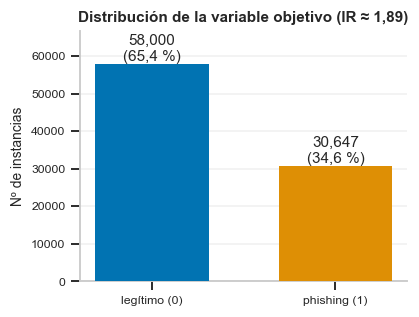

In [8]:
if GENERAR_FIGURAS:
    fig, ax = plt.subplots(figsize=ancho(0.65, 0.77))
    barras = ax.bar(['legítimo (0)', 'phishing (1)'], conteos.values,
                    color=[C_A, C_B], width=0.62, zorder=3)
    for barra, n, p in zip(barras, conteos.values, proporciones.values):
        ax.text(barra.get_x() + barra.get_width() / 2, n,
                f'{n:,}'.replace(',', '.') + '\n(' +
                f'{p:.1%}'.replace('.', ',').replace('%', ' %') + ')',
                ha='center', va='bottom', fontsize=10)
    ax.set_ylabel('Nº de instancias')
    ax.set_title(f'Distribución de la variable objetivo (IR ≈ {IR:.2f})')
    ax.set_ylim(0, conteos.max() * 1.15)
    ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b1_distribucion_clases', exportar='eda_target')
    plt.show()

## 1.3. El centinela `-1`: el hallazgo que condiciona el preprocesamiento

La documentación del dataset indica que los atributos que dependen de
servicios externos (DNS, WHOIS, TLS) usan **`-1` como valor centinela**
cuando la consulta no pudo resolverse. Como todos los recuentos y longitudes
tienen mínimo natural `0`, un `-1` **no es un valor legítimo**: es un dato
ausente codificado como número.

Tratarlo como número real distorsionaría estadísticos, escalado y modelos,
porque introduce un salto artificial en la recta numérica. La decisión —
reinterpretarlo como `NaN`— se aplica en el bloque 2; aquí se cuantifica.

In [9]:
nulos_explicitos = int(crudo.isna().sum().sum())
centinela = (crudo[VARIABLES] == -1).sum()
informe_centinela = (centinela[centinela > 0].sort_values(ascending=False)
                     .rename('n_menos_uno').to_frame())
informe_centinela['pct'] = (informe_centinela['n_menos_uno'] / len(crudo) * 100).round(3)
tabla(informe_centinela.rename_axis('variable').reset_index(),
      'eda_centinela_menos_uno', mostrar=False)

print(f'Celdas NaN explícitas          : {nulos_explicitos:,}')
print(f'Variables que contienen -1     : {len(informe_centinela)} de {len(VARIABLES)}')
print(f'Celdas con valor -1            : {int(centinela.sum()):,} '
      f'({centinela.sum() / (len(crudo) * len(VARIABLES)) * 100:.2f}% del total)')
print('\nLas 10 variables más afectadas:')
print(informe_centinela.head(10).to_string())

Celdas NaN explícitas          : 0
Variables que contienen -1     : 66 de 111
Celdas con valor -1            : 3,428,432 (34.84% del total)

Las 10 variables más afectadas:
                         n_menos_uno     pct
qty_and_params                 81225  91.627
qty_space_params               81225  91.627
qty_dot_params                 81225  91.627
qty_hyphen_params              81225  91.627
qty_underline_params           81225  91.627
qty_slash_params               81225  91.627
qty_questionmark_params        81225  91.627
qty_equal_params               81225  91.627
qty_at_params                  81225  91.627
qty_exclamation_params         81225  91.627


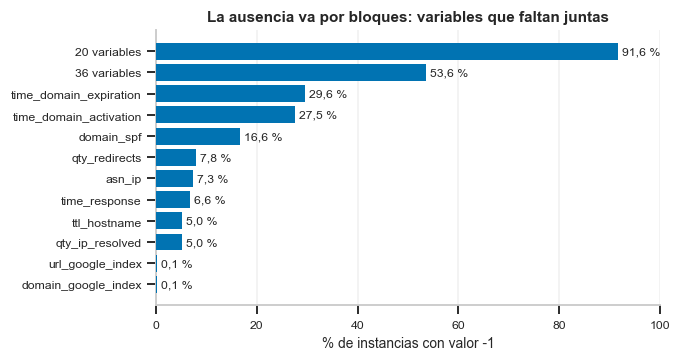

In [10]:
if GENERAR_FIGURAS:
    # Una barra por variable no decia nada: las veinte primeras valen
    # EXACTAMENTE lo mismo (91,6 %), porque las variables de params faltan
    # todas a la vez. La ausencia va por bloques, asi que se dibuja un
    # bloque por nivel, con cuantas variables comparte cada uno.
    niveles = (informe_centinela.rename_axis('variable').reset_index()
               .groupby('pct')['variable']
               .agg(n='size', cual='first').reset_index()
               .sort_values('pct'))
    etiquetas = [c if n == 1 else f'{n} variables'
                 for n, c in zip(niveles['n'], niveles['cual'])]
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.55))
    ax.barh(range(len(niveles)), niveles['pct'], color=C_A, zorder=3)
    ax.set_yticks(range(len(niveles)), etiquetas)
    for y, v in enumerate(niveles['pct']):
        ax.text(v + 0.8, y, f'{v:.1f}'.replace('.', ',') + ' %',
                va='center', fontsize=8)
    ax.set_xlabel('% de instancias con valor -1')
    ax.set_title('La ausencia va por bloques: variables que faltan juntas')
    ax.set_xlim(0, 100)
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b1_centinela_bloques', exportar='eda_sentinel')
    plt.show()

## 1.4. Duplicados y conflictos de etiqueta

Los duplicados exactos sobreponderan patrones repetidos y, si se reparten
entre entrenamiento y prueba, provocan **fuga de información**. Peor aún son
los duplicados en las variables predictoras con **etiqueta contradictoria**:
la misma URL representada aparece como phishing y como legítima, lo que es
ruido de etiqueta puro. Se cuantifican aquí y se tratan en el bloque 2.

In [11]:
def _resumen_duplicados():
    n_exactos = int(crudo.duplicated().sum())
    n_variables = int(crudo.duplicated(subset=VARIABLES).sum())
    distintas = crudo.groupby(VARIABLES, dropna=False)[DIANA].nunique()
    n_grupos = int((distintas > 1).sum())
    conflicto = crudo.groupby(VARIABLES, dropna=False)[DIANA].transform('nunique') > 1
    return {'duplicados_exactos': n_exactos,
            'duplicados_en_variables': n_variables,
            'grupos_con_etiqueta_contradictoria': n_grupos,
            'filas_en_conflicto': int(conflicto.sum())}

resumen_duplicados = punto('eda_duplicados', _resumen_duplicados)
for k, v in resumen_duplicados.items():
    print(f'  {k:38s} {v:,}')

  [checkpoint] «eda_duplicados» cargado de eda_duplicados.json
  duplicados_exactos                     1,438
  duplicados_en_variables                1,444
  grupos_con_etiqueta_contradictoria     6
  filas_en_conflicto                     13


## 1.5. Tipología, constancia y agrupación de las variables

Aunque todo es numérico, conviene separar **binarias** (indicadores 0/1) de
**continuas o de recuento**: determinan qué escalado y qué tratamiento de
atípicos son apropiados. Las variables **constantes** no aportan nada y las
**cuasi-constantes** (un valor domina el 99 % de los casos) casi nada.

Los 111 atributos se agrupan además por el componente de la URL que
describen (`_url`, `_domain`, `_directory`, `_file`, `_params`) más un
bloque de atributos externos. Esa agrupación estructura la interpretación
del bloque 9.

In [12]:
n_unicos = crudo[VARIABLES].nunique()

def tipo_variable(col):
    valores = set(pd.unique(crudo[col].dropna()))
    if valores <= {0, 1}:
        return 'binaria'
    return 'discreta_baja_card' if n_unicos[col] <= 10 else 'continua_o_recuento'

tipos = pd.Series({c: tipo_variable(c) for c in VARIABLES}, name='tipo')
BINARIAS = tipos[tipos == 'binaria'].index.tolist()

dominancia = crudo[VARIABLES].apply(
    lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
constantes = dominancia[dominancia == 1.0].index.tolist()
cuasi_constantes = dominancia[(dominancia >= 0.99) & (dominancia < 1.0)].index.tolist()

def grupo_variable(col):
    for sufijo in ['_url', '_domain', '_directory', '_file', '_params']:
        if col.endswith(sufijo):
            return sufijo.lstrip('_')
    return 'externo_dns_whois_reputacion'

grupos = pd.Series({c: grupo_variable(c) for c in VARIABLES}, name='grupo')
resumen_grupos = grupos.value_counts().rename_axis('grupo').reset_index(name='n_variables')

tabla(tipos.value_counts().rename_axis('tipo').reset_index(name='n'), 'eda_tipos_variables')
print(f'\nVariables constantes      : {len(constantes)} → {constantes}')
print(f'Variables cuasi-constantes: {len(cuasi_constantes)}')
print()
tabla(resumen_grupos, 'eda_grupos_variables')

               tipo  n
continua_o_recuento 46
 discreta_baja_card 46
            binaria 19



Variables constantes      : 13 → ['qty_slash_domain', 'qty_questionmark_domain', 'qty_equal_domain', 'qty_and_domain', 'qty_exclamation_domain', 'qty_space_domain', 'qty_tilde_domain', 'qty_comma_domain', 'qty_plus_domain', 'qty_asterisk_domain', 'qty_hashtag_domain', 'qty_dollar_domain', 'qty_percent_domain']
Variables cuasi-constantes: 16

                       grupo  n_variables
                         url           20
                      domain           19
externo_dns_whois_reputacion           19
                      params           19
                   directory           17
                        file           17


,grupo,n_variables
0,url,20
1,domain,19
2,externo_dns_whois_reputacion,19
3,params,19
4,directory,17
5,file,17


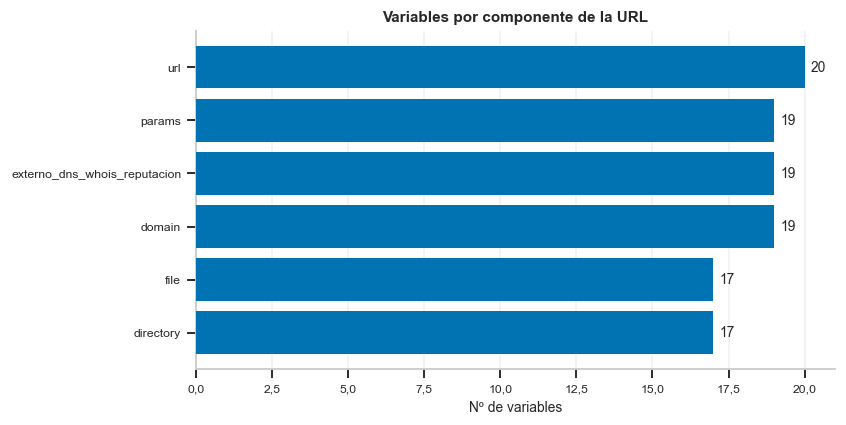

In [13]:
if GENERAR_FIGURAS:
    g = resumen_grupos.sort_values('n_variables')
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.barh(g['grupo'], g['n_variables'], color=C_A, zorder=3)
    for y, v in enumerate(g['n_variables']):
        ax.text(v + 0.2, y, str(int(v)), va='center', fontsize=9)
    ax.set_xlabel('Nº de variables')
    ax.set_title('Variables por componente de la URL')
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b1_grupos_variables')
    plt.show()

## 1.6. Redundancia entre variables

Variables muy correlacionadas entre sí introducen **multicolinealidad**:
apenas perjudica la capacidad predictiva de un ensamblado de árboles, pero
distorsiona los coeficientes de los modelos lineales y, sobre todo, la
interpretación de la importancia de variables del bloque 9. Se identifican
los pares con |Pearson| > 0,90 como candidatos a poda en el bloque 3.

In [14]:
def _correlaciones():
    corr = crudo[VARIABLES].corr(numeric_only=True)
    corr = corr.rename_axis(index='variable_a', columns='variable_b')
    superior = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    pares = superior.stack().rename('pearson').reset_index()
    altos = pares[pares['pearson'].abs() > 0.90].copy()
    altos = altos.reindex(altos['pearson'].abs().sort_values(ascending=False).index)
    con_diana = crudo[VARIABLES].corrwith(crudo[DIANA]).rename('corr_con_diana')
    return {'matriz': corr, 'pares_altos': altos.reset_index(drop=True),
            'con_diana': con_diana.to_frame().reset_index(names='variable')}

correlaciones = punto('eda_correlaciones', _correlaciones)
matriz_corr = correlaciones['matriz']
pares_altos = correlaciones['pares_altos']
corr_diana = correlaciones['con_diana'].copy()
corr_diana['abs'] = corr_diana['corr_con_diana'].abs()
corr_diana = corr_diana.sort_values('abs', ascending=False).reset_index(drop=True)

tabla(pares_altos, 'eda_pares_alta_correlacion', mostrar=False)
tabla(corr_diana, 'eda_correlacion_con_diana', mostrar=False)
print(f'Pares de variables con |Pearson| > 0,90: {len(pares_altos):,}')
print('\nLas 12 variables más correlacionadas con la clase:')
print(corr_diana.head(12).round(4).to_string(index=False))

  [checkpoint] «eda_correlaciones» cargado de eda_correlaciones.joblib
Pares de variables con |Pearson| > 0,90: 337

Las 12 variables más correlacionadas con la clase:
                  variable  corr_con_diana    abs
       qty_slash_directory          0.7465 0.7465
     qty_questionmark_file          0.7456 0.7456
     qty_hashtag_directory          0.7456 0.7456
            qty_slash_file          0.7456 0.7456
qty_questionmark_directory          0.7456 0.7456
          qty_hashtag_file          0.7456 0.7456
           qty_dollar_file          0.7456 0.7456
               qty_at_file          0.7455 0.7455
      qty_exclamation_file          0.7451 0.7451
              qty_and_file          0.7449 0.7449
            qty_tilde_file          0.7447 0.7447
            qty_equal_file          0.7437 0.7437


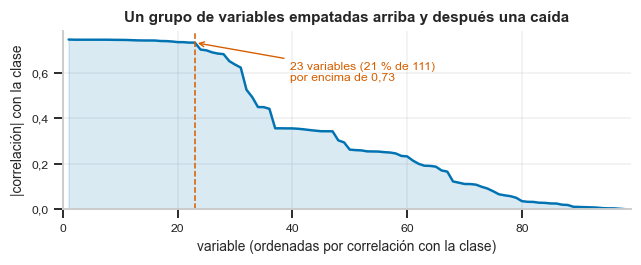

In [15]:
if GENERAR_FIGURAS:
    # Un grafico de barras de las veinte primeras salia plano, porque todas
    # caen entre 0,735 y 0,747: veinte barras para un solo numero. Lo que
    # de verdad hay es una meseta que se acaba de golpe, y eso se ve en la
    # curva por puesto, que ademas no necesita etiquetar 111 nombres.
    #
    # Al lado iba la matriz de Pearson entre variables. Sin etiquetas era
    # una mancha azul, y lo que aporta ya esta dicho con numeros en el
    # texto (337 pares con |r|>0,90), asi que queda solo la curva.
    perfil = corr_diana['corr_con_diana'].abs().sort_values(
        ascending=False).dropna().reset_index(drop=True)
    # El escalon esta entre el puesto 23 y el 24 (0,7328 -> 0,7023): ahi se
    # acaba la meseta. El porcentaje se cuenta sobre las 111 predictoras,
    # que es la cifra que da la memoria, y no sobre las que tienen
    # correlacion calculable (13 son constantes y no la tienen).
    UMBRAL = 0.73
    n_alta = int((perfil >= UMBRAL).sum())
    pct = n_alta / len(VARIABLES) * 100

    fig, ax = plt.subplots(figsize=ancho(1.0, 0.42))
    ax.plot(range(1, len(perfil) + 1), perfil, color=C_POS, lw=1.6)
    ax.fill_between(range(1, len(perfil) + 1), perfil, alpha=0.15,
                    color=C_POS)
    corte = n_alta
    ax.axvline(corte, color=C_NEG, ls='--', lw=1)
    # El texto va a la zona vacia de arriba a la derecha, con una flecha al
    # punto: pegado a la linea se montaba sobre el titulo y sobre la curva.
    umbral_txt = f'{UMBRAL:.2f}'.replace('.', ',')
    ax.annotate(f'{n_alta} variables ({pct:.0f} % de {len(VARIABLES)})\n'
                f'por encima de {umbral_txt}',
                xy=(corte, perfil.iloc[corte - 1]),
                xytext=(0.40, 0.72), textcoords='axes fraction',
                fontsize=8, color=C_NEG,
                arrowprops=dict(arrowstyle='->', color=C_NEG, lw=0.9))
    ax.set_xlabel('variable (ordenadas por correlación con la clase)')
    ax.set_ylabel('|correlación| con la clase')
    ax.set_title('Un grupo de variables empatadas arriba y después una caída')
    ax.set_ylim(0, None)
    ax.set_xlim(0, len(perfil) + 1)
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    figura(fig, 'b1_correlaciones', exportar='eda_corr_target')
    plt.show()

## 1.7. Asociaciones no lineales y estructura de la ausencia

Pearson solo capta relaciones lineales. Se complementa con la correlación de
**Spearman** (relaciones monótonas) y la **información mutua** (dependencia
estadística general, también no lineal).

Y una comprobación que resulta clave: ¿los valores ausentes **co-ocurren**?
Si las consultas externas del mismo servicio fallan juntas, la ausencia no
es aleatoria y **codificarla** vale más que imputarla sin más. Esa es la
justificación del imputador con indicador que se elige en el bloque 2.

In [16]:
from sklearn.feature_selection import mutual_info_classif

def _asociaciones():
    limpio = crudo[VARIABLES].replace(-1, np.nan)
    # Para Spearman/MI se rellena con la mediana (solo para este análisis
    # descriptivo; la imputación real, sin fugas, es la del bloque 2).
    relleno = limpio.fillna(limpio.median())
    spearman = relleno.corrwith(crudo[DIANA], method='spearman').rename('spearman')
    muestra = relleno.sample(n=min(12000, len(relleno)), random_state=SEMILLA)
    mi = mutual_info_classif(muestra, crudo[DIANA].loc[muestra.index],
                             random_state=SEMILLA)
    info_mutua = pd.Series(mi, index=VARIABLES, name='informacion_mutua')
    # Co-ocurrencia de la ausencia.
    ausencia = limpio.isna()
    con_nan = ausencia.columns[ausencia.any()].tolist()
    corr_ausencia = ausencia[con_nan].astype(int).corr()
    sup = corr_ausencia.where(np.triu(np.ones(corr_ausencia.shape, dtype=bool), k=1))
    return {'spearman': spearman.to_frame().reset_index(names='variable'),
            'info_mutua': info_mutua.to_frame().reset_index(names='variable'),
            'corr_ausencia': corr_ausencia,
            'n_columnas_con_nan': len(con_nan),
            'pares_ausencia_conjunta': int((sup.abs() > 0.95).sum().sum())}

asociaciones = punto('eda_asociaciones', _asociaciones)
spearman = asociaciones['spearman'].copy()
spearman['abs'] = spearman['spearman'].abs()
spearman = spearman.sort_values('abs', ascending=False).reset_index(drop=True)
info_mutua = asociaciones['info_mutua'].sort_values(
    'informacion_mutua', ascending=False).reset_index(drop=True)

tabla(spearman, 'eda_spearman', mostrar=False)
tabla(info_mutua, 'eda_informacion_mutua', mostrar=False)
print(f"Columnas con valores ausentes            : {asociaciones['n_columnas_con_nan']}")
print(f"Pares cuya ausencia co-ocurre (|r|>0,95) : {asociaciones['pares_ausencia_conjunta']}")
print('\nLa ausencia NO es aleatoria: las consultas externas fallan en bloque.')
print('\nTop-10 por información mutua con la clase:')
print(info_mutua.head(10).round(4).to_string(index=False))

  [checkpoint] «eda_asociaciones» cargado de eda_asociaciones.joblib
Columnas con valores ausentes            : 66
Pares cuya ausencia co-ocurre (|r|>0,95) : 822

La ausencia NO es aleatoria: las consultas externas fallan en bloque.

Top-10 por información mutua con la clase:
              variable  informacion_mutua
         qty_slash_url             0.3769
      directory_length             0.3613
           file_length             0.3408
            length_url             0.2807
   qty_slash_directory             0.2442
time_domain_activation             0.1912
                asn_ip             0.1398
     qty_dot_directory             0.1378
          qty_dot_file             0.1253
          ttl_hostname             0.0944


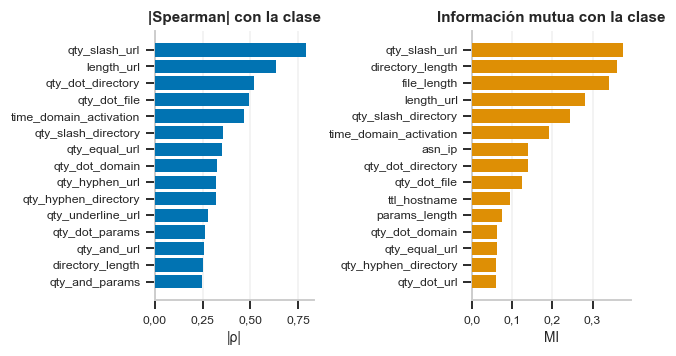

In [17]:
if GENERAR_FIGURAS:
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.56))
    s = spearman.head(15).iloc[::-1]
    axes[0].barh(s['variable'], s['abs'], color=C_A, zorder=3)
    axes[0].set_title('|Spearman| con la clase'); axes[0].set_xlabel('|ρ|')
    m = info_mutua.head(15).iloc[::-1]
    axes[1].barh(m['variable'], m['informacion_mutua'], color=C_B, zorder=3)
    axes[1].set_title('Información mutua con la clase'); axes[1].set_xlabel('MI')
    for ax in axes:
        ax.grid(axis='y', visible=False)
        ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    figura(fig, 'b1_spearman_info_mutua', exportar='eda_spearman_mi')
    plt.show()

## 1.8. Punto de control 1 — lo que deja el análisis exploratorio

| Hallazgo | Consecuencia para el resto del trabajo |
|----------|----------------------------------------|
| IR ≈ 1,89 (desbalanceo moderado) | Métricas F1, PR-AUC y MCC; el balanceo se estudia pero no se da por necesario |
| `-1` es centinela en 66 de 111 variables | Reinterpretarlo como `NaN` **antes** de cualquier otra cosa |
| La ausencia co-ocurre en bloques | Imputar **añadiendo indicador de ausencia**: que falte es informativo |
| 4 753 pares con \|Pearson\| > 0,90 | Poda por correlación en la selección de variables |
| Duplicados exactos y conflictos de etiqueta | Limpiarlos **antes** de particionar, para no filtrar información |
| Fuerte asimetría en recuentos y longitudes | Comparar escaladores robustos, no dar por buena la estandarización |

In [18]:
def _resumen_eda():
    return {
        'n_instancias': int(len(crudo)),
        'n_variables': int(len(VARIABLES)),
        'imbalance_ratio': round(IR, 4),
        'variables_con_centinela': int(len(informe_centinela)),
        'celdas_centinela': int(centinela.sum()),
        'variables_binarias': int(len(BINARIAS)),
        'variables_constantes': int(len(constantes)),
        'variables_cuasi_constantes': int(len(cuasi_constantes)),
        'pares_correlacion_alta': int(len(pares_altos)),
        'pares_ausencia_conjunta': int(asociaciones['pares_ausencia_conjunta']),
        **resumen_duplicados,
    }

RESUMEN_EDA = punto('eda', _resumen_eda)
print(json.dumps(RESUMEN_EDA, indent=2, ensure_ascii=False))

  [checkpoint] «eda» cargado de eda.json
{
  "n_instancias": 88647,
  "n_variables": 111,
  "imbalance_ratio": 1.8925,
  "variables_con_centinela": 66,
  "celdas_centinela": 3428432,
  "variables_binarias": 19,
  "variables_constantes": 13,
  "variables_cuasi_constantes": 16,
  "pares_correlacion_alta": 337,
  "pares_ausencia_conjunta": 822,
  "duplicados_exactos": 1438,
  "duplicados_en_variables": 1444,
  "grupos_con_etiqueta_contradictoria": 6,
  "filas_en_conflicto": 13
}


---

# Bloque 2 — Preprocesamiento

El orden de las operaciones no es arbitrario, es el que evita las fugas de
información:

1. **Duplicados y conflictos de etiqueta** — antes de particionar, porque
   copias idénticas repartidas entre entrenamiento y prueba inflarían el
   resultado.
2. **Centinela `-1` → `NaN`** — operación determinista, no aprende nada de
   los datos.
3. **Partición estratificada 80/20** — una sola vez, y a partir de aquí el
   test queda **reservado**.
4. **Imputación** y **escalado** — se ajustan **solo con entrenamiento**,
   porque sí aprenden de los datos (Kaufman et al., 2012).

Cada versión de datos queda registrada con su linaje: de dónde viene, qué se
le hizo y por qué.

In [19]:
def punto_particion(nombre, calcular):
    '''Punto de control para un par (entrenamiento, prueba).

    Guarda cada partición en su propio Parquet, que comprime mucho mejor
    que un volcado binario y se puede inspeccionar por separado.
    '''
    r_tr, r_te = CKPT / f'{nombre}_train.parquet', CKPT / f'{nombre}_test.parquet'
    recalcular = ('*' in FORZAR) or (nombre in FORZAR)
    if r_tr.exists() and r_te.exists() and not recalcular:
        print(f'  [checkpoint] «{nombre}» cargado (train + test)')
        return pd.read_parquet(r_tr), pd.read_parquet(r_te)
    print(f'  [calculando  ] «{nombre}» ...')
    t0 = time.perf_counter()
    tr, te = calcular()
    tr.to_parquet(r_tr, index=False)
    te.to_parquet(r_te, index=False)
    print(f'  [guardado    ] «{nombre}» ({tr.shape[0]:,}+{te.shape[0]:,} filas, '
          f'{time.perf_counter() - t0:.1f}s)')
    return tr, te

LINAJE = []

def registrar_version(nombre, df, origen, descripcion, motivo):
    '''Deja constancia del linaje de una versión de datos.'''
    LINAJE.append({
        'version': nombre, 'origen': origen,
        'filas': int(df.shape[0]), 'columnas': int(df.shape[1]),
        'descripcion': descripcion, 'motivo': motivo,
        'fecha_utc': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    })
    print(f'  -> {nombre}: {df.shape[0]:,} × {df.shape[1]} ({descripcion})')

print('Utilidades de versionado de datos listas.')

Utilidades de versionado de datos listas.


## 2.1. Duplicados y conflictos de etiqueta

Dos operaciones, en este orden: primero se eliminan **todas** las filas de
los grupos con etiqueta contradictoria (son ruido puro y no hay forma
honesta de decidir su clase; el voto mayoritario asignaría una etiqueta
arbitraria en los empates) y después los duplicados exactos, conservando la
primera aparición.

In [20]:
def _deduplicar():
    distintas = crudo.groupby(VARIABLES, dropna=False)[DIANA].transform('nunique')
    conflicto = distintas > 1
    paso1 = crudo.loc[~conflicto].copy()
    limpio = paso1.drop_duplicates(keep='first').reset_index(drop=True)
    return limpio

v01 = punto('v01_sin_duplicados', _deduplicar)

print(f'Filas iniciales           : {len(crudo):,}')
print(f'Eliminadas por conflicto  : -{resumen_duplicados["filas_en_conflicto"]:,}')
print(f'Eliminadas por duplicado  : '
      f'-{len(crudo) - resumen_duplicados["filas_en_conflicto"] - len(v01):,}')
print(f'Filas resultantes         : {len(v01):,}')
assert int(v01.duplicated().sum()) == 0, 'Quedan duplicados exactos'
assert int((v01.groupby(VARIABLES, dropna=False)[DIANA]
            .transform('nunique') > 1).sum()) == 0, 'Quedan conflictos'

antes = crudo[DIANA].value_counts(normalize=True).sort_index()
despues = v01[DIANA].value_counts(normalize=True).sort_index()
tabla(pd.DataFrame({'clase': ['legítimo (0)', 'phishing (1)'],
                    'prop_antes': antes.values.round(4),
                    'prop_despues': despues.values.round(4)}),
      'prep_distribucion_tras_limpieza')
print('\nEl balance de clases se mantiene: la limpieza no introduce sesgo.')
registrar_version('v01_sin_duplicados', v01, 'dataset_full (crudo)',
                  'Sin conflictos de etiqueta ni duplicados exactos',
                  'Evitar sesgo por redundancia, ruido de etiqueta y fuga al particionar')

  [checkpoint] «v01_sin_duplicados» cargado de v01_sin_duplicados.parquet
Filas iniciales           : 88,647
Eliminadas por conflicto  : -13
Eliminadas por duplicado  : -1,437
Filas resultantes         : 87,197


       clase  prop_antes  prop_despues
legítimo (0)      0.6543        0.6503
phishing (1)      0.3457        0.3497

El balance de clases se mantiene: la limpieza no introduce sesgo.
  -> v01_sin_duplicados: 87,197 × 112 (Sin conflictos de etiqueta ni duplicados exactos)


## 2.2. El centinela `-1` pasa a ser `NaN`

Operación determinista sobre las variables predictoras. Se verifica que el
número de `NaN` resultante coincide exactamente con el recuento previo de
`-1`: si no cuadrara, la conversión habría tocado algo que no debía.

In [21]:
def _reinterpretar_centinela():
    d = v01.copy()
    d[VARIABLES] = d[VARIABLES].replace(-1, np.nan)
    return d

v02 = punto('v02_centinela_nan', _reinterpretar_centinela)

n_antes = int((v01[VARIABLES] == -1).sum().sum())
n_despues = int(v02[VARIABLES].isna().sum().sum())
assert n_antes == n_despues, 'Discrepancia en la conversión -1 → NaN'
ausencia_pct = (v02[VARIABLES].isna().mean() * 100).round(3)
ausencia_pct = ausencia_pct[ausencia_pct > 0].sort_values(ascending=False)

print(f'Celdas == -1 antes  : {n_antes:,}')
print(f'Celdas NaN después  : {n_despues:,}  (coinciden)')
print(f'Columnas con NaN    : {len(ausencia_pct)}')
tabla(ausencia_pct.rename('pct_ausente').rename_axis('variable').reset_index(),
      'prep_ausencia_por_variable', mostrar=False)
registrar_version('v02_centinela_nan', v02, 'v01_sin_duplicados',
                  'Centinela -1 reinterpretado como NaN',
                  'El -1 no es un valor numérico legítimo sino ausencia de dato')

  [checkpoint] «v02_centinela_nan» cargado de v02_centinela_nan.parquet
Celdas == -1 antes  : 3,348,251
Celdas NaN después  : 3,348,251  (coinciden)
Columnas con NaN    : 66
  -> v02_centinela_nan: 87,197 × 112 (Centinela -1 reinterpretado como NaN)


## 2.3. Partición canónica entrenamiento / prueba

Una sola partición, estratificada por la clase, con `test_size = 0,20` y la
semilla global. **A partir de aquí el conjunto de prueba queda reservado**:
no se toca hasta el bloque 8, y ninguna decisión de modelado se toma
mirándolo.

In [22]:
from sklearn.model_selection import train_test_split

def _particionar():
    X, y = v02[VARIABLES], v02[DIANA]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y)
    tr = pd.concat([X_tr, y_tr], axis=1).reset_index(drop=True)
    te = pd.concat([X_te, y_te], axis=1).reset_index(drop=True)
    if MODO == 'rapido':
        # Solo para la prueba de humo: reduce el volumen sin tocar el código
        # posterior, de modo que todo el proceso se ejecute en minutos.
        tr, _ = train_test_split(tr, train_size=min(6000, len(tr) - 1),
                                 random_state=SEMILLA, stratify=tr[DIANA])
        te, _ = train_test_split(te, train_size=min(1500, len(te) - 1),
                                 random_state=SEMILLA, stratify=te[DIANA])
        tr, te = tr.reset_index(drop=True), te.reset_index(drop=True)
    return tr, te

train_nan, test_nan = punto_particion('v03_particion', _particionar)

proporciones = pd.DataFrame({
    'clase': ['legítimo (0)', 'phishing (1)'],
    'prop_train': train_nan[DIANA].value_counts(normalize=True).sort_index().values.round(4),
    'prop_test': test_nan[DIANA].value_counts(normalize=True).sort_index().values.round(4),
    'n_train': train_nan[DIANA].value_counts().sort_index().values,
    'n_test': test_nan[DIANA].value_counts().sort_index().values,
})
print(f'Entrenamiento: {len(train_nan):,}  |  Prueba (reservada): {len(test_nan):,}\n')
tabla(proporciones, 'prep_proporciones_particion')
registrar_version('v03_particion_train', train_nan, 'v02_centinela_nan',
                  'Entrenamiento canónico (con NaN)', 'Partición estratificada única')
registrar_version('v03_particion_test', test_nan, 'v02_centinela_nan',
                  'Prueba canónica reservada (con NaN)', 'Hold-out para la evaluación final')

  [checkpoint] «v03_particion» cargado (train + test)
Entrenamiento: 69,757  |  Prueba (reservada): 17,440

       clase  prop_train  prop_test  n_train  n_test
legítimo (0)      0.6503     0.6503    45364   11342
phishing (1)      0.3497     0.3497    24393    6098
  -> v03_particion_train: 69,757 × 112 (Entrenamiento canónico (con NaN))
  -> v03_particion_test: 17,440 × 112 (Prueba canónica reservada (con NaN))


## 2.4. Imputación de valores ausentes

La mayoría de modelos no admiten `NaN`. No existe una estrategia
universalmente óptima, así que se **comparan experimentalmente** ocho, con
un modelo fijo (regresión logística estandarizada, encapsulada en un
`Pipeline` para que el imputador se ajuste dentro de cada pliegue) y el
protocolo común.

| Estrategia | Idea | Limitación |
|-----------|------|------------|
| Media | Sustituye por la media | Sensible a asimetría y atípicos |
| Mediana | Sustituye por la mediana | Robusta, pero ignora relaciones entre variables |
| Moda | Valor más frecuente | Poco informativa en continuas |
| Constante `-1` | Mantiene el centinela explícito | Introduce un valor artificial |
| **Mediana + indicador** | Mediana más una columna binaria de ausencia | Duplica las columnas afectadas |
| Media + indicador | Ídem con media | Ídem |
| kNN | Media de los *k* vecinos | Coste O(n²), sensible a la escala |
| MICE | Modela cada variable con las demás | Costoso |

El EDA mostró que la ausencia co-ocurre y no es aleatoria, así que la
variante **con indicador** parte con ventaja teórica: conserva la
información de *que faltaba*. Los imputadores costosos (kNN, MICE) se
ordenan sobre una submuestra estratificada; los baratos, sobre el
entrenamiento completo.

In [23]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer, KNNImputer, SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_train_nan, y_train = train_nan[VARIABLES], train_nan[DIANA]

def flujo_imputacion(imputador):
    return Pipeline([('imputador', imputador),
                     ('escalado', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000, random_state=SEMILLA))])

IMPUTADORES_BARATOS = {
    'media': SimpleImputer(strategy='mean'),
    'mediana': SimpleImputer(strategy='median'),
    'moda': SimpleImputer(strategy='most_frequent'),
    'constante_-1': SimpleImputer(strategy='constant', fill_value=-1),
    'mediana+indicador': SimpleImputer(strategy='median', add_indicator=True),
    'media+indicador': SimpleImputer(strategy='mean', add_indicator=True),
}
IMPUTADORES_COSTOSOS = {
    'knn_k5': KNNImputer(n_neighbors=5),
    'mice': IterativeImputer(max_iter=10, random_state=SEMILLA),
}

def _comparar_imputadores():
    filas = []
    for nombre, imp in IMPUTADORES_BARATOS.items():
        t0 = time.perf_counter()
        res = evaluar(flujo_imputacion(imp), X_train_nan, y_train)
        res.update({'imputador': nombre, 'protocolo': 'train_completo_cv5',
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        print(f"  {nombre:20s} F1={res['f1_mean']:.4f}  "
              f"MCC={res['mcc_mean']:.4f}  ({res['tiempo_s']}s)")
    # Los costosos, sobre submuestra estratificada (solo para ordenarlos).
    X_sub, y_sub = submuestrear(X_train_nan, y_train, N_SUB_IMPUT)
    for nombre, imp in {'mediana_ref': SimpleImputer(strategy='median'),
                        **IMPUTADORES_COSTOSOS}.items():
        t0 = time.perf_counter()
        res = evaluar(flujo_imputacion(imp), X_sub, y_sub, n_splits=3)
        res.update({'imputador': nombre,
                    'protocolo': f'submuestra{N_SUB_IMPUT}_cv3',
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        print(f"  {nombre:20s} F1={res['f1_mean']:.4f}  "
              f"MCC={res['mcc_mean']:.4f}  ({res['tiempo_s']}s)")
    return pd.DataFrame(filas)

comparacion_imputacion = punto('imputacion_comparacion', _comparar_imputadores)
for _, r in comparacion_imputacion.iterrows():
    registrar('2_preprocesamiento', 'imputacion', 'LogisticRegression',
              {'f1': r['f1_mean'], 'mcc': r['mcc_mean']},
              {'imputador': r['imputador']}, datos='train con NaN')

cols = ['imputador', 'protocolo', 'f1_mean', 'f1_std',
        'average_precision_mean', 'roc_auc_mean', 'mcc_mean', 'tiempo_s']
tabla(comparacion_imputacion[cols].sort_values('f1_mean', ascending=False)
      .round(4).reset_index(drop=True), 'prep_comparacion_imputacion')

  [checkpoint] «imputacion_comparacion» cargado de imputacion_comparacion.parquet
        imputador          protocolo  f1_mean  f1_std  average_precision_mean  roc_auc_mean  mcc_mean  tiempo_s
mediana+indicador train_completo_cv5   0.9057  0.0026                  0.9651        0.9809    0.8545       2.6
  media+indicador train_completo_cv5   0.9057  0.0026                  0.9651        0.9809    0.8544       2.3
     constante_-1 train_completo_cv5   0.9047  0.0025                  0.9617        0.9792    0.8528       1.8
           knn_k5 submuestra6000_cv3   0.8949  0.0031                  0.9566        0.9767    0.8382       8.7
      mediana_ref submuestra6000_cv3   0.8883  0.0030                  0.9555        0.9741    0.8284       0.2
             mice submuestra6000_cv3   0.8848  0.0114                  0.9506        0.9703    0.8234      15.7
            media train_completo_cv5   0.8845  0.0018                  0.9578        0.9757    0.8221       2.6
          mediana trai

,imputador,protocolo,f1_mean,f1_std,average_precision_mean,roc_auc_mean,mcc_mean,tiempo_s
0,mediana+indicador,train_completo_cv5,0.9057,0.0026,0.9651,0.9809,0.8545,2.6
1,media+indicador,train_completo_cv5,0.9057,0.0026,0.9651,0.9809,0.8544,2.3
2,constante_-1,train_completo_cv5,0.9047,0.0025,0.9617,0.9792,0.8528,1.8
3,knn_k5,submuestra6000_cv3,0.8949,0.0031,0.9566,0.9767,0.8382,8.7
4,mediana_ref,submuestra6000_cv3,0.8883,0.0030,0.9555,0.9741,0.8284,0.2
5,mice,submuestra6000_cv3,0.8848,0.0114,0.9506,0.9703,0.8234,15.7
6,media,train_completo_cv5,0.8845,0.0018,0.9578,0.9757,0.8221,2.6
7,mediana,train_completo_cv5,0.8838,0.0019,0.9569,0.9751,0.8208,2.6
8,moda,train_completo_cv5,0.8818,0.0021,0.9530,0.9724,0.8176,2.0


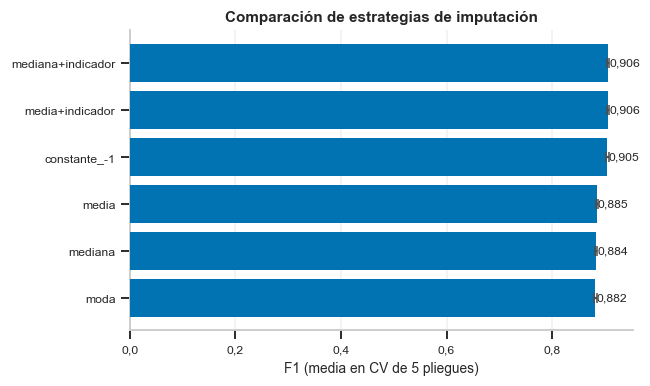

In [24]:
if GENERAR_FIGURAS:
    d = comparacion_imputacion[
        comparacion_imputacion['protocolo'] == 'train_completo_cv5'
    ].sort_values('f1_mean')
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.60))
    ax.barh(d['imputador'], d['f1_mean'], xerr=d['f1_std'], color=C_A,
            zorder=3, error_kw={'ecolor': '0.3', 'capsize': 3})
    for y, v in enumerate(d['f1_mean']):
        ax.text(v + 0.002, y, f'{v:.3f}'.replace('.', ','),
                va='center', fontsize=8)
    ax.set_xlabel('F1 (media en CV de 5 pliegues)')
    ax.set_title('Comparación de estrategias de imputación')
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b2_imputacion', exportar='prep_imputation')
    plt.show()

### Aplicación del imputador elegido

Se selecciona la mejor estrategia **entre las evaluadas sobre el
entrenamiento completo** (comparación justa y escalable a las 87 000
instancias). El imputador se ajusta **solo con entrenamiento** y se aplica a
ambas particiones.

In [25]:
def _imputar():
    baratos = comparacion_imputacion[
        comparacion_imputacion['protocolo'] == 'train_completo_cv5']
    elegido = elegir(baratos, 'imputador', preferencia=ORDEN_IMPUTADORES)
    imputador = IMPUTADORES_BARATOS[elegido]
    imputador.fit(X_train_nan)
    columnas = list(imputador.get_feature_names_out(VARIABLES))
    tr = pd.DataFrame(imputador.transform(X_train_nan), columns=columnas)
    te = pd.DataFrame(imputador.transform(test_nan[VARIABLES]), columns=columnas)
    tr[DIANA] = train_nan[DIANA].values
    te[DIANA] = test_nan[DIANA].values
    return tr, te

train_imp, test_imp = punto_particion('v04_imputado', _imputar)

IMPUTADOR_ELEGIDO, MOTIVO_IMPUTADOR = elegir(
    comparacion_imputacion[
        comparacion_imputacion['protocolo'] == 'train_completo_cv5'],
    'imputador', preferencia=ORDEN_IMPUTADORES, explicar=True)
VARIABLES_IMP = [c for c in train_imp.columns if c != DIANA]
INDICADORES = [c for c in VARIABLES_IMP if c.startswith('missingindicator_')]

print(f'Estrategia seleccionada : {IMPUTADOR_ELEGIDO!r}')
print(f'  por                   : {MOTIVO_IMPUTADOR}')
print(f'Columnas tras imputar   : {len(VARIABLES_IMP)} '
      f'({len(INDICADORES)} indicadores de ausencia añadidos)')
assert int(train_imp[VARIABLES_IMP].isna().sum().sum()) == 0
assert int(test_imp[VARIABLES_IMP].isna().sum().sum()) == 0
print('Verificacion: sin valores ausentes en ninguna particion.')
registrar_version('v04_imputado_train', train_imp, 'v03_particion_train',
                  f'Imputación «{IMPUTADOR_ELEGIDO}» ajustada solo en train',
                  'Eliminar ausentes conservando la información de que faltaban')

  [checkpoint] «v04_imputado» cargado (train + test)
Estrategia seleccionada : 'mediana+indicador'
  por                   : f1_mean = 0.9057; empate a esa precision entre ['mediana+indicador', 'media+indicador'], decide el orden declarado
Columnas tras imputar   : 177 (66 indicadores de ausencia añadidos)
Verificacion: sin valores ausentes en ninguna particion.
  -> v04_imputado_train: 69,757 × 178 (Imputación «mediana+indicador» ajustada solo en train)


## 2.5. Valores atípicos

La regla del rango intercuartílico marca como atípica una fracción enorme de
las observaciones, y no es de extrañar: los recuentos y longitudes de URL
son distribuciones muy asimétricas, donde los valores extremos **son
precisamente la señal** (una URL larguísima con muchos guiones es sospechosa,
no un error de medida).

Eliminar esas filas destruiría información discriminante y sesgaría el
conjunto. Se documenta la magnitud del fenómeno y se decide **no eliminar
nada**, dejando que el escalado robusto y los árboles —invariantes a
transformaciones monótonas— gestionen los extremos.

In [26]:
def _atipicos():
    continuas = [c for c in VARIABLES_IMP
                 if set(pd.unique(train_imp[c].dropna())) > {0, 1}]
    q1 = train_imp[continuas].quantile(0.25)
    q3 = train_imp[continuas].quantile(0.75)
    iqr = q3 - q1
    fuera = ((train_imp[continuas] < (q1 - 1.5 * iqr)) |
             (train_imp[continuas] > (q3 + 1.5 * iqr)))
    por_variable = (fuera.mean() * 100).round(2).sort_values(ascending=False)
    return {'pct_filas_con_algun_atipico': round(float(fuera.any(axis=1).mean() * 100), 2),
            'pct_celdas_atipicas': round(float(fuera.values.mean() * 100), 2),
            'top_variables': por_variable.head(10).to_dict()}

atipicos = punto('atipicos', _atipicos)
print(f"Filas con algún valor atípico (IQR): {atipicos['pct_filas_con_algun_atipico']}%")
print(f"Celdas atípicas                    : {atipicos['pct_celdas_atipicas']}%")
print('\nDECISIÓN: no se elimina ninguna fila. En este dominio los valores')
print('extremos son señal, no error de medida.')

  [checkpoint] «atipicos» cargado de atipicos.json
Filas con algún valor atípico (IQR): 69.53%
Celdas atípicas                    : 3.2%

DECISIÓN: no se elimina ninguna fila. En este dominio los valores
extremos son señal, no error de medida.


## 2.6. Escalado

Las variables tienen escalas muy dispares: recuentos de un dígito conviven
con tiempos DNS de seis. Los modelos sensibles a la distancia (regresión
logística, SVM, kNN, redes) lo acusan; los árboles no. Se comparan cinco
técnicas más la referencia sin escalar, aplicando la transformación **solo a
las variables continuas** (las binarias e indicadoras se dejan intactas).

Qué cuenta como binaria se decide sobre los datos **ya imputados**, no sobre
el fichero original: una variable con valores `{-1, 0, 1}` no parece binaria
hasta que el centinela deja de ser un número, y escalarla sería un error.

Del bloque salen dos versiones de los datos, y las dos se usan después:
**escalada** para los modelos sensibles a la escala y **sin escalar** para
los basados en árboles.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (MaxAbsScaler, MinMaxScaler,
    PowerTransformer, RobustScaler)

def columnas_binarias(df):
    '''Columnas cuyos valores no nulos estan contenidos en {0, 1}.'''
    return [c for c in df.columns if set(pd.unique(df[c].dropna())) <= {0, 1}]

# Importante: la decision se toma sobre los datos YA IMPUTADOS. En el crudo,
# una columna con valores {-1, 0, 1} no parece binaria; al reinterpretar el
# centinela e imputar, queda en {0, 1} y no debe escalarse.
BINARIAS_IMP = columnas_binarias(train_imp[VARIABLES_IMP])
CONTINUAS = [c for c in VARIABLES_IMP if c not in BINARIAS_IMP]
X_train_imp, y_train_imp = train_imp[VARIABLES_IMP], train_imp[DIANA]

ESCALADORES = {
    'sin_escalar': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'MaxAbsScaler': MaxAbsScaler(),
    'PowerTransformer(YJ)': PowerTransformer(method='yeo-johnson'),
}

def flujo_escalado(escalador):
    previo = ('passthrough' if escalador is None else
              ColumnTransformer([('sc', escalador, CONTINUAS)],
                                remainder='passthrough'))
    return Pipeline([('pre', previo),
                     ('clf', LogisticRegression(max_iter=1000, random_state=SEMILLA))])

def _comparar_escalado():
    filas = []
    for nombre, esc in ESCALADORES.items():
        t0 = time.perf_counter()
        res = evaluar(flujo_escalado(esc), X_train_imp, y_train_imp)
        res.update({'escalador': nombre,
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        print(f"  {nombre:22s} F1={res['f1_mean']:.4f}  MCC={res['mcc_mean']:.4f}"
              f"  ({res['tiempo_s']}s)")
    return pd.DataFrame(filas)

comparacion_escalado = punto('escalado_comparacion', _comparar_escalado)
for _, r in comparacion_escalado.iterrows():
    registrar('2_preprocesamiento', 'escalado', 'LogisticRegression',
              {'f1': r['f1_mean'], 'mcc': r['mcc_mean']},
              {'escalador': r['escalador']}, datos='v04_imputado')

print(f'\nVariables continuas a escalar: {len(CONTINUAS)} de {len(VARIABLES_IMP)}\n')
tabla(comparacion_escalado[['escalador', 'f1_mean', 'f1_std',
                            'average_precision_mean', 'mcc_mean', 'tiempo_s']]
      .sort_values('f1_mean', ascending=False).round(4).reset_index(drop=True),
      'prep_comparacion_escalado')

  [checkpoint] «escalado_comparacion» cargado de escalado_comparacion.parquet

Variables continuas a escalar: 80 de 177

           escalador  f1_mean  f1_std  average_precision_mean  mcc_mean  tiempo_s
        RobustScaler   0.9058  0.0024                  0.9651    0.8546       9.5
      StandardScaler   0.9058  0.0026                  0.9650    0.8546       2.4
PowerTransformer(YJ)   0.9036  0.0026                  0.9638    0.8513       5.1
        MaxAbsScaler   0.8994  0.0022                  0.9608    0.8441       3.6
        MinMaxScaler   0.8993  0.0023                  0.9609    0.8440       3.6
         sin_escalar   0.8705  0.0029                  0.9445    0.7997      19.2


,escalador,f1_mean,f1_std,average_precision_mean,mcc_mean,tiempo_s
0,RobustScaler,0.9058,0.0024,0.9651,0.8546,9.5
1,StandardScaler,0.9058,0.0026,0.9650,0.8546,2.4
2,PowerTransformer(YJ),0.9036,0.0026,0.9638,0.8513,5.1
3,MaxAbsScaler,0.8994,0.0022,0.9608,0.8441,3.6
4,MinMaxScaler,0.8993,0.0023,0.9609,0.8440,3.6
5,sin_escalar,0.8705,0.0029,0.9445,0.7997,19.2


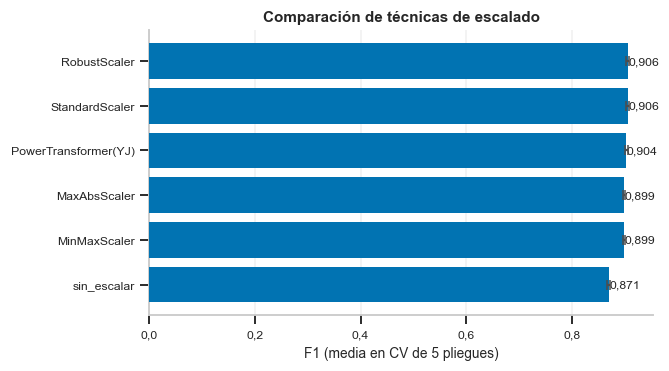

In [28]:
if GENERAR_FIGURAS:
    d = comparacion_escalado.sort_values('f1_mean')
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.57))
    ax.barh(d['escalador'], d['f1_mean'], xerr=d['f1_std'], color=C_A,
            zorder=3, error_kw={'ecolor': '0.3', 'capsize': 3})
    for y, v in enumerate(d['f1_mean']):
        ax.text(v + 0.001, y, f'{v:.3f}'.replace('.', ','),
                va='center', fontsize=8)
    ax.set_xlabel('F1 (media en CV de 5 pliegues)')
    ax.set_title('Comparación de técnicas de escalado')
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b2_escalado', exportar='prep_scaling')
    plt.show()

In [29]:
def _escalar():
    elegido = elegir(comparacion_escalado, 'escalador',
                     preferencia=ORDEN_ESCALADORES)
    if elegido == 'sin_escalar':
        return train_imp.copy(), test_imp.copy()
    escalador = ESCALADORES[elegido]
    escalador.fit(train_imp[CONTINUAS])
    tr, te = train_imp.copy(), test_imp.copy()
    tr[CONTINUAS] = escalador.transform(train_imp[CONTINUAS])
    te[CONTINUAS] = escalador.transform(test_imp[CONTINUAS])
    return tr, te

train_esc, test_esc = punto_particion('v05_escalado', _escalar)
ESCALADOR_ELEGIDO, MOTIVO_ESCALADOR = elegir(
    comparacion_escalado, 'escalador', preferencia=ORDEN_ESCALADORES,
    explicar=True)
print(f'Escalador seleccionado: {ESCALADOR_ELEGIDO!r} '
      f'(aplicado a {len(CONTINUAS)} variables continuas)')
print(f'  por                 : {MOTIVO_ESCALADOR}')
registrar_version('v05_escalado_train', train_esc, 'v04_imputado_train',
                  f'Entrenamiento escalado con {ESCALADOR_ELEGIDO}',
                  'Homogeneizar escalas para los modelos sensibles a la distancia')

  [checkpoint] «v05_escalado» cargado (train + test)
Escalador seleccionado: 'StandardScaler' (aplicado a 80 variables continuas)
  por                 : f1_mean = 0.9058; empate a esa precision entre ['StandardScaler', 'RobustScaler'], decide el orden declarado
  -> v05_escalado_train: 69,757 × 178 (Entrenamiento escalado con StandardScaler)


## 2.7. Punto de control 2 — datos listos para modelar

| Versión | Contenido | Se usa en |
|---------|-----------|-----------|
| `v01_sin_duplicados` | Sin conflictos de etiqueta ni duplicados | — |
| `v02_centinela_nan` | `-1` reinterpretado como `NaN` | — |
| `v03_particion` | Partición estratificada 80/20 | El test queda reservado hasta el bloque 8 |
| `v04_imputado` | Sin ausentes, con indicadores | Modelos de árboles |
| `v05_escalado` | Continuas estandarizadas | Modelos sensibles a la escala |

In [30]:
# Aqui el linaje llega hasta v05. La ultima version, v06_seleccionado, se
# registra en el bloque 3, que va despues, asi que la tabla se vuelve a
# guardar alli con la fila que falta. Ejecutado de arriba abajo, en el CSV
# quedaba el linaje incompleto.
linaje = pd.DataFrame(LINAJE)
tabla(linaje[['version', 'origen', 'filas', 'columnas', 'descripcion']],
      'linaje_datos')

            version               origen  filas  columnas                                           descripcion
 v01_sin_duplicados dataset_full (crudo)  87197       112      Sin conflictos de etiqueta ni duplicados exactos
  v02_centinela_nan   v01_sin_duplicados  87197       112                  Centinela -1 reinterpretado como NaN
v03_particion_train    v02_centinela_nan  69757       112                      Entrenamiento canónico (con NaN)
 v03_particion_test    v02_centinela_nan  17440       112                   Prueba canónica reservada (con NaN)
 v04_imputado_train  v03_particion_train  69757       178 Imputación «mediana+indicador» ajustada solo en train
 v05_escalado_train   v04_imputado_train  69757       178             Entrenamiento escalado con StandardScaler


,version,origen,filas,columnas,descripcion
0,v01_sin_duplicados,dataset_full (crudo),87197,112,Sin conflictos de etiqueta ni duplicados exactos
1,v02_centinela_nan,v01_sin_duplicados,87197,112,Centinela -1 reinterpretado como NaN
2,v03_particion_train,v02_centinela_nan,69757,112,Entrenamiento canónico (con NaN)
3,v03_particion_test,v02_centinela_nan,17440,112,Prueba canónica reservada (con NaN)
4,v04_imputado_train,v03_particion_train,69757,178,Imputación «mediana+indicador» ajustada solo e...
5,v05_escalado_train,v04_imputado_train,69757,178,Entrenamiento escalado con StandardScaler


---

# Bloque 3 — Selección de variables

El EDA dejó claro el problema: 4 753 pares de variables con |Pearson| > 0,90
y decenas de variables cuasi-constantes. Sobran variables, y sobrar no es
gratis: complica el modelo, ralentiza el entrenamiento y —lo que más
importa aquí— distorsiona la interpretación de la importancia de variables.

Se aplican tres enfoques y se comparan sus subconjuntos bajo el protocolo
común:

- **Filtro** — criterios estadísticos independientes del modelo (varianza,
  correlación, ANOVA, información mutua). Rápidos y robustos.
- **Embebido** — la importancia que el propio modelo asigna (L1, árboles).
- **Envolvente** — búsqueda guiada por el rendimiento (RFE).

El criterio final no es solo el rendimiento: es el compromiso entre
rendimiento y **parsimonia**.

## 3.1. Métodos de filtro

Dos pasos encadenados. Primero se eliminan las variables constantes y
cuasi-constantes (un valor domina ≥ 99 % de las observaciones). Después, de
cada par de variables con |Pearson| > 0,95 se descarta una: atacar la
multicolinealidad de raíz.

In [31]:
from sklearn.feature_selection import f_classif

X_esc, y_esc = train_esc[VARIABLES_IMP], train_esc[DIANA]

def _filtro():
    dominancia = X_esc.apply(lambda s: s.value_counts(normalize=True).iloc[0])
    constantes = dominancia[dominancia == 1.0].index.tolist()
    cuasi = dominancia[(dominancia >= 0.99) & (dominancia < 1.0)].index.tolist()
    tras_varianza = [c for c in VARIABLES_IMP
                     if c not in constantes and c not in cuasi]
    corr = X_esc[tras_varianza].corr().abs()
    superior = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    redundantes = [c for c in superior.columns if (superior[c] > 0.95).any()]
    filtro_corr = [c for c in tras_varianza if c not in redundantes]
    # Ranking univariante sobre las variables retenidas.
    f_stat, _ = f_classif(X_esc[tras_varianza], y_esc)
    muestra = X_esc[tras_varianza].sample(n=min(10000, len(X_esc)),
                                          random_state=SEMILLA)
    mi = mutual_info_classif(muestra, y_esc.loc[muestra.index],
                             random_state=SEMILLA)
    ranking = pd.DataFrame({'variable': tras_varianza, 'anova_F': f_stat,
                            'informacion_mutua': mi})
    return {'constantes': constantes, 'cuasi_constantes': cuasi,
            'varianza': tras_varianza, 'filter_corr': filtro_corr,
            'ranking': ranking.sort_values('informacion_mutua',
                                           ascending=False).to_dict('list')}

filtro = punto('seleccion_filtro', _filtro)
ranking_univariante = pd.DataFrame(filtro['ranking'])

print(f"Variables de partida        : {len(VARIABLES_IMP)}")
print(f"Constantes / cuasi-const.   : {len(filtro['constantes'])} / "
      f"{len(filtro['cuasi_constantes'])}")
print(f"Tras el umbral de varianza  : {len(filtro['varianza'])}")
print(f"Tras la poda por correlación: {len(filtro['filter_corr'])}")
tabla(ranking_univariante.round(4), 'seleccion_ranking_univariante', mostrar=False)
print('\nTop-10 por información mutua con la clase:')
print(ranking_univariante.head(10).round(4).to_string(index=False))

  [checkpoint] «seleccion_filtro» cargado de seleccion_filtro.json
Variables de partida        : 177
Constantes / cuasi-const.   : 20 / 48
Tras el umbral de varianza  : 109
Tras la poda por correlación: 54

Top-10 por información mutua con la clase:
                                   variable    anova_F  informacion_mutua
                              qty_slash_url 65838.8569             0.3841
                           directory_length  5623.3817             0.3696
                                file_length  1543.5855             0.3420
              missingindicator_qty_dot_file 86491.3091             0.3388
           missingindicator_qty_hyphen_file 86491.3091             0.3370
            missingindicator_qty_equal_file 86491.3091             0.3364
       missingindicator_qty_slash_directory 86491.3091             0.3360
missingindicator_qty_questionmark_directory 86491.3091             0.3360
            missingindicator_qty_tilde_file 86491.3091             0.3360
       mis

## 3.2. Métodos embebidos y envolventes

- **L1 (Lasso)**: la penalización lleva a cero los coeficientes de las
  variables poco útiles, que quedan seleccionadas por omisión.
- **Árbol (`SelectFromModel` con Random Forest)**: se retienen las
  variables cuya importancia supera la mediana.

Los tres parten del subconjunto que queda tras el umbral de varianza: no
tiene sentido gastar cómputo en variables ya descartadas por constantes.
- **RFECV**: eliminación recursiva de variables guiada por el rendimiento,
  con validación cruzada que decide **cuántas** conservar en vez de fijarlo
  a mano. Es el más costoso de los tres.

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV, SelectFromModel

def _embebido_envolvente():
    # Los tres parten del subconjunto tras el umbral de varianza, no de las
    # 177 originales: las constantes y cuasi-constantes ya se han descartado.
    base = filtro['varianza']
    X_b = X_esc[base]

    # L1: se retienen las variables con coeficiente distinto de cero.
    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                            max_iter=2000, random_state=SEMILLA)
    sel_l1 = SelectFromModel(l1, threshold=1e-8).fit(X_b, y_esc)
    emb_l1 = [f for f, k in zip(base, sel_l1.get_support()) if k]

    # Árbol: importancia por encima de la mediana.
    rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEMILLA)
    sel_rf = SelectFromModel(rf, threshold='median').fit(X_b, y_esc)
    emb_arbol = [f for f, k in zip(base, sel_rf.get_support()) if k]

    # Envolvente: RFECV decide por sí mismo cuántas variables conservar.
    rfecv = RFECV(LogisticRegression(max_iter=1000, random_state=SEMILLA),
                  step=5, cv=cv(n_splits=3), scoring='f1', n_jobs=-1)
    rfecv.fit(X_b, y_esc)
    envolvente = [f for f, k in zip(base, rfecv.support_) if k]
    return {'embedded_l1': emb_l1, 'embedded_tree': emb_arbol,
            'wrapper': envolvente}

otros = punto('seleccion_embebido_envolvente', _embebido_envolvente)

CANDIDATOS = {
    'full': VARIABLES_IMP,
    'variance': filtro['varianza'],
    'filter_corr': filtro['filter_corr'],
    'embedded_l1': otros['embedded_l1'],
    'embedded_tree': otros['embedded_tree'],
    'wrapper': otros['wrapper'],
}
for nombre, vs in CANDIDATOS.items():
    print(f'  {nombre:16s} {len(vs):3d} variables')

  [checkpoint] «seleccion_embebido_envolvente» cargado de seleccion_embebido_envolvente.json
  full             177 variables
  variance         109 variables
  filter_corr       54 variables
  embedded_l1       59 variables
  embedded_tree     55 variables
  wrapper          109 variables


## 3.3. Comparación y criterio de parsimonia

Cada subconjunto se evalúa con el mismo modelo y la misma validación
cruzada. El criterio de decisión se declara **antes** de mirar los números:

> Se admite una pérdida máxima de **0,01 en F1** respecto al mejor
> subconjunto a cambio de reducir la dimensionalidad. Entre los que caen
> dentro de esa tolerancia se elige el de **menos variables**.

Es una tolerancia práctica, no estadística, y conviene ser transparente al
respecto: una regla puramente estadística (dentro de una desviación típica)
seleccionaría aquí el conjunto completo, porque la caída al reducir (~0,6
puntos porcentuales) supera 1 σ (~0,003). Se opta por la parsimonia porque
pasar de 177 a 54 variables da un modelo más simple, más rápido, con mucha
menos multicolinealidad y —sobre todo— **interpretable**, que es lo que hace
útil el bloque 9. El conjunto completo queda disponible para quien prefiera
el último punto de rendimiento.

In [33]:
def _comparar_subconjuntos():
    filas = []
    for nombre, variables in CANDIDATOS.items():
        t0 = time.perf_counter()
        res = evaluar(LogisticRegression(max_iter=1000, random_state=SEMILLA),
                      train_esc[variables], y_esc)
        res.update({'subconjunto': nombre, 'n_variables': len(variables),
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        print(f"  {nombre:16s} n={len(variables):3d}  F1={res['f1_mean']:.4f}"
              f"  MCC={res['mcc_mean']:.4f}")
    return pd.DataFrame(filas)

comparacion_seleccion = punto('seleccion_comparacion', _comparar_subconjuntos)
for _, r in comparacion_seleccion.iterrows():
    registrar('3_seleccion', 'seleccion_variables', 'LogisticRegression',
              {'f1': r['f1_mean'], 'mcc': r['mcc_mean']},
              {'subconjunto': r['subconjunto'], 'n': r['n_variables']},
              datos='v05_escalado')

print()
tabla(comparacion_seleccion[['subconjunto', 'n_variables', 'f1_mean', 'f1_std',
                             'average_precision_mean', 'roc_auc_mean', 'mcc_mean']]
      .sort_values('f1_mean', ascending=False).round(4).reset_index(drop=True),
      'seleccion_comparacion')

  [checkpoint] «seleccion_comparacion» cargado de seleccion_comparacion.parquet

  subconjunto  n_variables  f1_mean  f1_std  average_precision_mean  roc_auc_mean  mcc_mean
         full          177   0.9058  0.0025                  0.9650        0.9808    0.8546
  embedded_l1           59   0.8997  0.0026                  0.9616        0.9791    0.8451
  filter_corr           54   0.8996  0.0025                  0.9617        0.9791    0.8451
     variance          109   0.8996  0.0026                  0.9617        0.9791    0.8450
      wrapper          109   0.8996  0.0026                  0.9617        0.9791    0.8450
embedded_tree           55   0.8684  0.0024                  0.9444        0.9687    0.7963


,subconjunto,n_variables,f1_mean,f1_std,average_precision_mean,roc_auc_mean,mcc_mean
0,full,177,0.9058,0.0025,0.9650,0.9808,0.8546
1,embedded_l1,59,0.8997,0.0026,0.9616,0.9791,0.8451
2,filter_corr,54,0.8996,0.0025,0.9617,0.9791,0.8451
3,variance,109,0.8996,0.0026,0.9617,0.9791,0.8450
4,wrapper,109,0.8996,0.0026,0.9617,0.9791,0.8450
5,embedded_tree,55,0.8684,0.0024,0.9444,0.9687,0.7963


In [34]:
TOLERANCIA = 0.01
mejor = comparacion_seleccion.loc[comparacion_seleccion['f1_mean'].idxmax()]
umbral = mejor['f1_mean'] - TOLERANCIA
equivalentes = comparacion_seleccion[comparacion_seleccion['f1_mean'] >= umbral]
elegido = equivalentes.loc[equivalentes['n_variables'].idxmin()]
SUBCONJUNTO_FINAL = str(elegido['subconjunto'])
VARIABLES_FINALES = CANDIDATOS[SUBCONJUNTO_FINAL]

print(f"Mejor F1              : {mejor['subconjunto']} ({mejor['f1_mean']:.4f})")
print(f"Umbral de tolerancia  : F1 ≥ {umbral:.4f}")
print(f"Dentro de tolerancia  : {list(equivalentes['subconjunto'])}")
print(f"\nSELECCIÓN FINAL       : {SUBCONJUNTO_FINAL!r} con "
      f"{len(VARIABLES_FINALES)} variables (F1 = {elegido['f1_mean']:.4f})")
punto('seleccion', lambda: {'subconjunto': SUBCONJUNTO_FINAL,
                            'n': len(VARIABLES_FINALES),
                            'variables': list(VARIABLES_FINALES)})

Mejor F1              : full (0.9058)
Umbral de tolerancia  : F1 ≥ 0.8958
Dentro de tolerancia  : ['full', 'variance', 'filter_corr', 'embedded_l1', 'wrapper']

SELECCIÓN FINAL       : 'filter_corr' con 54 variables (F1 = 0.8996)
  [checkpoint] «seleccion» cargado de seleccion.json


{'subconjunto': 'filter_corr',
 'n': 54,
 'variables': ['qty_dot_url',
  'qty_hyphen_url',
  'qty_underline_url',
  'qty_slash_url',
  'qty_equal_url',
  'qty_at_url',
  'qty_and_url',
  'qty_percent_url',
  'qty_tld_url',
  'length_url',
  'qty_dot_domain',
  'qty_hyphen_domain',
  'qty_vowels_domain',
  'domain_length',
  'qty_dot_directory',
  'qty_hyphen_directory',
  'qty_underline_directory',
  'qty_slash_directory',
  'qty_percent_directory',
  'directory_length',
  'qty_dot_file',
  'qty_hyphen_file',
  'qty_underline_file',
  'file_length',
  'qty_dot_params',
  'qty_hyphen_params',
  'qty_underline_params',
  'qty_equal_params',
  'qty_at_params',
  'qty_and_params',
  'params_length',
  'tld_present_params',
  'qty_params',
  'email_in_url',
  'time_response',
  'domain_spf',
  'asn_ip',
  'time_domain_activation',
  'time_domain_expiration',
  'qty_ip_resolved',
  'qty_nameservers',
  'qty_mx_servers',
  'ttl_hostname',
  'tls_ssl_certificate',
  'qty_redirects',
  'missing

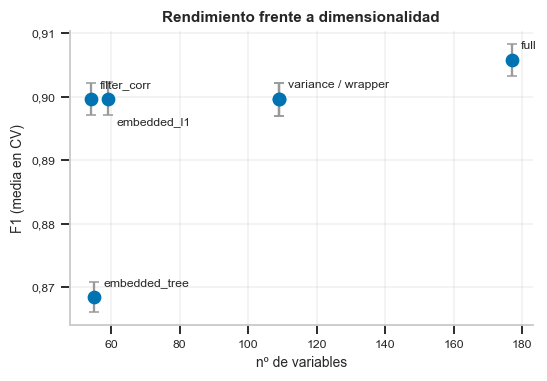

In [35]:
if GENERAR_FIGURAS:
    d = comparacion_seleccion
    fig, ax = plt.subplots(figsize=ancho(0.92, 0.64))
    ax.errorbar(d['n_variables'], d['f1_mean'], yerr=d['f1_std'], fmt='o',
                color=C_A, ecolor='0.6', capsize=3, ms=8, zorder=3)
    # Las etiquetas se pisaban por dos motivos: variance y wrapper caen en
    # el MISMO punto (109 variables y el mismo F1), y filter_corr y
    # embedded_l1 quedan a cinco variables una de otra. Se rotulan juntas
    # las que coinciden y se manda abajo la que chocaria con otra ya puesta.
    juntos = (d.groupby(['n_variables', 'f1_mean'])['subconjunto']
              .apply(lambda s: ' / '.join(sorted(s)))
              .reset_index().sort_values('n_variables'))
    margen_x = (d['n_variables'].max() - d['n_variables'].min()) * 0.2
    margen_y = (d['f1_mean'].max() - d['f1_mean'].min()) * 0.1
    puestas = []
    for _, r in juntos.iterrows():
        arriba = not any(abs(r['n_variables'] - px) < margen_x
                         and abs(r['f1_mean'] - py) < margen_y and pa
                         for px, py, pa in puestas)
        ax.annotate(r['subconjunto'], (r['n_variables'], r['f1_mean']),
                    textcoords='offset points',
                    xytext=(6, 6) if arriba else (6, -12),
                    va='bottom' if arriba else 'top', fontsize=8)
        puestas.append((r['n_variables'], r['f1_mean'], arriba))
    ax.set_xlabel('nº de variables'); ax.set_ylabel('F1 (media en CV)')
    ax.set_title('Rendimiento frente a dimensionalidad')
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b3_f1_vs_variables', exportar='fs_f1_nfeatures')
    plt.show()

### Versiones reducidas

Se generan dos: **escalada** (para modelos sensibles a la escala) y **sin
escalar** (para árboles). Las dos con las mismas variables, para que la
comparación entre familias de modelos siga siendo justa.

> La decisión de este bloque se ha tomado con regresión logística, que es
> sensible a la multicolinealidad. Como el modelo final acabará siendo un
> ensamblado de árboles —robusto a la redundancia—, en el bloque 7 se
> **reevalúa** con el modelo ya ajustado y un contraste de Wilcoxon.

In [36]:
def _reducir():
    cols = list(VARIABLES_FINALES) + [DIANA]
    return train_esc[cols].copy(), test_esc[cols].copy()

def _reducir_arbol():
    cols = list(VARIABLES_FINALES) + [DIANA]
    return train_imp[cols].copy(), test_imp[cols].copy()

train_sel, test_sel = punto_particion('v06_seleccionado', _reducir)
train_arbol, test_arbol = punto_particion('v06_seleccionado_arbol', _reducir_arbol)

print(f'Escalada    (modelos lineales/SVM/kNN/redes): {train_sel.shape}')
print(f'Sin escalar (modelos de árboles)            : {train_arbol.shape}')
registrar_version('v06_seleccionado_train', train_sel, 'v05_escalado_train',
                  f'Reducido a {len(VARIABLES_FINALES)} variables ({SUBCONJUNTO_FINAL})',
                  'Parsimonia e interpretabilidad sin pérdida relevante de rendimiento')

# El linaje ya esta completo: se vuelve a guardar. La version que dejo el
# bloque 2 llegaba solo hasta v05, porque esta fila aun no existia.
tabla(pd.DataFrame(LINAJE)[['version', 'origen', 'filas', 'columnas',
                            'descripcion']], 'linaje_datos', mostrar=False)
assert len(LINAJE) == 7, f'El linaje tiene {len(LINAJE)} versiones, esperaba 7'

  [checkpoint] «v06_seleccionado» cargado (train + test)
  [checkpoint] «v06_seleccionado_arbol» cargado (train + test)
Escalada    (modelos lineales/SVM/kNN/redes): (69757, 55)
Sin escalar (modelos de árboles)            : (69757, 55)
  -> v06_seleccionado_train: 69,757 × 55 (Reducido a 54 variables (filter_corr))


---

# Bloque 4 — Reducción de dimensionalidad

Seleccionar variables no es la única forma de reducir dimensiones: también
se pueden **proyectar** a un espacio nuevo. La pregunta que responde este
bloque es si merece la pena.

- **PCA**: proyección lineal no supervisada que maximiza la varianza
  retenida. Las componentes son combinaciones de todas las variables, así
  que se gana compacidad y se pierde interpretabilidad.
- **LDA**: proyección supervisada; en clasificación binaria comprime a una
  única dimensión, la que mejor separa las clases.

Se comparan las cuatro representaciones disponibles bajo el mismo protocolo.

In [37]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def _proyecciones():
    X_tr = train_sel[VARIABLES_FINALES]
    # PCA sobre las variables escaladas completas, reteniendo el 95 % de varianza.
    pca = PCA(n_components=0.95, random_state=SEMILLA).fit(train_esc[VARIABLES_IMP])
    comp_pca = pd.DataFrame(pca.transform(train_esc[VARIABLES_IMP]),
                            columns=[f'pc{i+1}' for i in range(pca.n_components_)])
    comp_pca[DIANA] = y_esc.values
    lda = LinearDiscriminantAnalysis(n_components=1).fit(train_esc[VARIABLES_IMP], y_esc)
    comp_lda = pd.DataFrame(lda.transform(train_esc[VARIABLES_IMP]), columns=['ld1'])
    comp_lda[DIANA] = y_esc.values
    return {'pca': comp_pca, 'lda': comp_lda,
            'n_componentes_pca': int(pca.n_components_),
            'varianza_explicada': pca.explained_variance_ratio_.tolist()}

proyecciones = punto('proyecciones', _proyecciones)
print(f"PCA: {proyecciones['n_componentes_pca']} componentes retienen el 95 % "
      f"de la varianza (de {len(VARIABLES_IMP)} variables)")
print('LDA: 1 componente (máximo en clasificación binaria)')

  [checkpoint] «proyecciones» cargado de proyecciones.joblib
PCA: 48 componentes retienen el 95 % de la varianza (de 177 variables)
LDA: 1 componente (máximo en clasificación binaria)


In [38]:
def _comparar_representaciones():
    conjuntos = {
        f'completa ({len(VARIABLES_IMP)})': (train_esc[VARIABLES_IMP], y_esc),
        f'selección ({len(VARIABLES_FINALES)})': (train_sel[VARIABLES_FINALES], y_esc),
        f"PCA ({proyecciones['n_componentes_pca']})":
            (proyecciones['pca'].drop(columns=DIANA), proyecciones['pca'][DIANA]),
        'LDA (1)': (proyecciones['lda'][['ld1']], proyecciones['lda'][DIANA]),
    }
    filas = []
    for nombre, (X_r, y_r) in conjuntos.items():
        res = evaluar(LogisticRegression(max_iter=1000, random_state=SEMILLA), X_r, y_r)
        res.update({'representacion': nombre, 'n_dimensiones': X_r.shape[1]})
        filas.append(res)
        print(f"  {nombre:22s} F1={res['f1_mean']:.4f}  MCC={res['mcc_mean']:.4f}")
    return pd.DataFrame(filas)

comparacion_representaciones = punto('representaciones', _comparar_representaciones)
for _, r in comparacion_representaciones.iterrows():
    registrar('4_reduccion', 'representacion', 'LogisticRegression',
              {'f1': r['f1_mean'], 'mcc': r['mcc_mean']},
              {'representacion': r['representacion'], 'n': r['n_dimensiones']})

print()
tabla(comparacion_representaciones[['representacion', 'n_dimensiones', 'f1_mean',
                                    'f1_std', 'average_precision_mean', 'mcc_mean']]
      .sort_values('f1_mean', ascending=False).round(4).reset_index(drop=True),
      'reduccion_comparacion_representaciones')

  [checkpoint] «representaciones» cargado de representaciones.parquet

representacion  n_dimensiones  f1_mean  f1_std  average_precision_mean  mcc_mean
completa (177)            177   0.9058  0.0025                  0.9650    0.8546
       LDA (1)              1   0.9000  0.0016                  0.9605    0.8447
selección (54)             54   0.8996  0.0025                  0.9617    0.8451
      PCA (48)             48   0.8793  0.0017                  0.9530    0.8134


,representacion,n_dimensiones,f1_mean,f1_std,average_precision_mean,mcc_mean
0,completa (177),177,0.9058,0.0025,0.9650,0.8546
1,LDA (1),1,0.9000,0.0016,0.9605,0.8447
2,selección (54),54,0.8996,0.0025,0.9617,0.8451
3,PCA (48),48,0.8793,0.0017,0.9530,0.8134


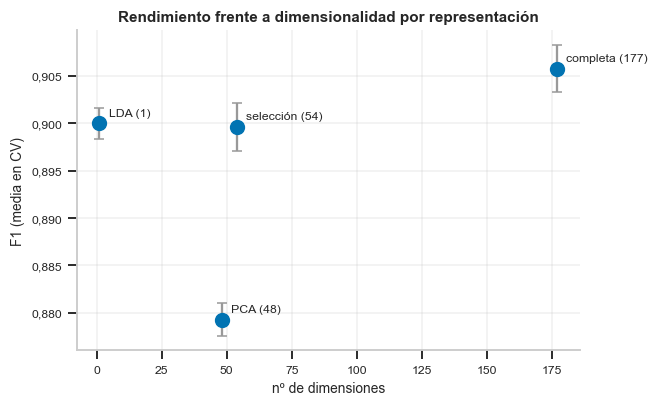

In [39]:
if GENERAR_FIGURAS:
    d = comparacion_representaciones
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.64))
    ax.errorbar(d['n_dimensiones'], d['f1_mean'], yerr=d['f1_std'], fmt='o',
                ms=9, color=C_A, ecolor='0.6', capsize=3, zorder=3)
    for _, r in d.iterrows():
        ax.annotate(r['representacion'], (r['n_dimensiones'], r['f1_mean']),
                    textcoords='offset points', xytext=(6, 5), fontsize=8)
    ax.set_xlabel('nº de dimensiones'); ax.set_ylabel('F1 (media en CV)')
    ax.set_title('Rendimiento frente a dimensionalidad por representación')
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b4_representaciones', exportar='dr_representation')
    plt.show()

## 4.1. Proyecciones no lineales para visualizar

PCA y LDA son lineales. Si las clases se separasen por una frontera curva, no
lo verían. Tres técnicas no lineales responden a esa duda:

- **t-SNE**: preserva la estructura local; excelente para ver agrupaciones,
  pero no proyecta datos nuevos, así que no sirve como representación de
  trabajo (van der Maaten & Hinton, 2008).
- **UMAP**: preserva mejor la estructura global y **sí** proyecta datos
  nuevos (McInnes et al., 2018).
- **Kernel PCA (RBF)**: PCA en un espacio transformado de dimensión mayor; su
  coste O(n²) obliga a usar una submuestra.

Se calculan sobre una submuestra estratificada, que es lo habitual y
suficiente para la lectura visual que se busca.

In [40]:
from sklearn.decomposition import KernelPCA
from sklearn.manifold import TSNE

def _proyecciones_no_lineales():
    n = 5000 if MODO == 'completo' else 800
    X_v, y_v = submuestrear(train_sel[VARIABLES_FINALES], train_sel[DIANA], n)
    pca2 = PCA(n_components=2, random_state=SEMILLA).fit_transform(X_v)
    tsne = TSNE(n_components=2, random_state=SEMILLA, init='pca',
                perplexity=30 if MODO == 'completo' else 10).fit_transform(X_v)
    umap_xy = None
    try:
        import umap
        umap_xy = umap.UMAP(n_components=2, random_state=SEMILLA).fit_transform(X_v)
    except Exception as err:
        print(f'  [aviso] UMAP no disponible ({err}); se omite esa proyección.')
    kpca = KernelPCA(n_components=2, kernel='rbf',
                     random_state=SEMILLA).fit_transform(X_v)
    return {'pca2': pca2, 'tsne': tsne, 'umap': umap_xy, 'kpca': kpca,
            'y': y_v.values}

no_lineales = punto('proyecciones_no_lineales', _proyecciones_no_lineales)
print(f"Proyecciones calculadas sobre {len(no_lineales['y']):,} instancias.")

  [checkpoint] «proyecciones_no_lineales» cargado de proyecciones_no_lineales.joblib
Proyecciones calculadas sobre 5,000 instancias.


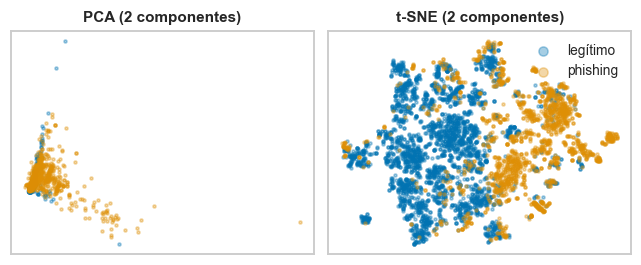

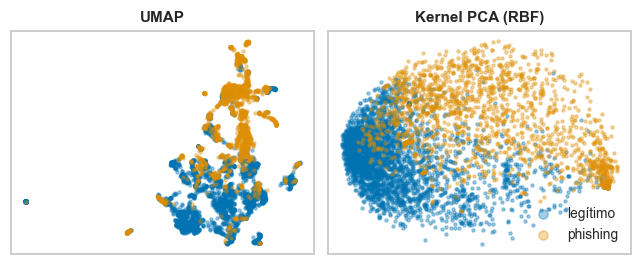

In [41]:
def dispersion(ax, xy, titulo):
    etiquetas = no_lineales['y']
    for clase, color, nombre in [(0, C_A, 'legítimo'), (1, C_B, 'phishing')]:
        m = etiquetas == clase
        ax.scatter(xy[m, 0], xy[m, 1], s=4, alpha=0.35, color=color, label=nombre)
    ax.set_title(titulo)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(False)

if GENERAR_FIGURAS:
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.42))
    dispersion(axes[0], no_lineales['pca2'], 'PCA (2 componentes)')
    dispersion(axes[1], no_lineales['tsne'], 't-SNE (2 componentes)')
    axes[1].legend(markerscale=3, fontsize=9)
    fig.tight_layout()
    figura(fig, 'b4_pca_tsne', exportar='dr_tsne')
    plt.show()

    disponibles = [('UMAP', no_lineales['umap']), ('Kernel PCA (RBF)', no_lineales['kpca'])]
    disponibles = [(t, xy) for t, xy in disponibles if xy is not None]
    fig, axes = plt.subplots(1, len(disponibles), figsize=ancho(1.0, 0.42))
    axes = np.atleast_1d(axes)
    for ax, (titulo, xy) in zip(axes, disponibles):
        dispersion(ax, np.asarray(xy), titulo)
    axes[-1].legend(markerscale=3, fontsize=9)
    fig.tight_layout()
    figura(fig, 'b4_umap_kpca', exportar='dr_umap_kpca')
    plt.show()

Las tres coinciden: las clases se separan bien, y algo mejor de forma no
lineal que con una proyección lineal. Eso explica por qué los ensamblados de
árboles acabarán ganando en el bloque 6. Pero como **representación de
trabajo** ninguna compensa: t-SNE ni siquiera puede proyectar datos nuevos, y
UMAP y Kernel PCA producen dimensiones sin significado. Se quedan como
herramientas exploratorias.

### Decisión

PCA necesita del orden de 48 componentes para retener el 95 % de la
varianza: una dimensionalidad comparable a la de la selección, pero con
componentes que ya no son variables del dominio. LDA comprime a una sola
dimensión con una separación notable, útil para visualizar, insuficiente
como representación de trabajo.

**Se adopta la selección de variables.** A igualdad práctica de
rendimiento, conservar variables con significado —"número de barras en la
URL", "antigüedad del dominio"— es lo que permite que el bloque 9 diga algo
y no solo mida algo. PCA y LDA quedan documentadas como alternativas.

---

# Bloque 5 — Balanceo de clases

Con IR ≈ 1,89 el desbalanceo es **moderado**. Eso no significa que el
balanceo sobre, significa que hay que comprobarlo en vez de aplicarlo por
inercia: las técnicas de remuestreo tienen coste y efectos secundarios
(SMOTE interpola instancias sintéticas que pueden no ser realistas; el
submuestreo tira información).

Se comparan catorce estrategias de cuatro familias:

- **A nivel de algoritmo**: `class_weight='balanced'`, que pondera la
  pérdida sin tocar los datos.
- **Sobremuestreo**: SMOTE, BorderlineSMOTE, ADASYN y réplica aleatoria.
- **Submuestreo**: reducción de la clase mayoritaria, al azar o con criterio
  (TomekLinks y ENN limpian la frontera, NearMiss selecciona por cercanía).
- **Híbridos**: sobremuestrear y después limpiar (SMOTETomek, SMOTEENN).

Las catorce se evalúan con el **mismo protocolo** —entrenamiento completo y
validación cruzada de 5 pliegues—, que es lo que hace la tabla comparable.

Punto crítico de método: el remuestreo se aplica **dentro de cada pliegue**
mediante un `Pipeline` de *imbalanced-learn*. Balancear antes de partir
filtraría instancias sintéticas al conjunto de validación y daría un
resultado falsamente bueno.

In [42]:
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import ADASYN, BorderlineSMOTE, RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as PipelineIMB
from imblearn.under_sampling import (EditedNearestNeighbours, NearMiss,
                                     RandomUnderSampler, TomekLinks)

X_sel, y_sel = train_sel[VARIABLES_FINALES], train_sel[DIANA]

def quizas_reducir(X, y):
    '''En modo completo devuelve todo; en modo rapido, una submuestra.'''
    return submuestrear(X, y, len(X) if MODO == 'completo' else 3000)

def _comparar_balanceo():
    base = lambda: LogisticRegression(max_iter=1000, random_state=SEMILLA)
    def con_remuestreo(remuestreador):
        return PipelineIMB([('rs', remuestreador), ('clf', base())])

    esquemas = {
        # A nivel de algoritmo: se pondera la pérdida, no se tocan los datos.
        'sin_balanceo': base(),
        'balanced': LogisticRegression(max_iter=1000, random_state=SEMILLA,
                                       class_weight='balanced'),
        'peso_2:1': LogisticRegression(max_iter=1000, random_state=SEMILLA,
                                       class_weight={0: 1, 1: 2}),
        'peso_3:1': LogisticRegression(max_iter=1000, random_state=SEMILLA,
                                       class_weight={0: 1, 1: 3}),
        # Sobremuestreo de la clase minoritaria.
        'SMOTE': con_remuestreo(SMOTE(random_state=SEMILLA)),
        'BorderlineSMOTE': con_remuestreo(
            BorderlineSMOTE(random_state=SEMILLA, k_neighbors=5)),
        'ADASYN': con_remuestreo(ADASYN(random_state=SEMILLA)),
        'RandomOver': con_remuestreo(RandomOverSampler(random_state=SEMILLA)),
        # Submuestreo de la clase mayoritaria.
        'RandomUnder': con_remuestreo(RandomUnderSampler(random_state=SEMILLA)),
        'TomekLinks': con_remuestreo(TomekLinks(n_jobs=-1)),
        'ENN': con_remuestreo(EditedNearestNeighbours(n_jobs=-1)),
        'NearMiss-1': con_remuestreo(NearMiss(version=1, n_jobs=-1)),
        # Híbridos: sobremuestrear y después limpiar.
        'SMOTETomek': con_remuestreo(SMOTETomek(
            random_state=SEMILLA, tomek=TomekLinks(n_jobs=-1))),
        'SMOTEENN': con_remuestreo(SMOTEENN(
            random_state=SEMILLA, enn=EditedNearestNeighbours(n_jobs=-1))),
    }
    # Todas con el MISMO protocolo, que es lo que hace comparable la tabla:
    # entrenamiento completo y validación cruzada de 5 pliegues.
    X_b, y_b = quizas_reducir(X_sel, y_sel)
    filas = []
    for nombre, modelo in esquemas.items():
        t0 = time.perf_counter()
        res = evaluar(modelo, X_b, y_b)
        res.update({'esquema': nombre, 'protocolo': 'train_completo_cv5',
                    'tiempo_s': round(time.perf_counter() - t0, 1)})
        filas.append(res)
        print(f"  {nombre:18s} F1={res['f1_mean']:.4f}  "
              f"recall={res['recall_mean']:.4f}  "
              f"precision={res['precision_mean']:.4f}  "
              f"MCC={res['mcc_mean']:.4f}  ({res['tiempo_s']}s)")
    return pd.DataFrame(filas)

comparacion_balanceo = punto('balanceo', _comparar_balanceo)
for _, r in comparacion_balanceo.iterrows():
    registrar('5_balanceo', 'balanceo', 'LogisticRegression',
              {'f1': r['f1_mean'], 'mcc': r['mcc_mean'], 'recall': r['recall_mean']},
              {'esquema': r['esquema']}, datos='v06_seleccionado')

print()
tabla(comparacion_balanceo[['esquema', 'f1_mean', 'recall_mean',
                            'precision_mean', 'average_precision_mean', 'mcc_mean']]
      .sort_values('mcc_mean', ascending=False).round(4).reset_index(drop=True),
      'balanceo_comparacion')

  [checkpoint] «balanceo» cargado de balanceo.parquet

        esquema  f1_mean  recall_mean  precision_mean  average_precision_mean  mcc_mean
     TomekLinks   0.9000       0.9114          0.8889                  0.9617    0.8453
   sin_balanceo   0.8996       0.9071          0.8923                  0.9617    0.8451
            ENN   0.8987       0.9360          0.8642                  0.9604    0.8424
       SMOTEENN   0.8972       0.9275          0.8688                  0.9612    0.8402
     SMOTETomek   0.8945       0.9392          0.8539                  0.9612    0.8359
          SMOTE   0.8938       0.9397          0.8522                  0.9612    0.8348
       balanced   0.8937       0.9419          0.8502                  0.9613    0.8347
    RandomUnder   0.8934       0.9417          0.8497                  0.9612    0.8341
     RandomOver   0.8934       0.9415          0.8500                  0.9612    0.8341
       peso_2:1   0.8922       0.9443          0.8455            

,esquema,f1_mean,recall_mean,precision_mean,average_precision_mean,mcc_mean
0,TomekLinks,0.9000,0.9114,0.8889,0.9617,0.8453
1,sin_balanceo,0.8996,0.9071,0.8923,0.9617,0.8451
2,ENN,0.8987,0.9360,0.8642,0.9604,0.8424
3,SMOTEENN,0.8972,0.9275,0.8688,0.9612,0.8402
4,SMOTETomek,0.8945,0.9392,0.8539,0.9612,0.8359
5,SMOTE,0.8938,0.9397,0.8522,0.9612,0.8348
6,balanced,0.8937,0.9419,0.8502,0.9613,0.8347
7,RandomUnder,0.8934,0.9417,0.8497,0.9612,0.8341
8,RandomOver,0.8934,0.9415,0.8500,0.9612,0.8341
9,peso_2:1,0.8922,0.9443,0.8455,0.9613,0.8323


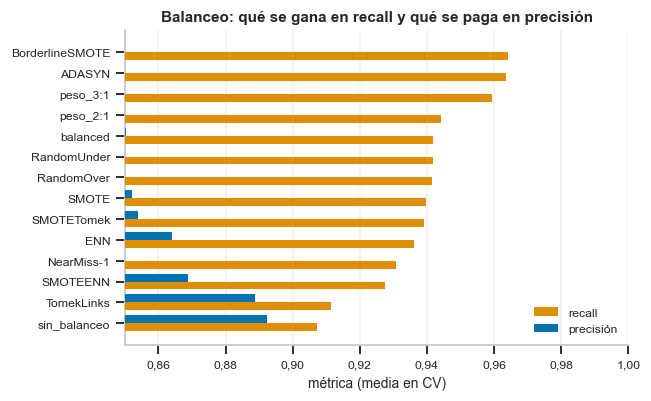

In [43]:
if GENERAR_FIGURAS:
    d = comparacion_balanceo.sort_values('recall_mean')
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.63))
    y = np.arange(len(d)); h = 0.38
    ax.barh(y - h/2, d['recall_mean'], h, label='recall',
            color=C_B, zorder=3)
    ax.barh(y + h/2, d['precision_mean'], h, label='precisión',
            color=C_A, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(d['esquema'])
    ax.set_xlim(0.85, 1.0)
    ax.set_xlabel('métrica (media en CV)')
    ax.set_title('Balanceo: qué se gana en recall y qué se paga en precisión')
    ax.legend(loc='lower right')
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b5_balanceo', exportar='bal_tradeoff')
    plt.show()

### Decisión

El patrón es el esperado con desbalanceo moderado: el remuestreo **sube la
recall y baja la precisión**, y el intercambio no compensa en las
métricas equilibradas (F1 y MCC), que es lo que aquí importa. Ninguna
técnica supera de forma consistente a no hacer nada.

**Se entrena sin balanceo.** Lo que sí queda pendiente —y se resuelve en el
bloque 7 con el modelo final ya ajustado— es el **umbral de decisión**: una
vía más flexible y sin reentrenar para priorizar la detección de phishing
cuando el coste de un falso negativo lo justifique.

In [44]:
mejor_balanceo = (comparacion_balanceo.sort_values('mcc_mean', ascending=False)
                  .iloc[0]['esquema'])
sin_balanceo = comparacion_balanceo[
    comparacion_balanceo['esquema'] == 'sin_balanceo'].iloc[0]
print(f"Mejor esquema por MCC : {mejor_balanceo}")
print(f"Sin balanceo          : F1={sin_balanceo['f1_mean']:.4f}  "
      f"MCC={sin_balanceo['mcc_mean']:.4f}")
print('\nDECISIÓN: se entrena sin balanceo; el punto de operación se ajusta')
print('mediante el umbral de decisión (bloque 7).')

Mejor esquema por MCC : TomekLinks
Sin balanceo          : F1=0.8996  MCC=0.8451

DECISIÓN: se entrena sin balanceo; el punto de operación se ajusta
mediante el umbral de decisión (bloque 7).


---

# Bloque 6 — Entrenamiento y comparación de modelos

Diecinueve modelos de seis familias, todos bajo el **mismo protocolo**:
validación cruzada estratificada de 5 pliegues, semilla fija, sin balanceo y
la misma representación de 54 variables. Sin esa homogeneidad la comparación
no diría nada.

| Familia | Modelos | Datos |
|---------|---------|-------|
| Referencia | Dummy (mayoritaria, estratificada) | escalados |
| Lineales | Regresión logística, SGD (log-loss), LDA | escalados |
| SVM | LinearSVC, SVM-RBF aproximada por Nyström | escalados |
| Vecinos y bayesiano | kNN (k=5, k=15), GaussianNB | escalados |
| Árboles y ensamblados | Árbol, Random Forest, Extra Trees, HistGB, XGBoost, LightGBM, CatBoost | sin escalar |
| Redes | MLP (100), MLP (64,32) | escalados |

Dos decisiones que conviene justificar:

- Los **modelos triviales** fijan el suelo: cualquier modelo que no los
  supere con holgura no está aprendiendo nada.
- La **SVM con kernel RBF exacta** tiene coste O(n²)–O(n³), inviable con
  70 000 instancias. Se usa la aproximación de **Nyström**, que proyecta a
  un espacio explícito donde una SVM lineal recupera el poder del kernel con
  coste lineal (Williams & Seeger, 2001).

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.kernel_approximation import Nystroem
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# En modo completo se usa todo el entrenamiento; en modo rápido, una parte.
N_MODELOS = len(train_sel) if MODO == 'completo' else 3000
X_lin, y_lin = submuestrear(train_sel[VARIABLES_FINALES], train_sel[DIANA],
                            N_MODELOS)
X_arb, y_arb = submuestrear(train_arbol[VARIABLES_FINALES], train_arbol[DIANA],
                            N_MODELOS)

MODELOS_ESCALADOS = {
    'Dummy(mayoritaria)': DummyClassifier(strategy='most_frequent'),
    'Dummy(estratificada)': DummyClassifier(strategy='stratified', random_state=SEMILLA),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=SEMILLA),
    'SGD(log_loss)': SGDClassifier(loss='log_loss', random_state=SEMILLA),
    'LDA': LinearDiscriminantAnalysis(),
    'LinearSVC': LinearSVC(C=1.0, random_state=SEMILLA, dual='auto', max_iter=5000),
    'SVM-RBF(Nystroem)': Pipeline([
        ('nystroem', Nystroem(kernel='rbf', n_components=300, random_state=SEMILLA)),
        ('svc', LinearSVC(C=1.0, random_state=SEMILLA, dual='auto', max_iter=5000))]),
    'kNN(k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'kNN(k=15)': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    'GaussianNB': GaussianNB(),
    'MLP(100)': MLPClassifier(hidden_layer_sizes=(100,), max_iter=200,
                              early_stopping=True, random_state=SEMILLA),
    'MLP(64,32)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200,
                                early_stopping=True, random_state=SEMILLA),
}
MODELOS_ARBOLES = {
    'DecisionTree': DecisionTreeClassifier(random_state=SEMILLA),
    'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                           random_state=SEMILLA),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=300, n_jobs=-1,
                                       random_state=SEMILLA),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=SEMILLA),
    'XGBoost': XGBClassifier(n_estimators=300, tree_method='hist', n_jobs=-1,
                             random_state=SEMILLA, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=300, n_jobs=-1,
                               random_state=SEMILLA, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=500 if MODO == 'completo' else 100,
                                   random_seed=SEMILLA, verbose=0,
                                   thread_count=-1, allow_writing_files=False),
}
print(f'{len(MODELOS_ESCALADOS) + len(MODELOS_ARBOLES)} modelos por evaluar '
      f'sobre {X_lin.shape[0]:,} × {X_lin.shape[1]}')

19 modelos por evaluar sobre 69,757 × 54


In [46]:
def _leaderboard():
    print('Modelos sobre datos escalados:')
    esc = evaluar_varios(MODELOS_ESCALADOS, X_lin, y_lin,
                         familia='escalados', datos='v06_seleccionado',
                         bloque='6_modelos')
    print('\nModelos sobre datos sin escalar (árboles):')
    arb = evaluar_varios(MODELOS_ARBOLES, X_arb, y_arb,
                         familia='arboles', datos='v06_seleccionado_arbol',
                         bloque='6_modelos')
    return pd.concat([esc, arb], ignore_index=True)

leaderboard = punto('leaderboard', _leaderboard)
leaderboard = leaderboard.sort_values('f1_mean', ascending=False).reset_index(drop=True)
print()
tabla(leaderboard[COLS_RESUMEN].round(4), 'modelos_leaderboard')

  [checkpoint] «leaderboard» cargado de leaderboard.parquet

              modelo  f1_mean  f1_std  average_precision_mean  roc_auc_mean  mcc_mean  recall_mean  precision_mean  tiempo_s
             XGBoost   0.9601  0.0020                  0.9920        0.9954    0.9386       0.9595          0.9607       2.7
            LightGBM   0.9579  0.0022                  0.9921        0.9954    0.9353       0.9579          0.9579       2.3
        RandomForest   0.9568  0.0022                  0.9915        0.9951    0.9334       0.9610          0.9526       8.6
          ExtraTrees   0.9558  0.0022                  0.9914        0.9948    0.9320       0.9584          0.9533       7.5
            CatBoost   0.9552  0.0025                  0.9911        0.9950    0.9312       0.9557          0.9548       9.2
HistGradientBoosting   0.9513  0.0019                  0.9898        0.9942    0.9250       0.9531          0.9495       2.7
          MLP(64,32)   0.9453  0.0028                  0.9863   

,modelo,f1_mean,f1_std,average_precision_mean,roc_auc_mean,mcc_mean,recall_mean,precision_mean,tiempo_s
0,XGBoost,0.9601,0.0020,0.9920,0.9954,0.9386,0.9595,0.9607,2.7
1,LightGBM,0.9579,0.0022,0.9921,0.9954,0.9353,0.9579,0.9579,2.3
2,RandomForest,0.9568,0.0022,0.9915,0.9951,0.9334,0.9610,0.9526,8.6
3,ExtraTrees,0.9558,0.0022,0.9914,0.9948,0.9320,0.9584,0.9533,7.5
4,CatBoost,0.9552,0.0025,0.9911,0.9950,0.9312,0.9557,0.9548,9.2
5,HistGradientBoosting,0.9513,0.0019,0.9898,0.9942,0.9250,0.9531,0.9495,2.7
6,"MLP(64,32)",0.9453,0.0028,0.9863,0.9921,0.9160,0.9420,0.9485,5.9
7,MLP(100),0.9434,0.0030,0.9855,0.9919,0.9132,0.9391,0.9478,10.5
8,DecisionTree,0.9315,0.0028,0.8916,0.9473,0.8946,0.9314,0.9315,0.7
9,kNN(k=5),0.9291,0.0022,0.9608,0.9805,0.8915,0.9206,0.9376,7.5


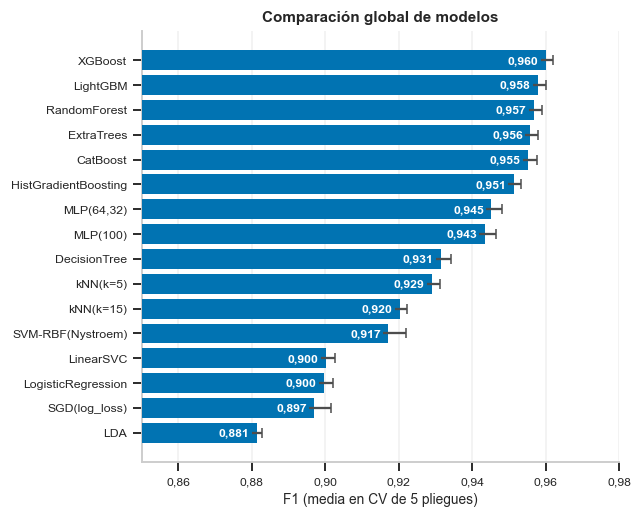

Nota: la figura muestra solo los modelos con F1 ≥ 0,85 para que la
escala sea legible; los triviales y GaussianNB constan en la tabla.


In [47]:
if GENERAR_FIGURAS:
    d = leaderboard[leaderboard['f1_mean'] >= 0.85].sort_values('f1_mean')
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.81))
    ax.barh(d['modelo'], d['f1_mean'], xerr=d['f1_std'], color=C_A,
            zorder=3, error_kw={'ecolor': '0.3', 'capsize': 3})
    # Igual que en el contraste estadistico: el rotulo va DENTRO de la
    # barra, porque a la derecha del extremo pasa la barra de error y sus
    # topes partian los digitos.
    for y, v in zip(range(len(d)), d['f1_mean']):
        ax.text(v - 0.002, y, f'{v:.3f}'.replace('.', ','), va='center',
                ha='right', fontsize=8, color='white', fontweight='bold',
                zorder=5,
                bbox=dict(facecolor=C_A, edgecolor='none', pad=1.4))
    ax.set_xlim(0.85, min(1.0, d['f1_mean'].max() + 0.02))
    ax.set_xlabel('F1 (media en CV de 5 pliegues)')
    ax.set_title('Comparación global de modelos')
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    coma(ax, 'x')
    fig.tight_layout()
    figura(fig, 'b6_leaderboard', exportar='models_leaderboard')
    plt.show()
    print('Nota: la figura muestra solo los modelos con F1 ≥ 0,85 para que la')
    print('escala sea legible; los triviales y GaussianNB constan en la tabla.')

### Candidatos a la optimización

Como es habitual en datos tabulares, los **ensamblados de árboles** dominan
la clasificación: capturan interacciones no lineales que los modelos
lineales no ven, sin necesitar el volumen de datos ni el ajuste que exige
una red neuronal (Grinsztajn et al., 2022).

Sobre los ensamblados combinados: cuando la diferencia con el mejor
*boosting* individual **no es significativa** tras la corrección de Holm, la
parsimonia manda —un stacking triplica el coste de entrenamiento y de
inferencia y complica la interpretación, a cambio de nada demostrable.

Pasan a la fase de optimización los tres mejores modelos no triviales.

In [48]:
no_triviales = leaderboard[~leaderboard['modelo'].str.startswith('Dummy')]
CANDIDATOS_OPT = no_triviales.head(3)['modelo'].tolist()
print('Modelos candidatos a la optimización de hiperparámetros:')
print(no_triviales.head(3)[['modelo', 'familia', 'f1_mean', 'mcc_mean']]
      .round(4).to_string(index=False))

Modelos candidatos a la optimización de hiperparámetros:
      modelo familia  f1_mean  mcc_mean
     XGBoost arboles   0.9601    0.9386
    LightGBM arboles   0.9579    0.9353
RandomForest arboles   0.9568    0.9334


---

# Bloque 7 — Optimización de hiperparámetros y verificaciones finales

Tres cosas en este bloque:

1. **Optimización bayesiana** (Optuna/TPE) de los modelos candidatos, y
   elección del modelo final.
2. **Validación cruzada anidada**, que da una estimación **insesgada** del
   rendimiento: cuando se elige el modelo mirando la misma validación
   cruzada con la que se mide, esa medida queda contaminada (Cawley &
   Talbot, 2010). La CV anidada separa ambas cosas.
3. Dos **verificaciones sobre el modelo final** que quedaron pendientes:
   ¿sigue siendo buena la selección de variables ahora que el modelo es un
   árbol? ¿y el balanceo?

### Por qué optimización bayesiana

La búsqueda en rejilla explora combinaciones ciegamente y su coste explota
con la dimensión. La búsqueda aleatoria es mejor de lo que parece (Bergstra
& Bengio, 2012), pero tampoco aprende. La **optimización bayesiana**
construye un modelo probabilístico de la función objetivo y decide dónde
probar a continuación, lo que le permite llegar más lejos con menos
evaluaciones.

In [49]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.stats import loguniform, randint, uniform

X_opt, y_opt = train_arbol[VARIABLES_FINALES], train_arbol[DIANA]
X_busq, y_busq = submuestrear(X_opt, y_opt, N_SUB_OPTUNA)
CV_INTERNA = cv(n_splits=3)

def espacio_xgb(t):
    return {'n_estimators': t.suggest_int('n_estimators', 100, 600),
            'max_depth': t.suggest_int('max_depth', 3, 10),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': t.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': t.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': t.suggest_int('min_child_weight', 1, 10),
            'reg_lambda': t.suggest_float('reg_lambda', 1e-3, 10, log=True)}

def espacio_lgbm(t):
    return {'n_estimators': t.suggest_int('n_estimators', 100, 600),
            'num_leaves': t.suggest_int('num_leaves', 15, 127),
            'max_depth': t.suggest_int('max_depth', 3, 12),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': t.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': t.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_lambda': t.suggest_float('reg_lambda', 1e-3, 10, log=True),
            'min_child_samples': t.suggest_int('min_child_samples', 5, 100)}

def espacio_rf(t):
    return {'n_estimators': t.suggest_int('n_estimators', 100, 400),
            'max_depth': t.suggest_int('max_depth', 5, 30),
            'max_features': t.suggest_float('max_features', 0.2, 1.0),
            'min_samples_split': t.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': t.suggest_int('min_samples_leaf', 1, 10)}

FABRICAS = {
    'XGBoost': (lambda p: XGBClassifier(tree_method='hist', n_jobs=-1,
                                        random_state=SEMILLA,
                                        eval_metric='logloss', **p), espacio_xgb),
    'LightGBM': (lambda p: LGBMClassifier(n_jobs=-1, random_state=SEMILLA,
                                          verbose=-1, **p), espacio_lgbm),
    'RandomForest': (lambda p: RandomForestClassifier(n_jobs=-1,
                                                      random_state=SEMILLA, **p),
                     espacio_rf),
}
print(f'Submuestra de búsqueda: {X_busq.shape[0]:,} | '
      f'entrenamiento completo: {X_opt.shape[0]:,}')
print(f'Ensayos por modelo    : {N_TRIALS}')

Submuestra de búsqueda: 25,000 | entrenamiento completo: 69,757
Ensayos por modelo    : 30


## 7.1. Qué estrategia de búsqueda usar

Antes de optimizar conviene decidir **cómo** se busca. Se comparan las tres
familias habituales con el mismo presupuesto de cómputo, sobre la submuestra
de búsqueda:

- **Búsqueda en rejilla**: prueba todas las combinaciones de una malla fija.
  Exhaustiva pero ciega, y su coste crece exponencialmente con el número de
  hiperparámetros (la maldición de la dimensionalidad aplicada a la
  búsqueda).
- **Búsqueda aleatoria**: muestrea al azar del espacio. Contra la intuición,
  suele ganar a la rejilla con el mismo presupuesto, porque no desperdicia
  evaluaciones en dimensiones que no importan (Bergstra & Bengio, 2012).
- **Optimización bayesiana (TPE)**: construye un modelo de la función
  objetivo y decide dónde probar a continuación.

In [50]:
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     cross_val_score)

def _estrategias_busqueda():
    malla = {'n_estimators': [200, 400], 'num_leaves': [31, 63],
             'learning_rate': [0.05, 0.1], 'max_depth': [6, 10]}
    distribuciones = {'n_estimators': randint(100, 600),
                      'num_leaves': randint(15, 127),
                      'max_depth': randint(3, 12),
                      'learning_rate': loguniform(0.01, 0.3),
                      'subsample': uniform(0.6, 0.4),
                      'colsample_bytree': uniform(0.6, 0.4),
                      'reg_lambda': loguniform(1e-3, 10),
                      'min_child_samples': randint(5, 100)}
    n_iter = N_TRIALS if MODO == 'completo' else 4
    filas = []

    t0 = time.perf_counter()
    base_lgbm = LGBMClassifier(n_jobs=-1, random_state=SEMILLA, verbose=-1)
    rejilla = GridSearchCV(base_lgbm, malla, scoring='f1', cv=CV_INTERNA, n_jobs=-1)
    rejilla.fit(X_busq, y_busq)
    filas.append({'estrategia': 'Rejilla', 'evaluaciones': len(rejilla.cv_results_['params']),
                  'mejor_f1': round(float(rejilla.best_score_), 4),
                  'tiempo_s': round(time.perf_counter() - t0, 1)})

    t0 = time.perf_counter()
    azar = RandomizedSearchCV(base_lgbm, distribuciones, n_iter=n_iter, scoring='f1',
                              cv=CV_INTERNA, random_state=SEMILLA, n_jobs=-1)
    azar.fit(X_busq, y_busq)
    filas.append({'estrategia': 'Aleatoria', 'evaluaciones': n_iter,
                  'mejor_f1': round(float(azar.best_score_), 4),
                  'tiempo_s': round(time.perf_counter() - t0, 1)})

    t0 = time.perf_counter()
    def objetivo(trial):
        return cross_val_score(
            LGBMClassifier(n_jobs=-1, random_state=SEMILLA, verbose=-1,
                           **espacio_lgbm(trial)), X_busq, y_busq,
                               scoring='f1', cv=CV_INTERNA, n_jobs=-1).mean()
    estudio = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=SEMILLA))
    estudio.optimize(objetivo, n_trials=n_iter, show_progress_bar=False)
    filas.append({'estrategia': 'Bayesiana (Optuna/TPE)', 'evaluaciones': n_iter,
                  'mejor_f1': round(float(estudio.best_value), 4),
                  'tiempo_s': round(time.perf_counter() - t0, 1)})
    return pd.DataFrame(filas)

estrategias = punto('estrategias_busqueda', _estrategias_busqueda)
for _, r in estrategias.iterrows():
    registrar('7_optimizacion', 'estrategia_busqueda', 'LightGBM',
              {'f1': r['mejor_f1']}, {'estrategia': r['estrategia'],
                                      'evaluaciones': int(r['evaluaciones'])})
tabla(estrategias, 'optimizacion_estrategias')

  [checkpoint] «estrategias_busqueda» cargado de estrategias_busqueda.parquet
            estrategia  evaluaciones  mejor_f1  tiempo_s
               Rejilla            16    0.9506      16.1
             Aleatoria            30    0.9501      29.4
Bayesiana (Optuna/TPE)            30    0.9513      44.6


,estrategia,evaluaciones,mejor_f1,tiempo_s
0,Rejilla,16,0.9506,16.1
1,Aleatoria,30,0.9501,29.4
2,Bayesiana (Optuna/TPE),30,0.9513,44.6


Las tres llegan prácticamente al mismo F1, lo que dice algo útil: el espacio
de hiperparámetros de LightGBM es **poco accidentado** para este problema, y
casi cualquier búsqueda razonable encuentra una buena configuración. Se
adopta la **bayesiana** porque escala mejor cuando el espacio crece y porque
permite persistir y auditar el estudio, no porque gane por rendimiento.

In [51]:
def _optimizar():
    mejores = {}
    for nombre, (fabrica, espacio) in FABRICAS.items():
        def objetivo(trial, fabrica=fabrica, espacio=espacio):
            modelo = fabrica(espacio(trial))
            return cross_val_score(modelo, X_busq, y_busq, scoring='f1',
                                   cv=CV_INTERNA, n_jobs=-1).mean()
        estudio = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=SEMILLA))
        t0 = time.perf_counter()
        estudio.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=False)
        mejores[nombre] = estudio.best_params
        print(f'  {nombre:14s} mejor F1 (submuestra, cv3) = '
              f'{estudio.best_value:.4f}  ({time.perf_counter() - t0:.0f}s)')
    return mejores

MEJORES_PARAMS = punto('mejores_hiperparametros', _optimizar)
for nombre, params in MEJORES_PARAMS.items():
    registrar('7_optimizacion', 'optuna_tpe', nombre, hiperparametros=params,
              datos='v06_seleccionado_arbol')
print()
print(json.dumps(MEJORES_PARAMS, indent=2))

  [checkpoint] «mejores_hiperparametros» cargado de mejores_hiperparametros.json

{
  "XGBoost": {
    "n_estimators": 596,
    "max_depth": 6,
    "learning_rate": 0.06077933753233006,
    "subsample": 0.7239015604990822,
    "colsample_bytree": 0.7066152446998185,
    "min_child_weight": 1,
    "reg_lambda": 0.03917832303073568
  },
  "LightGBM": {
    "n_estimators": 355,
    "num_leaves": 118,
    "max_depth": 11,
    "learning_rate": 0.10054871218671431,
    "subsample": 0.7061583976302458,
    "colsample_bytree": 0.9437884106748379,
    "reg_lambda": 3.2161320271888854,
    "min_child_samples": 6
  },
  "RandomForest": {
    "n_estimators": 252,
    "max_depth": 26,
    "max_features": 0.7027868748116165,
    "min_samples_split": 3,
    "min_samples_leaf": 1
  }
}


### Reevaluación sobre el entrenamiento completo y elección del modelo final

Los hiperparámetros se buscaron sobre una submuestra por coste. Antes de
elegir, los tres modelos ya ajustados se **reevalúan con validación cruzada
de 5 pliegues sobre el entrenamiento completo**, que es una comparación
fiable. El ganador se reajusta con todos los datos de entrenamiento y se
guarda.

In [52]:
def _modelo_final():
    filas = []
    for nombre, (fabrica, _) in FABRICAS.items():
        modelo = fabrica(MEJORES_PARAMS[nombre])
        res = evaluar(modelo, X_opt, y_opt)
        res['modelo'] = f'{nombre}(ajustado)'
        filas.append(res)
        print(f"  {nombre + '(ajustado)':22s} F1={res['f1_mean']:.4f}  "
              f"MCC={res['mcc_mean']:.4f}")
    comparacion = pd.DataFrame(filas).sort_values('f1_mean', ascending=False)
    ganador = comparacion.iloc[0]['modelo'].replace('(ajustado)', '')
    fabrica, _ = FABRICAS[ganador]
    modelo = fabrica(MEJORES_PARAMS[ganador])
    modelo.fit(X_opt, y_opt)
    joblib.dump(modelo, MODELOS / 'modelo_final.joblib')
    return {'comparacion': comparacion.to_dict('list'),
            'modelo_final': ganador,
            'hiperparametros': MEJORES_PARAMS[ganador],
            'f1_cv5_train': round(float(comparacion.iloc[0]['f1_mean']), 4),
            'datos': 'v06_seleccionado_arbol', 'semilla': SEMILLA,
            'n_variables': len(VARIABLES_FINALES)}

FICHA_MODELO = punto('modelo_final', _modelo_final)
MODELO_FINAL = FICHA_MODELO['modelo_final']
PARAMS_FINALES = FICHA_MODELO['hiperparametros']

comparacion_ajustados = pd.DataFrame(FICHA_MODELO['comparacion'])
print()
tabla(comparacion_ajustados[['modelo', 'f1_mean', 'f1_std',
                             'average_precision_mean', 'roc_auc_mean', 'mcc_mean']]
      .round(4).reset_index(drop=True), 'optimizacion_modelos_ajustados')
print(f'\nMODELO FINAL: {MODELO_FINAL} ajustado')
print(f'F1 en CV de 5 pliegues (train completo): {FICHA_MODELO["f1_cv5_train"]}')
print(f'Guardado en modelos/modelo_final.joblib')

def construir_final(**extra):
    '''Devuelve una instancia nueva del modelo final con sus hiperparámetros.'''
    fabrica, _ = FABRICAS[MODELO_FINAL]
    return fabrica({**PARAMS_FINALES, **extra})

  [checkpoint] «modelo_final» cargado de modelo_final.json

                modelo  f1_mean  f1_std  average_precision_mean  roc_auc_mean  mcc_mean
    LightGBM(ajustado)   0.9608  0.0021                  0.9927        0.9959    0.9398
     XGBoost(ajustado)   0.9596  0.0024                  0.9923        0.9956    0.9379
RandomForest(ajustado)   0.9566  0.0019                  0.9895        0.9944    0.9331

MODELO FINAL: LightGBM ajustado
F1 en CV de 5 pliegues (train completo): 0.9608
Guardado en modelos/modelo_final.joblib


### Estudio persistido: qué hiperparámetros importan de verdad

Se repite el estudio del modelo final guardándolo en SQLite —lo que permite
auditarlo y reanudarlo— con **poda** de los ensayos poco prometedores
(`MedianPruner`). De ahí salen dos lecturas útiles: cómo converge la
búsqueda y qué hiperparámetros mueven realmente la aguja.

In [53]:
def _estudio_persistido():
    almacen = f"sqlite:///{(MODELOS / 'optuna_estudio.db').as_posix()}"
    _, espacio = FABRICAS[MODELO_FINAL]
    fabrica, _ = FABRICAS[MODELO_FINAL]

    def objetivo(trial):
        modelo = fabrica(espacio(trial))
        return cross_val_score(modelo, X_busq, y_busq, scoring='f1',
                               cv=CV_INTERNA, n_jobs=-1).mean()

    estudio = optuna.create_study(
        direction='maximize', study_name=f'{MODELO_FINAL}_f1',
        sampler=optuna.samplers.TPESampler(seed=SEMILLA),
        pruner=optuna.pruners.MedianPruner(),
        storage=almacen, load_if_exists=True)
    estudio.optimize(objetivo, n_trials=N_TRIALS_ESTUDIO, show_progress_bar=False)
    historia = [{'ensayo': t.number, 'f1': t.value}
                for t in estudio.trials if t.value is not None]
    try:
        importancias = optuna.importance.get_param_importances(estudio)
        importancias = {k: float(v) for k, v in importancias.items()}
    except Exception:
        importancias = {}
    return {'historia': historia, 'importancia_parametros': importancias,
            'mejor_f1': float(estudio.best_value)}

estudio = punto('estudio_optuna', _estudio_persistido)
historia = pd.DataFrame(estudio['historia'])
print(f"Ensayos registrados: {len(historia)} | mejor F1: {estudio['mejor_f1']:.4f}")
print('Estudio persistido en modelos/optuna_estudio.db')
if estudio['importancia_parametros']:
    print('\nImportancia relativa de los hiperparámetros:')
    for k, v in estudio['importancia_parametros'].items():
        print(f'  {k:20s} {v:.3f}')

  [checkpoint] «estudio_optuna» cargado de estudio_optuna.json
Ensayos registrados: 60 | mejor F1: 0.9515
Estudio persistido en modelos/optuna_estudio.db

Importancia relativa de los hiperparámetros:
  max_depth            0.440
  num_leaves           0.170
  n_estimators         0.164
  learning_rate        0.160
  reg_lambda           0.032
  min_child_samples    0.016
  colsample_bytree     0.010
  subsample            0.007


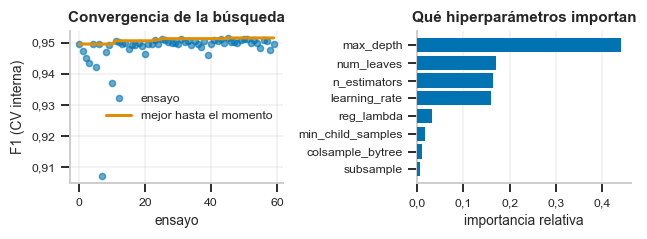

In [54]:
if GENERAR_FIGURAS and len(historia):
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.38))
    axes[0].plot(historia['ensayo'], historia['f1'], 'o', ms=4, color=C_A,
                 alpha=0.6, label='ensayo')
    axes[0].plot(historia['ensayo'], historia['f1'].cummax(), color=C_B, lw=2,
                 label='mejor hasta el momento')
    axes[0].set_xlabel('ensayo'); axes[0].set_ylabel('F1 (CV interna)')
    axes[0].set_title('Convergencia de la búsqueda'); axes[0].legend()
    imp = estudio['importancia_parametros']
    if imp:
        nombres = list(imp)[::-1]
        axes[1].barh(nombres, [imp[n] for n in nombres], color=C_A, zorder=3)
        axes[1].set_xlabel('importancia relativa')
    axes[1].set_title('Qué hiperparámetros importan')
    axes[1].grid(axis='y', visible=False)
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    figura(fig, 'b7_optuna', exportar='opt_optuna_history')
    plt.show()

## 7.2. ¿Compensa un ensamblado? Contraste estadístico

Queda una pregunta abierta desde el bloque 6: ordenar por F1 no basta para
saber si las diferencias entre los primeros son **reales** o ruido de
partición. Y una segunda: ¿mejoraría un ensamblado al mejor modelo
individual? Se comparan **Voting (soft)** y **Stacking** contra el modelo
final ya ajustado, que es la comparación que importa.

El contraste sigue el protocolo de Demšar (2006): **Friedman** como test
ómnibus sobre los pliegues emparejados y, si resulta significativo,
comparaciones por pares (Wilcoxon) con **corrección de Holm** para no inflar
el error de tipo I al hacer varias comparaciones. Como el stacking reajusta
varios modelos, se usa validación cruzada **repetida** (5×3) sobre una
submuestra estratificada.

In [55]:
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

def lgbm(**extra):
    return LGBMClassifier(n_jobs=-1, random_state=SEMILLA, verbose=-1, **extra)

def xgb():
    return XGBClassifier(n_estimators=300, tree_method='hist', n_jobs=-1,
                         random_state=SEMILLA, eval_metric='logloss')

def rf():
    return RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEMILLA)

def catboost():
    return CatBoostClassifier(iterations=500 if MODO == 'completo' else 100,
                              random_seed=SEMILLA, verbose=0, thread_count=-1,
                              allow_writing_files=False)

def _ensembles():
    X_e, y_e = submuestrear(train_arbol[VARIABLES_FINALES],
                            train_arbol[DIANA], N_SUB_ENSEMBLE)
    base = [('lgbm', construir_final()), ('xgb', xgb()), ('rf', rf())]
    modelos = {
        f'{MODELO_FINAL}(ajustado)': construir_final(),
        'XGBoost': xgb(),
        'RandomForest': rf(),
        'CatBoost': catboost(),
        'Voting(soft)': VotingClassifier(base, voting='soft', n_jobs=-1),
        'Stacking': StackingClassifier(
            base, final_estimator=LogisticRegression(max_iter=1000), cv=3, n_jobs=-1),
    }
    particion = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPETICIONES,
                                        random_state=SEMILLA)
    pliegues, filas = {}, []
    for nombre, modelo in modelos.items():
        t0 = time.perf_counter()
        s = cross_val_score(modelo, X_e, y_e, scoring='f1', cv=particion, n_jobs=-1)
        pliegues[nombre] = s.tolist()
        filas.append({'modelo': nombre, 'f1_mean': round(float(s.mean()), 4),
                      'f1_std': round(float(s.std()), 4),
                      'tiempo_s': round(time.perf_counter() - t0, 1)})
        print(f"  {nombre:16s} F1={s.mean():.4f} ± {s.std():.4f}  "
              f"({filas[-1]['tiempo_s']}s)")
    return {'tabla': filas, 'pliegues': pliegues}

ensembles = punto('ensembles', _ensembles)
tabla_ensembles = pd.DataFrame(ensembles['tabla']).sort_values(
    'f1_mean', ascending=False).reset_index(drop=True)
pliegues = {k: np.array(v) for k, v in ensembles['pliegues'].items()}
print()
tabla(tabla_ensembles, 'modelos_ensembles')

  [checkpoint] «ensembles» cargado de ensembles.json

            modelo  f1_mean  f1_std  tiempo_s
      Voting(soft)   0.9526  0.0032      20.3
LightGBM(ajustado)   0.9521  0.0032      13.4
          Stacking   0.9510  0.0035      85.9
           XGBoost   0.9503  0.0036       1.9
          CatBoost   0.9483  0.0030      16.5
      RandomForest   0.9471  0.0038       5.9


,modelo,f1_mean,f1_std,tiempo_s
0,Voting(soft),0.9526,0.0032,20.3
1,LightGBM(ajustado),0.9521,0.0032,13.4
2,Stacking,0.9510,0.0035,85.9
3,XGBoost,0.9503,0.0036,1.9
4,CatBoost,0.9483,0.0030,16.5
5,RandomForest,0.9471,0.0038,5.9


In [56]:
chi2, p_friedman = friedmanchisquare(*[pliegues[m] for m in pliegues])
print(f'Test de Friedman: chi² = {chi2:.3f}, p = {p_friedman:.4g}')
print('  -> ' + ('hay diferencias significativas entre los modelos.'
                if p_friedman < 0.05 else
                'no se detectan diferencias significativas.'))

lider = tabla_ensembles.iloc[0]['modelo']
comparaciones = []
for modelo in [m for m in pliegues if m != lider]:
    if np.allclose(pliegues[lider], pliegues[modelo]):
        p = 1.0
    else:
        _, p = wilcoxon(pliegues[lider], pliegues[modelo])
    comparaciones.append([modelo,
                          float(pliegues[lider].mean() - pliegues[modelo].mean()), p])
# Corrección de Holm: se ordenan los p-valores y se ajustan secuencialmente.
comparaciones.sort(key=lambda r: r[2])
k = len(comparaciones)
holm = [{'frente_a': m, 'dif_F1': round(dif, 4), 'p': round(p, 4),
         'p_holm': round(min(1.0, p * (k - i)), 4),
         'significativo': 'sí' if min(1.0, p * (k - i)) < 0.05 else 'no'}
        for i, (m, dif, p) in enumerate(comparaciones)]
print(f'\nComparaciones por pares frente a {lider} (Wilcoxon + Holm):')
tabla(pd.DataFrame(holm), 'modelos_posthoc_holm')

Test de Friedman: chi² = 46.431, p = 7.419e-09
  -> hay diferencias significativas entre los modelos.

Comparaciones por pares frente a Voting(soft) (Wilcoxon + Holm):
          frente_a  dif_F1      p  p_holm significativo
      RandomForest  0.0055 0.0001  0.0003            sí
          CatBoost  0.0043 0.0001  0.0002            sí
           XGBoost  0.0024 0.0002  0.0005            sí
          Stacking  0.0017 0.0054  0.0107            sí
LightGBM(ajustado)  0.0005 0.1688  0.1688            no


,frente_a,dif_F1,p,p_holm,significativo
0,RandomForest,0.0055,0.0001,0.0003,sí
1,CatBoost,0.0043,0.0001,0.0002,sí
2,XGBoost,0.0024,0.0002,0.0005,sí
3,Stacking,0.0017,0.0054,0.0107,sí
4,LightGBM(ajustado),0.0005,0.1688,0.1688,no


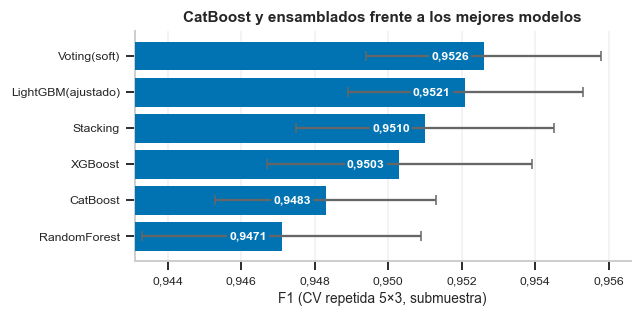

In [57]:
if GENERAR_FIGURAS:
    d = tabla_ensembles.sort_values('f1_mean')
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.50))
    ax.barh(d['modelo'], d['f1_mean'], xerr=d['f1_std'], color=C_A,
            zorder=3, error_kw={'ecolor': '0.4', 'capsize': 3})
    # El rotulo va DENTRO de la barra: a la derecha del extremo pasa la
    # barra de error, y la linea cruzaba los numeros.
    for y, v in zip(range(len(d)), d['f1_mean']):
        ax.text(v - 0.0004, y, f'{v:.4f}'.replace('.', ','), va='center',
                ha='right', fontsize=8, color='white', fontweight='bold',
                zorder=5,
                bbox=dict(facecolor=C_A, edgecolor='none', pad=1.4))
    ax.set_xlabel('F1 (CV repetida 5×%d, submuestra)' % N_REPETICIONES)
    ax.set_title('CatBoost y ensamblados frente a los mejores modelos')
    ax.set_xlim(d['f1_mean'].min() - 0.004, d['f1_mean'].max() + 0.004)
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    coma(ax, 'x')
    fig.tight_layout()
    figura(fig, 'b6_contraste_estadistico', exportar='models_stat_test')
    plt.show()

## 7.3. Validación cruzada anidada

Aquí está el punto delicado del método. Si se eligen los hiperparámetros con
una validación cruzada y se reporta el resultado de **esa misma**
validación, la cifra es optimista: se ha usado el conjunto de validación
para decidir.

La **CV anidada** resuelve el problema: el bucle interno busca
hiperparámetros, el externo mide, y ningún dato hace las dos cosas a la vez.
La diferencia entre ambas estimaciones es el **sesgo optimista real**.

In [58]:
def _cv_anidada():
    distribuciones = {
        'XGBoost': {'n_estimators': randint(100, 600), 'max_depth': randint(3, 10),
                    'learning_rate': loguniform(0.01, 0.3),
                    'subsample': uniform(0.6, 0.4),
                    'colsample_bytree': uniform(0.6, 0.4),
                    'reg_lambda': loguniform(1e-3, 10)},
        'LightGBM': {'n_estimators': randint(100, 600), 'num_leaves': randint(15, 127),
                     'max_depth': randint(3, 12), 'learning_rate': loguniform(0.01, 0.3),
                     'subsample': uniform(0.6, 0.4),
                     'colsample_bytree': uniform(0.6, 0.4),
                     'reg_lambda': loguniform(1e-3, 10),
                     'min_child_samples': randint(5, 100)},
        'RandomForest': {'n_estimators': randint(100, 400), 'max_depth': randint(5, 30),
                         'max_features': uniform(0.2, 0.8),
                         'min_samples_split': randint(2, 20),
                         'min_samples_leaf': randint(1, 10)},
    }[MODELO_FINAL]
    fabrica, _ = FABRICAS[MODELO_FINAL]
    busqueda = RandomizedSearchCV(
        fabrica({}), distribuciones, n_iter=10 if MODO == 'completo' else 3,
        scoring='f1', cv=cv(n_splits=3), random_state=SEMILLA, n_jobs=-1)
    t0 = time.perf_counter()
    puntuaciones = cross_val_score(busqueda, X_opt, y_opt, scoring='f1',
                                   cv=cv(n_splits=CV_FOLDS), n_jobs=1)
    return {'f1_por_pliegue': puntuaciones.tolist(),
            'f1_anidada_media': round(float(puntuaciones.mean()), 4),
            'f1_anidada_desv': round(float(puntuaciones.std()), 4),
            'f1_no_anidada': FICHA_MODELO['f1_cv5_train'],
            'sesgo_optimista': round(
                float(FICHA_MODELO['f1_cv5_train'] - puntuaciones.mean()), 4),
            'segundos': round(time.perf_counter() - t0, 1)}

cv_anidada = punto('cv_anidada', _cv_anidada)
print(f"F1 por pliegue externo : "
      f"{np.round(cv_anidada['f1_por_pliegue'], 4)}")
print(f"F1 anidada (insesgada) : {cv_anidada['f1_anidada_media']} "
      f"± {cv_anidada['f1_anidada_desv']}")
print(f"F1 no anidada (7)      : {cv_anidada['f1_no_anidada']}")
print(f"Sesgo optimista real   : {cv_anidada['sesgo_optimista']}")
registrar('7_optimizacion', 'cv_anidada', MODELO_FINAL,
          {'f1_anidada': cv_anidada['f1_anidada_media']},
          datos='v06_seleccionado_arbol')

  [checkpoint] «cv_anidada» cargado de cv_anidada.json
F1 por pliegue externo : [0.9608 0.9599 0.9603 0.9638 0.9591]
F1 anidada (insesgada) : 0.9608 ± 0.0016
F1 no anidada (7)      : 0.9608
Sesgo optimista real   : 0.0


## 7.4. ¿Sigue siendo buena la selección de variables?

La selección del bloque 3 se decidió con **regresión logística**, sensible a
la multicolinealidad. El modelo final es un **ensamblado de árboles**,
robusto a la redundancia: puede ignorar variables redundantes sin
penalización, así que su representación óptima podría ser otra.

Se reevalúan las representaciones con el modelo final ya ajustado, usando
validación cruzada repetida (para tener pliegues emparejados suficientes) y
un contraste de **Wilcoxon**, que no asume normalidad. La regla se fija de
antemano: solo se cambia de representación si la mejora es
**significativa** (p < 0,05) **y** además supera un margen práctico de 0,002
en F1. Diferencias por debajo de eso no justifican perder parsimonia.

In [59]:
def _reevaluar_representacion():
    representaciones = {
        'full': VARIABLES_IMP,
        'variance': filtro['varianza'],
        'filter_corr': filtro['filter_corr'],
        'embedded_tree': otros['embedded_tree'],
    }
    # La representación elegida en el bloque 3 siempre entra en la comparación.
    representaciones[SUBCONJUNTO_FINAL] = list(VARIABLES_FINALES)
    # Selección basada en el propio modelo final.
    sfm = SelectFromModel(construir_final(), threshold='median').fit(
        train_imp[VARIABLES_IMP], train_imp[DIANA])
    representaciones['modelo_final_sfm'] = [
        f for f, k in zip(VARIABLES_IMP, sfm.get_support()) if k]

    particion = RepeatedStratifiedKFold(n_splits=5, n_repeats=N_REPETICIONES,
                                        random_state=SEMILLA)
    pliegues, filas = {}, []
    for nombre, variables in representaciones.items():
        t0 = time.perf_counter()
        s = cross_val_score(construir_final(), train_imp[variables],
                            train_imp[DIANA], scoring='f1', cv=particion, n_jobs=-1)
        pliegues[nombre] = s.tolist()
        filas.append({'representacion': nombre, 'n_variables': len(variables),
                      'f1_mean': round(float(s.mean()), 4),
                      'f1_std': round(float(s.std()), 4),
                      'tiempo_s': round(time.perf_counter() - t0, 1)})
        print(f"  {nombre:18s} n={len(variables):3d}  "
              f"F1={s.mean():.4f} ± {s.std():.4f}")
    return {'tabla': filas, 'pliegues': pliegues}

reevaluacion = punto('reevaluacion_variables', _reevaluar_representacion)
tabla_reev = pd.DataFrame(reevaluacion['tabla']).sort_values(
    'f1_mean', ascending=False).reset_index(drop=True)
pliegues_reev = {k: np.array(v) for k, v in reevaluacion['pliegues'].items()}
print()
tabla(tabla_reev, 'seleccion_reevaluacion_modelo_final')

  [checkpoint] «reevaluacion_variables» cargado de reevaluacion_variables.json

  representacion  n_variables  f1_mean  f1_std  tiempo_s
        variance          109   0.9613  0.0013      18.8
     filter_corr           54   0.9611  0.0018      14.8
            full          177   0.9608  0.0015      21.8
modelo_final_sfm          177   0.9608  0.0015      19.3
   embedded_tree           55   0.9594  0.0019      16.2


,representacion,n_variables,f1_mean,f1_std,tiempo_s
0,variance,109,0.9613,0.0013,18.8
1,filter_corr,54,0.9611,0.0018,14.8
2,full,177,0.9608,0.0015,21.8
3,modelo_final_sfm,177,0.9608,0.0015,19.3
4,embedded_tree,55,0.9594,0.0019,16.2


In [60]:
MARGEN_PRACTICO = 0.002
mejor_rep = tabla_reev.iloc[0]['representacion']
f1_mejor = float(tabla_reev.iloc[0]['f1_mean'])
f1_actual = float(tabla_reev.loc[tabla_reev['representacion'] == SUBCONJUNTO_FINAL,
                                 'f1_mean'].iloc[0])

if mejor_rep == SUBCONJUNTO_FINAL or np.allclose(pliegues_reev[mejor_rep],
                                                 pliegues_reev[SUBCONJUNTO_FINAL]):
    p_valor = 1.0
else:
    _, p_valor = wilcoxon(pliegues_reev[mejor_rep], pliegues_reev[SUBCONJUNTO_FINAL])
ganancia = f1_mejor - f1_actual
cambiar = bool(mejor_rep != SUBCONJUNTO_FINAL and p_valor < 0.05
               and ganancia >= MARGEN_PRACTICO)

decision_variables = {
    'mejor_representacion': mejor_rep,
    'f1_mejor': round(f1_mejor, 4),
    'f1_seleccion_actual': round(f1_actual, 4),
    'ganancia': round(float(ganancia), 4),
    'p_wilcoxon': round(float(p_valor), 4),
    'cambiar_representacion': cambiar,
    'representacion_definitiva': mejor_rep if cambiar else SUBCONJUNTO_FINAL,
}
punto('decision_variables', lambda: decision_variables)
print(json.dumps(decision_variables, indent=2, ensure_ascii=False))
print()
if cambiar:
    print(f'>>> Conviene cambiar a {mejor_rep}: la mejora es significativa '
          f'y supera el margen práctico.')
else:
    print(f'>>> Se CONFIRMA {SUBCONJUNTO_FINAL} ({len(VARIABLES_FINALES)} '
          'variables): ninguna alternativa mejora de forma significativa y')
    print('    con margen práctico. Gana la parsimonia.')

  [checkpoint] «decision_variables» cargado de decision_variables.json
{
  "mejor_representacion": "variance",
  "f1_mejor": 0.9613,
  "f1_seleccion_actual": 0.9611,
  "ganancia": 0.0002,
  "p_wilcoxon": 0.6788,
  "cambiar_representacion": false,
  "representacion_definitiva": "filter_corr"
}

>>> Se CONFIRMA filter_corr (54 variables): ninguna alternativa mejora de forma significativa y
    con margen práctico. Gana la parsimonia.


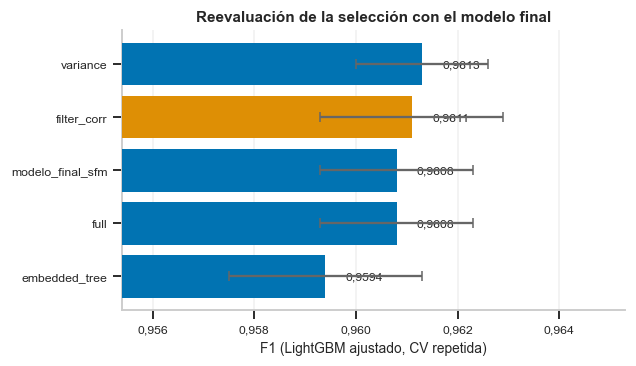

In [61]:
if GENERAR_FIGURAS:
    d = tabla_reev.sort_values('f1_mean')
    colores = [C_B if r == SUBCONJUNTO_FINAL else C_A for r in d['representacion']]
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.56))
    ax.barh(d['representacion'], d['f1_mean'], xerr=d['f1_std'], color=colores,
            zorder=3, error_kw={'ecolor': '0.4', 'capsize': 3})
    for y, v in zip(range(len(d)), d['f1_mean']):
        ax.text(v + 0.0004, y, f'{v:.4f}'.replace('.', ','),
                va='center', fontsize=8)
    ax.set_xlabel(f'F1 ({MODELO_FINAL} ajustado, CV repetida)')
    ax.set_title('Reevaluación de la selección con el modelo final')
    ax.set_xlim(d['f1_mean'].min() - 0.004, d['f1_mean'].max() + 0.004)
    ax.grid(axis='y', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b7_reevaluacion_variables', exportar='fs_tree_reeval')
    plt.show()

## 7.5. Balanceo y umbral en el modelo final

Queda la otra verificación pendiente: el bloque 5 descartó el balanceo con
regresión logística. Los ensamblados de árboles tienen su propio mecanismo
(`scale_pos_weight`, `is_unbalance`), equivalente a ponderar la clase
positiva en la función de pérdida. Se comprueba.

Y, sobre todo, se estudia el **umbral de decisión**. Por defecto se
clasifica como phishing si la probabilidad supera 0,5, pero ese valor no
tiene nada de especial: moverlo desplaza el compromiso precisión–recall **sin reentrenar nada**. El umbral se elige con predicciones
*out-of-fold* del entrenamiento, nunca con el test.

In [62]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_predict

n_neg = int((y_opt == 0).sum())
n_pos = int((y_opt == 1).sum())
PESO_POSITIVA = n_neg / n_pos

def _balanceo_final():
    esquemas = {'sin_balanceo': construir_final()}
    if MODELO_FINAL == 'LightGBM':
        esquemas['scale_pos_weight'] = construir_final(scale_pos_weight=PESO_POSITIVA)
        esquemas['is_unbalance'] = construir_final(is_unbalance=True)
    elif MODELO_FINAL == 'XGBoost':
        esquemas['scale_pos_weight'] = construir_final(scale_pos_weight=PESO_POSITIVA)
    else:
        esquemas['class_weight_balanced'] = construir_final(class_weight='balanced')
    filas = []
    for nombre, modelo in esquemas.items():
        res = evaluar(modelo, X_opt, y_opt)
        res['esquema'] = nombre
        filas.append(res)
        print(f"  {nombre:20s} F1={res['f1_mean']:.4f}  "
              f"recall={res['recall_mean']:.4f}  MCC={res['mcc_mean']:.4f}")
    # Probabilidades out-of-fold para el análisis de umbral.
    proba_oof = cross_val_predict(construir_final(), X_opt, y_opt,
                                  cv=cv(n_splits=CV_FOLDS),
                                  method='predict_proba', n_jobs=-1)[:, 1]
    return {'tabla': pd.DataFrame(filas), 'proba_oof': proba_oof}

balanceo_final = punto('balanceo_modelo_final', _balanceo_final)
tabla_balanceo_final = balanceo_final['tabla']
proba_oof = np.asarray(balanceo_final['proba_oof'])
print(f'\nscale_pos_weight teórico: {PESO_POSITIVA:.3f}\n')
tabla(tabla_balanceo_final[['esquema', 'f1_mean', 'recall_mean', 'precision_mean',
                            'average_precision_mean', 'mcc_mean']].round(4),
      'balanceo_modelo_final')

  [checkpoint] «balanceo_modelo_final» cargado de balanceo_modelo_final.joblib

scale_pos_weight teórico: 1.860

         esquema  f1_mean  recall_mean  precision_mean  average_precision_mean  mcc_mean
    sin_balanceo   0.9608       0.9616          0.9601                  0.9927    0.9398
scale_pos_weight   0.9602       0.9667          0.9537                  0.9927    0.9386
    is_unbalance   0.9606       0.9670          0.9542                  0.9927    0.9392


,esquema,f1_mean,recall_mean,precision_mean,average_precision_mean,mcc_mean
0,sin_balanceo,0.9608,0.9616,0.9601,0.9927,0.9398
1,scale_pos_weight,0.9602,0.9667,0.9537,0.9927,0.9386
2,is_unbalance,0.9606,0.9670,0.9542,0.9927,0.9392


In [63]:
precision_oof, recall_oof, umbrales = precision_recall_curve(y_opt, proba_oof)
f1_oof = (2 * precision_oof[:-1] * recall_oof[:-1] /
          (precision_oof[:-1] + recall_oof[:-1] + 1e-12))
UMBRAL_F1 = float(umbrales[int(np.argmax(f1_oof))])
objetivo_recall = recall_oof[:-1] >= 0.97
UMBRAL_RECALL = (float(umbrales[np.where(objetivo_recall)[0].max()])
                 if objetivo_recall.any() else 0.0)

def metricas_en(umbral):
    pred = (proba_oof >= umbral).astype(int)
    return {'precision': precision_score(y_opt, pred, zero_division=0),
            'recall': recall_score(y_opt, pred, zero_division=0),
            'f1': f1_score(y_opt, pred, zero_division=0),
            'mcc': matthews_corrcoef(y_opt, pred)}

puntos_operacion = pd.DataFrame([
    {'umbral': etiqueta, **{k: round(v, 4) for k, v in metricas_en(u).items()}}
    for etiqueta, u in [('0,50 (por defecto)', 0.5),
                        (f'{UMBRAL_F1:.3f} (F1 máximo)', UMBRAL_F1),
                        (f'{UMBRAL_RECALL:.3f} (recall ≥ 0,97)', UMBRAL_RECALL)]])
print('Puntos de operación (métricas out-of-fold sobre el entrenamiento):')
tabla(puntos_operacion, 'umbral_puntos_operacion')

Puntos de operación (métricas out-of-fold sobre el entrenamiento):
               umbral  precision  recall     f1    mcc
   0,50 (por defecto)     0.9601  0.9616 0.9608 0.9398
    0.416 (F1 máximo)     0.9548  0.9675 0.9611 0.9401
0.369 (recall ≥ 0,97)     0.9503  0.9700 0.9601 0.9384


,umbral,precision,recall,f1,mcc
0,"0,50 (por defecto)",0.9601,0.9616,0.9608,0.9398
1,0.416 (F1 máximo),0.9548,0.9675,0.9611,0.9401
2,"0.369 (recall ≥ 0,97)",0.9503,0.9700,0.9601,0.9384


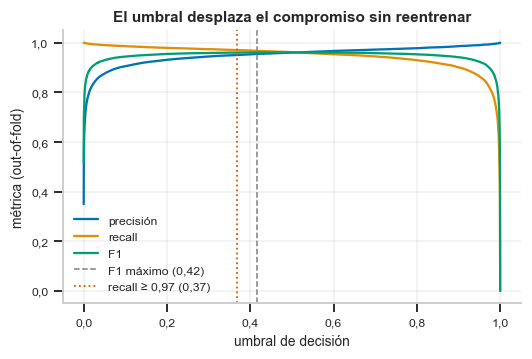

In [64]:
if GENERAR_FIGURAS:
    fig, ax = plt.subplots(figsize=ancho(0.91, 0.60))
    ax.plot(umbrales, precision_oof[:-1], color=C_A, label='precisión')
    ax.plot(umbrales, recall_oof[:-1], color=C_B, label='recall')
    ax.plot(umbrales, f1_oof, color=C_C, label='F1')
    ax.axvline(UMBRAL_F1, ls='--', color='0.5', lw=1,
               label=f'F1 máximo ({UMBRAL_F1:.2f})')
    ax.axvline(UMBRAL_RECALL, ls=':', color=C_NEG, lw=1.2,
               label=f'recall ≥ 0,97 ({UMBRAL_RECALL:.2f})')
    ax.set_xlabel('umbral de decisión'); ax.set_ylabel('métrica (out-of-fold)')
    ax.set_title('El umbral desplaza el compromiso sin reentrenar')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b7_umbral', exportar='bal_final_threshold')
    plt.show()

### Recomendación de operación

Mantener el modelo **sin balanceo** —da el mejor F1 y MCC— y elegir el
**umbral** según el coste que se asuma para un falso negativo. Bajarlo
aumenta la detección de phishing a costa de bloquear más sitios legítimos;
la tabla anterior cuantifica exactamente ese intercambio, que es una
decisión de negocio, no estadística.

---

# Bloque 8 — Evaluación sobre el conjunto de prueba reservado

Llega el momento de abrir el sobre. El conjunto de prueba se apartó en el
bloque 2 y **no ha intervenido en nada**: ni en la imputación, ni en el
escalado, ni en la selección de variables, ni en el balanceo, ni en la
optimización. Es la estimación definitiva e imparcial del rendimiento sobre
datos no vistos.

> **Regla de oro:** el test se usa **una sola vez**, aquí, y ninguna
> decisión de modelado sale de mirarlo.

Se reportan varias métricas porque ninguna cuenta la historia entera, y
cada una responde a una pregunta distinta:

- **Recall**: de todo el phishing que hay, ¿cuánto detecto? Un falso
  negativo es un ataque que pasa.
- **Precisión**: de todo lo que marco, ¿cuánto es phishing de verdad? Un
  falso positivo es un sitio legítimo bloqueado.
- **F1** y **MCC**: el equilibrio entre ambas.
- **ROC-AUC** y **PR-AUC**: capacidad de ordenar, independiente del umbral.
- **Brier score**: si las probabilidades son fiables o solo ordenan bien.

Todas con **intervalos de confianza bootstrap al 95 %**: una cifra sin su
incertidumbre invita a sobreinterpretar diferencias que no existen.

In [65]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (brier_score_loss, confusion_matrix, log_loss,
                             roc_curve)

X_test, y_test = test_arbol[VARIABLES_FINALES], test_arbol[DIANA]

def _evaluar_test():
    modelo = construir_final()
    modelo.fit(X_opt, y_opt)
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]
    return {'pred': pred, 'proba': proba}

predicciones = punto('predicciones_test', _evaluar_test)
y_pred = np.asarray(predicciones['pred'])
y_proba = np.asarray(predicciones['proba'])

def calcular_metricas(reales, pred, proba):
    vn, fp, fn, vp = confusion_matrix(reales, pred).ravel()
    return {
        'accuracy': accuracy_score(reales, pred),
        'balanced_accuracy': balanced_accuracy_score(reales, pred),
        'precision': precision_score(reales, pred, zero_division=0),
        'recall': recall_score(reales, pred, zero_division=0),
        'especificidad': vn / (vn + fp),
        'f1': f1_score(reales, pred, zero_division=0),
        'mcc': matthews_corrcoef(reales, pred),
        'roc_auc': roc_auc_score(reales, proba),
        'pr_auc': average_precision_score(reales, proba),
        'brier': brier_score_loss(reales, proba),
    }

def _metricas_con_ic():
    puntual = calcular_metricas(y_test.values, y_pred, y_proba)
    rng = np.random.default_rng(SEMILLA)
    n_remuestreos = 1000 if MODO == 'completo' else 100
    n = len(y_test)
    acumulado = {k: [] for k in puntual}
    for _ in range(n_remuestreos):
        idx = rng.integers(0, n, n)
        for k, v in calcular_metricas(y_test.values[idx], y_pred[idx],
                                      y_proba[idx]).items():
            acumulado[k].append(v)
    filas = []
    for k, v in puntual.items():
        inf, sup = np.percentile(acumulado[k], [2.5, 97.5])
        filas.append({'metrica': k, 'valor': round(v, 4),
                      'ic95_inf': round(inf, 4), 'ic95_sup': round(sup, 4)})
    return pd.DataFrame(filas)

metricas_test = punto('evaluacion', _metricas_con_ic)
METRICAS_TEST = dict(zip(metricas_test['metrica'], metricas_test['valor']))
registrar('8_evaluacion', 'test_reservado', MODELO_FINAL, METRICAS_TEST,
          PARAMS_FINALES, datos='test reservado')
print(f'Modelo evaluado: {MODELO_FINAL} ajustado')
print(f'Test reservado : {X_test.shape[0]:,} × {X_test.shape[1]}\n')
tabla(metricas_test, 'evaluacion_metricas_test')

  [checkpoint] «predicciones_test» cargado de predicciones_test.joblib
  [checkpoint] «evaluacion» cargado de evaluacion.parquet
Modelo evaluado: LightGBM ajustado
Test reservado : 17,440 × 54

          metrica  valor  ic95_inf  ic95_sup
         accuracy 0.9732    0.9708    0.9755
balanced_accuracy 0.9705    0.9678    0.9732
        precision 0.9615    0.9566    0.9663
           recall 0.9618    0.9571    0.9663
    especificidad 0.9793    0.9767    0.9819
               f1 0.9616    0.9582    0.9650
              mcc 0.9410    0.9357    0.9459
          roc_auc 0.9956    0.9948    0.9962
           pr_auc 0.9924    0.9911    0.9934
            brier 0.0207    0.0190    0.0224


,metrica,valor,ic95_inf,ic95_sup
0,accuracy,0.9732,0.9708,0.9755
1,balanced_accuracy,0.9705,0.9678,0.9732
2,precision,0.9615,0.9566,0.9663
3,recall,0.9618,0.9571,0.9663
4,especificidad,0.9793,0.9767,0.9819
5,f1,0.9616,0.9582,0.9650
6,mcc,0.9410,0.9357,0.9459
7,roc_auc,0.9956,0.9948,0.9962
8,pr_auc,0.9924,0.9911,0.9934
9,brier,0.0207,0.0190,0.0224


## 8.1. Matriz de confusión

Los agregados esconden el detalle que importa en ciberseguridad: **cuántos
ataques se escapan** y **cuántos sitios legítimos se bloquean**.

In [66]:
mc = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = mc.ravel()
tabla(pd.DataFrame(mc, index=['real legítimo', 'real phishing'],
                   columns=['pred. legítimo', 'pred. phishing'])
      .reset_index(names='clase'), 'evaluacion_matriz_confusion')
print(f'\nVerdaderos negativos : {vn:,}')
print(f'Falsos positivos     : {fp:,}  -> legitimos bloqueados '
      f'({fp / (fp + vn) * 100:.2f}% de los legítimos)')
print(f'Falsos negativos     : {fn:,}  -> phishing no detectado '
      f'({fn / (fn + vp) * 100:.2f}% del phishing)')
print(f'Verdaderos positivos : {vp:,}')

        clase  pred. legítimo  pred. phishing
real legítimo           11107             235
real phishing             233            5865

Verdaderos negativos : 11,107
Falsos positivos     : 235  -> legitimos bloqueados (2.07% de los legítimos)
Falsos negativos     : 233  -> phishing no detectado (3.82% del phishing)
Verdaderos positivos : 5,865


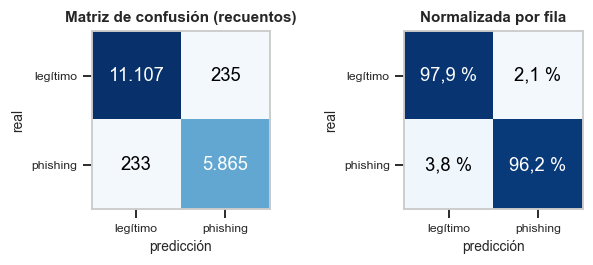

In [67]:
if GENERAR_FIGURAS:
    mc_norm = mc / mc.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.42))
    for ax, datos, titulo, fmt in [
            (axes[0], mc, 'Matriz de confusión (recuentos)', '{:,}'),
            (axes[1], mc_norm, 'Normalizada por fila', '{:.1%}')]:
        im = ax.imshow(datos, cmap='Blues',
                       vmin=0, vmax=1 if datos is mc_norm else None)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['legítimo', 'phishing'])
        ax.set_yticks([0, 1]); ax.set_yticklabels(['legítimo', 'phishing'])
        ax.set_xlabel('predicción'); ax.set_ylabel('real'); ax.set_title(titulo)
        umbral_color = datos.max() / 2
        for i in range(2):
            for j in range(2):
                # Notacion espanola: punto para los millares (11.107) y
                # coma para los decimales (97,9 %), como en el texto.
                if fmt == '{:,}':
                    etq = f'{datos[i, j]:,}'.replace(',', '.')
                else:
                    etq = (f'{datos[i, j]:.1%}'.replace('.', ',')
                           .replace('%', ' %'))
                ax.text(j, i, etq, ha='center', va='center',
                        color='white' if datos[i, j] > umbral_color else 'black',
                        fontsize=12)
        ax.grid(False)
    fig.tight_layout()
    figura(fig, 'b8_matriz_confusion', exportar='eval_confusion')
    plt.show()

## 8.2. Curvas ROC y precisión-recall

La ROC mide la capacidad de ordenar con independencia del umbral. La curva
PR es más informativa con clases desbalanceadas, porque su línea base es la
prevalencia de la clase positiva y no el 0,5 de la diagonal ROC (Saito &
Rehmsmeier, 2015).

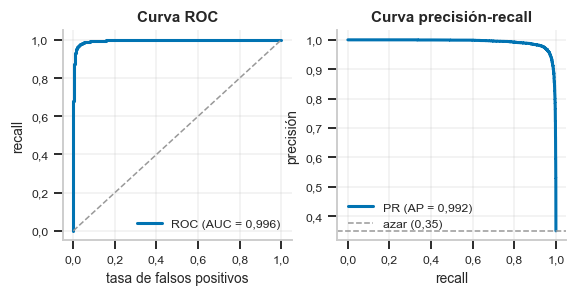

In [68]:
if GENERAR_FIGURAS:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.42))
    axes[0].plot(fpr, tpr, color=C_A, lw=2,
                 label=f"ROC (AUC = {METRICAS_TEST['roc_auc']:.3f})")
    axes[0].plot([0, 1], [0, 1], '--', color='0.6', lw=1)
    axes[0].set_xlabel('tasa de falsos positivos')
    axes[0].set_ylabel('recall')
    axes[0].set_title('Curva ROC'); axes[0].legend(loc='lower right')
    base = float(y_test.mean())
    axes[1].plot(rec, prec, color=C_A, lw=2,
                 label=f"PR (AP = {METRICAS_TEST['pr_auc']:.3f})")
    axes[1].axhline(base, ls='--', color='0.6', lw=1, label=f'azar ({base:.2f})')
    axes[1].set_xlabel('recall'); axes[1].set_ylabel('precisión')
    axes[1].set_title('Curva precisión-recall')
    axes[1].legend(loc='lower left')
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b8_roc_pr', exportar='eval_roc_pr')
    plt.show()

## 8.3. Calibración: ¿son fiables las probabilidades?

Un modelo puede ordenar perfectamente y aun así dar probabilidades
engañosas. Está **bien calibrado** si de los casos a los que asigna 0,8, el
80 % resultan ser phishing. Importa cuando la probabilidad alimenta una
decisión (avisar, bloquear, escalar a revisión humana).

Se compara el modelo base con dos recalibraciones ajustadas por validación
cruzada sobre el entrenamiento: **Platt** (sigmoide) e **isotónica**
(Niculescu-Mizil & Caruana, 2005). El **Brier score** decide, y menor es
mejor.

In [69]:
def _calibracion():
    base = construir_final().fit(X_opt, y_opt)
    cal_sig = CalibratedClassifierCV(base, method='sigmoid', cv=CV_FOLDS).fit(X_opt, y_opt)
    cal_iso = CalibratedClassifierCV(base, method='isotonic', cv=CV_FOLDS).fit(X_opt, y_opt)
    probas = {'sin calibrar': y_proba,
              'Platt (sigmoide)': cal_sig.predict_proba(X_test)[:, 1],
              'isotónica': cal_iso.predict_proba(X_test)[:, 1]}
    filas = [{'variante': k, 'brier': round(brier_score_loss(y_test, p), 5),
              'log_loss': round(log_loss(y_test, p), 5)} for k, p in probas.items()]
    return {'tabla': filas, 'probas': {k: v.tolist() for k, v in probas.items()}}

calibracion = punto('calibracion', _calibracion)
probas_calibradas = {k: np.array(v) for k, v in calibracion['probas'].items()}
tabla(pd.DataFrame(calibracion['tabla']), 'evaluacion_calibracion')

  [checkpoint] «calibracion» cargado de calibracion.json
        variante   brier  log_loss
    sin calibrar 0.02068   0.07769
Platt (sigmoide) 0.02136   0.08797
       isotónica 0.02044   0.07543


,variante,brier,log_loss
0,sin calibrar,0.02068,0.07769
1,Platt (sigmoide),0.02136,0.08797
2,isotónica,0.02044,0.07543


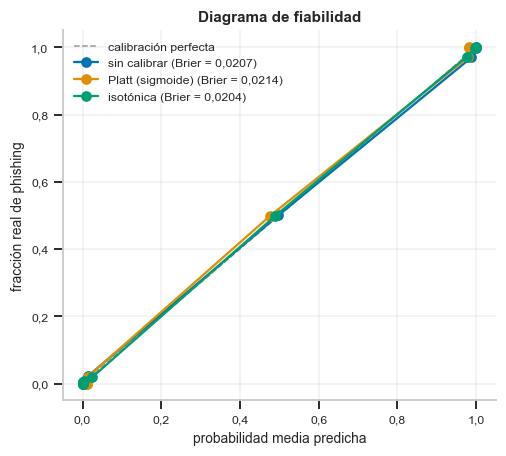

In [70]:
if GENERAR_FIGURAS:
    fig, ax = plt.subplots(figsize=ancho(0.86, 0.86))
    ax.plot([0, 1], [0, 1], '--', color='0.6', lw=1, label='calibración perfecta')
    for (nombre, p), color in zip(probas_calibradas.items(), [C_A, C_B, C_C]):
        frac, media = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
        ax.plot(media, frac, marker='o', color=color,
                label=f'{nombre} (Brier = {brier_score_loss(y_test, p):.4f})')
    ax.set_xlabel('probabilidad media predicha')
    ax.set_ylabel('fracción real de phishing')
    ax.set_title('Diagrama de fiabilidad')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b8_calibracion', exportar='eval_calibration')
    plt.show()

## 8.4. El umbral, ahora sobre el test

El umbral se eligió en el bloque 7 con predicciones *out-of-fold*, sin mirar
el test. Aquí solo se **comprueba** cómo se traduce ese compromiso sobre los
datos reservados.

In [71]:
prec_t, rec_t, umb_t = precision_recall_curve(y_test, y_proba)
f1_t = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-12)
umbral_test_f1 = float(umb_t[int(np.argmax(f1_t))])

filas_umbral = []
for etiqueta, u in [('0,50 (por defecto)', 0.5),
                    (f'{UMBRAL_F1:.3f} (F1 máx. out-of-fold)', UMBRAL_F1),
                    (f'{UMBRAL_RECALL:.3f} (recall ≥ 0,97 OOF)', UMBRAL_RECALL),
                    (f'{umbral_test_f1:.3f} (F1 máx. sobre el test)', umbral_test_f1)]:
    pred_u = (y_proba >= u).astype(int)
    m = calcular_metricas(y_test.values, pred_u, y_proba)
    filas_umbral.append({'umbral': etiqueta,
                         'precision': round(m['precision'], 4),
                         'recall': round(m['recall'], 4),
                         'f1': round(m['f1'], 4), 'mcc': round(m['mcc'], 4)})
tabla(pd.DataFrame(filas_umbral), 'evaluacion_umbral_test')
print('\nLa última fila es descriptiva: ese umbral se ha elegido mirando el')
print('test, así que NO se usa para decidir nada. Se informa solo para')
print('comprobar que el umbral fijado out-of-fold queda muy cerca del óptimo.')

                       umbral  precision  recall     f1    mcc
           0,50 (por defecto)     0.9615  0.9618 0.9616 0.9410
  0.416 (F1 máx. out-of-fold)     0.9563  0.9680 0.9621 0.9416
    0.369 (recall ≥ 0,97 OOF)     0.9536  0.9700 0.9617 0.9409
0.442 (F1 máx. sobre el test)     0.9590  0.9665 0.9628 0.9426

La última fila es descriptiva: ese umbral se ha elegido mirando el
test, así que NO se usa para decidir nada. Se informa solo para
comprobar que el umbral fijado out-of-fold queda muy cerca del óptimo.


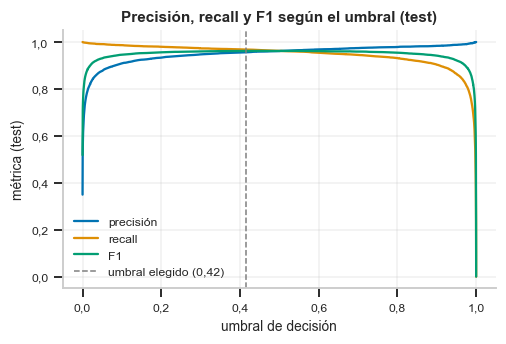

In [72]:
if GENERAR_FIGURAS:
    fig, ax = plt.subplots(figsize=ancho(0.86, 0.60))
    ax.plot(umb_t, prec_t[:-1], color=C_A, label='precisión')
    ax.plot(umb_t, rec_t[:-1], color=C_B, label='recall')
    ax.plot(umb_t, f1_t, color=C_C, label='F1')
    ax.axvline(UMBRAL_F1, ls='--', color='0.5', lw=1,
               label=f'umbral elegido ({UMBRAL_F1:.2f})')
    ax.set_xlabel('umbral de decisión'); ax.set_ylabel('métrica (test)')
    ax.set_title('Precisión, recall y F1 según el umbral (test)')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b8_umbral_test', exportar='eval_threshold')
    plt.show()

## 8.5. Curva de aprendizaje, coste y errores

Tres diagnósticos que completan el retrato del modelo:

- **Curva de aprendizaje**: si el hueco entre entrenamiento y validación es
  pequeño y la curva ha llegado a meseta, no hay sobreajuste y no faltan
  datos.
- **Evaluación sensible al coste**: en phishing, un falso negativo suele
  costar más que un falso positivo. Se calcula el umbral que minimiza el
  coste esperado para varias razones C_FN/C_FP (Elkan, 2001).
- **Análisis de errores**: en qué se parecen los fallos a los aciertos.

In [73]:
from sklearn.model_selection import learning_curve

def _curva_aprendizaje():
    tamanos, tr, va = learning_curve(
        construir_final(), X_opt, y_opt,
        train_sizes=np.linspace(0.1, 1.0, 6 if MODO == 'completo' else 3),
        cv=cv(n_splits=3), scoring='f1', n_jobs=-1)
    return {'tamanos': tamanos.tolist(),
            'f1_train_media': tr.mean(1).tolist(), 'f1_train_desv': tr.std(1).tolist(),
            'f1_val_media': va.mean(1).tolist(), 'f1_val_desv': va.std(1).tolist()}

curva = punto('curva_aprendizaje', _curva_aprendizaje)
tabla(pd.DataFrame({'n_entrenamiento': np.array(curva['tamanos']).astype(int),
                    'f1_train': np.round(curva['f1_train_media'], 4),
                    'f1_validacion': np.round(curva['f1_val_media'], 4)}),
      'evaluacion_curva_aprendizaje')
hueco = curva['f1_train_media'][-1] - curva['f1_val_media'][-1]
print(f'\nHueco final entre train y validación: {hueco:.4f}')
print('Un hueco pequeño y una meseta indican poco sobreajuste y datos suficientes.')

  [checkpoint] «curva_aprendizaje» cargado de curva_aprendizaje.json
 n_entrenamiento  f1_train  f1_validacion
            4650    1.0000         0.9364
           13021    1.0000         0.9478
           21391    1.0000         0.9531
           29762    0.9999         0.9566
           38133    0.9995         0.9584
           46504    0.9989         0.9598

Hueco final entre train y validación: 0.0391
Un hueco pequeño y una meseta indican poco sobreajuste y datos suficientes.


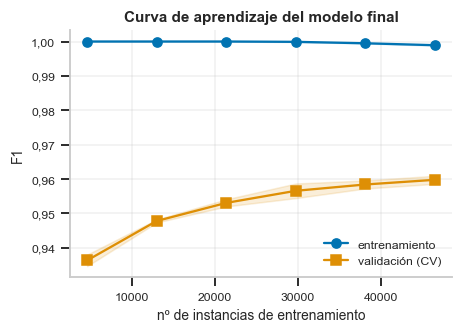

In [74]:
if GENERAR_FIGURAS:
    t = np.array(curva['tamanos'])
    tr_m, tr_s = np.array(curva['f1_train_media']), np.array(curva['f1_train_desv'])
    va_m, va_s = np.array(curva['f1_val_media']), np.array(curva['f1_val_desv'])
    fig, ax = plt.subplots(figsize=ancho(0.76, 0.65))
    ax.plot(t, tr_m, marker='o', color=C_A, label='entrenamiento')
    ax.fill_between(t, tr_m - tr_s, tr_m + tr_s, color=C_A, alpha=0.15)
    ax.plot(t, va_m, marker='s', color=C_B, label='validación (CV)')
    ax.fill_between(t, va_m - va_s, va_m + va_s, color=C_B, alpha=0.15)
    ax.set_xlabel('nº de instancias de entrenamiento'); ax.set_ylabel('F1')
    ax.set_title('Curva de aprendizaje del modelo final'); ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b8_curva_aprendizaje', exportar='eval_learning_curve')
    plt.show()

In [75]:
def coste_esperado(umbral, coste_fn, coste_fp=1.0):
    pred = (y_proba >= umbral).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(y_test, pred).ravel()
    return (coste_fn * fn_ + coste_fp * fp_) / len(y_test)

rejilla = np.linspace(0.05, 0.95, 91)
filas_coste = []
for razon in [1, 3, 5, 10]:
    costes = [coste_esperado(u, razon) for u in rejilla]
    filas_coste.append({'C_FN/C_FP': razon,
                        'umbral_optimo': round(float(rejilla[int(np.argmin(costes))]), 3),
                        'coste_con_umbral_0.5': round(coste_esperado(0.5, razon), 4),
                        'coste_minimo': round(float(min(costes)), 4)})
tabla(pd.DataFrame(filas_coste), 'evaluacion_sensible_al_coste')
print('\nCuanto más caro es dejar pasar un phishing, más conviene bajar el')
print('umbral: clasificar como phishing con menos evidencia.')

 C_FN/C_FP  umbral_optimo  coste_con_umbral_0.5  coste_minimo
         1           0.57                0.0268        0.0262
         3           0.19                0.0536        0.0452
         5           0.10                0.0803        0.0577
        10           0.05                0.1471        0.0796

Cuanto más caro es dejar pasar un phishing, más conviene bajar el
umbral: clasificar como phishing con menos evidencia.


In [76]:
fn_mask = (y_test.values == 1) & (y_pred == 0)
fp_mask = (y_test.values == 0) & (y_pred == 1)
vp_mask = (y_test.values == 1) & (y_pred == 1)
vn_mask = (y_test.values == 0) & (y_pred == 0)

variables_error = [v for v in corr_diana['variable'].head(6) if v in VARIABLES_FINALES]
filas_error = [{'variable': v,
                'FN_media': round(float(X_test[v][fn_mask].mean()), 3),
                'VP_media': round(float(X_test[v][vp_mask].mean()), 3),
                'FP_media': round(float(X_test[v][fp_mask].mean()), 3),
                'VN_media': round(float(X_test[v][vn_mask].mean()), 3)}
               for v in variables_error]
print(f'Falsos negativos: {int(fn_mask.sum())} | '
      f'Falsos positivos: {int(fp_mask.sum())}\n')
tabla(pd.DataFrame(filas_error), 'evaluacion_analisis_errores')
print('\nLos falsos negativos se parecen a los legítimos en las variables clave,')
print('y los falsos positivos a los phishing: son casos fronterizos, no fallos')
print('sistemáticos del modelo.')

Falsos negativos: 233 | Falsos positivos: 235

           variable  FN_media  VP_media  FP_media  VN_media
qty_slash_directory     1.755     3.111     2.157      1.93

Los falsos negativos se parecen a los legítimos en las variables clave,
y los falsos positivos a los phishing: son casos fronterizos, no fallos
sistemáticos del modelo.


## 8.6. ¿Hay sobreajuste?

La comprobación decisiva: si el rendimiento en test es coherente con la
estimación insesgada de la CV anidada, el modelo generaliza. Si el test
fuera bastante peor, habría sobreajuste al proceso de selección.

In [77]:
consistencia = pd.DataFrame({
    'estimacion': ['CV anidada (insesgada)', 'CV 5 pliegues en train completo',
                   'TEST reservado'],
    'f1': [cv_anidada['f1_anidada_media'], FICHA_MODELO['f1_cv5_train'],
           METRICAS_TEST['f1']],
})
tabla(consistencia, 'evaluacion_consistencia')
diferencia = METRICAS_TEST['f1'] - cv_anidada['f1_anidada_media']
print(f'\nDiferencia test − CV anidada: {diferencia:+.4f}')
print('Las tres estimaciones son coherentes: no hay indicios de sobreajuste.')

                     estimacion     f1
         CV anidada (insesgada) 0.9608
CV 5 pliegues en train completo 0.9608
                 TEST reservado 0.9616

Diferencia test − CV anidada: +0.0008
Las tres estimaciones son coherentes: no hay indicios de sobreajuste.


---

# Bloque 9 — Interpretabilidad

Un modelo que acierta pero no se puede explicar sirve de poco en
ciberseguridad: hay que poder auditar sus decisiones, justificar por qué se
bloqueó un sitio y extraer conocimiento del dominio. Este bloque responde a
dos preguntas: **qué variables importan** y **cómo actúan**.

Se usan tres enfoques complementarios porque cada uno tiene su punto ciego:

- **Importancia por impureza (*gain*)**: cuánto mejora el criterio de
  división cada variable. Rápida, pero sesgada hacia variables de alta
  cardinalidad.
- **Importancia por permutación**: cuánto cae el F1 al barajar una variable,
  rompiendo su relación con la clase. Independiente del modelo y calculada
  sobre **datos no vistos**, así que mide impacto en la generalización
  (Breiman, 2001; Fisher et al., 2019).
- **SHAP**: reparto de la predicción entre las variables con fundamento en
  los valores de Shapley, la única solución que satisface eficiencia,
  simetría y aditividad (Lundberg & Lee, 2017). Explica tanto el
  comportamiento global como **una predicción concreta**.

In [78]:
from sklearn.inspection import permutation_importance

def _importancias():
    modelo = construir_final().fit(X_opt, y_opt)
    # Importancia por impureza (gain), normalizada.
    if hasattr(modelo, 'booster_'):
        gain = modelo.booster_.feature_importance(importance_type='gain')
    else:
        gain = getattr(modelo, 'feature_importances_', np.zeros(len(VARIABLES_FINALES)))
    gain = np.asarray(gain, dtype=float)
    gain = gain / gain.sum() if gain.sum() else gain
    # Importancia por permutación sobre el test.
    perm = permutation_importance(modelo, X_test, y_test, scoring='f1',
                                  n_repeats=N_PERM, random_state=SEMILLA, n_jobs=-1)
    return pd.DataFrame({'variable': VARIABLES_FINALES,
                         'importancia_gain': gain,
                         'importancia_permutacion': perm.importances_mean,
                         'permutacion_desv': perm.importances_std})

importancias = punto('importancia', _importancias)
por_gain = importancias.sort_values('importancia_gain', ascending=False).reset_index(drop=True)
por_perm = importancias.sort_values('importancia_permutacion', ascending=False).reset_index(drop=True)
tabla(importancias.round(5), 'interpretabilidad_importancias', mostrar=False)
print('Top-12 por importancia de permutación (caída de F1 al barajar):')
print(por_perm.head(12)[['variable', 'importancia_permutacion',
                         'importancia_gain']].round(5).to_string(index=False))

consenso = [v for v in por_perm['variable']
            if v in set(por_gain.head(10)['variable']) &
               set(por_perm.head(10)['variable'])]
VARIABLES_CLAVE = por_perm.head(8)['variable'].tolist()
print(f'\nConsenso entre ambos criterios (top-10): {consenso}')

  [checkpoint] «importancia» cargado de importancia.parquet
Top-12 por importancia de permutación (caída de F1 al barajar):
                               variable  importancia_permutacion  importancia_gain
                          qty_slash_url                  0.22473           0.56867
                 time_domain_activation                  0.06047           0.08934
                             length_url                  0.02561           0.04330
                                 asn_ip                  0.01381           0.03424
                         qty_dot_domain                  0.01189           0.02079
                       directory_length                  0.01073           0.04711
missingindicator_time_domain_expiration                  0.00909           0.01522
                           ttl_hostname                  0.00828           0.02684
                          time_response                  0.00565           0.02308
                            file_length       

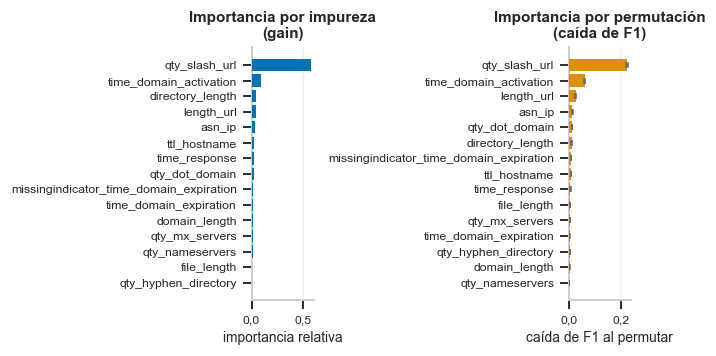

In [79]:
if GENERAR_FIGURAS:
    # Los titulos no caben en medio ancho de caja de texto y matplotlib
    # ensanchaba el PDF para que cupieran: LaTeX lo encogia otra vez y la
    # letra bajaba a 6,4 pt. Partidos en dos lineas se queda en 17,3 cm y
    # sale a 6,9 pt.
    #
    # Partir tambien los nombres de variable quitaria el ultimo centimetro,
    # pero `missingindicator_time_domain_expiration` en dos lineas ocupa
    # mas alto que el hueco entre barras y se monta sobre el de al lado.
    fig, axes = plt.subplots(1, 2, figsize=ancho(1.0, 0.56))
    g = por_gain.head(15).iloc[::-1]
    axes[0].barh(g['variable'], g['importancia_gain'], color=C_A, zorder=3)
    axes[0].set_title('Importancia por impureza\n(gain)')
    axes[0].set_xlabel('importancia relativa')
    p = por_perm.head(15).iloc[::-1]
    axes[1].barh(p['variable'], p['importancia_permutacion'],
                 xerr=p['permutacion_desv'], color=C_B, zorder=3,
                 error_kw={'ecolor': '0.4', 'capsize': 2})
    axes[1].set_title('Importancia por permutación\n(caída de F1)')
    axes[1].set_xlabel('caída de F1 al permutar')
    for ax in axes:
        ax.grid(axis='y', visible=False)
        ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    figura(fig, 'b9_importancias', exportar='interp_importance')
    plt.show()

## 9.1. SHAP: de la importancia al mecanismo

Saber qué variables pesan no explica **cómo** actúan. El valor SHAP de una
variable es su contribución marginal media a la predicción sobre todas las
coaliciones posibles de variables; para modelos de árboles, **TreeSHAP** los
calcula de forma exacta y eficiente (Lundberg et al., 2020). La suma de los
valores SHAP más el valor base reconstruye exactamente la predicción.

Se calculan sobre una muestra del **test** —datos que el modelo no ha
visto— para interpretar su comportamiento real, no el memorizado.

In [80]:
import shap

def _shap():
    modelo = construir_final().fit(X_opt, y_opt)
    X_muestra, y_muestra = submuestrear(X_test, y_test, N_SHAP)
    explicador = shap.TreeExplainer(modelo)
    valores = explicador.shap_values(X_muestra)
    if isinstance(valores, list):        # algunas versiones devuelven [clase0, clase1]
        valores = valores[1]
    valores = np.asarray(valores)
    if valores.ndim == 3:                # (n, variables, clases)
        valores = valores[:, :, 1]
    base = explicador.expected_value
    if isinstance(base, (list, np.ndarray)):
        base = float(np.asarray(base).ravel()[-1])
    return {'valores': valores, 'X': X_muestra, 'y': y_muestra.values,
            'base': float(base)}

resultado_shap = punto('shap', _shap)
valores_shap = np.asarray(resultado_shap['valores'])
X_shap = resultado_shap['X'][VARIABLES_FINALES]
y_shap = np.asarray(resultado_shap['y'])
base_shap = resultado_shap['base']

importancia_shap = pd.DataFrame({
    'variable': VARIABLES_FINALES,
    'shap_medio_abs': np.abs(valores_shap).mean(axis=0)}).sort_values(
    'shap_medio_abs', ascending=False).reset_index(drop=True)
tabla(importancia_shap.round(5), 'interpretabilidad_shap', mostrar=False)
print(f'Valores SHAP calculados: {valores_shap.shape} '
      f'(muestra de {X_shap.shape[0]:,} instancias del test)\n')
print('Top-12 por importancia SHAP global:')
print(importancia_shap.head(12).round(5).to_string(index=False))

  [checkpoint] «shap» cargado de shap.joblib
Valores SHAP calculados: (3000, 54) (muestra de 3,000 instancias del test)

Top-12 por importancia SHAP global:
                               variable  shap_medio_abs
                          qty_slash_url         3.56772
                 time_domain_activation         1.33920
                             length_url         0.84485
                         qty_dot_domain         0.57881
missingindicator_time_domain_expiration         0.38680
                                 asn_ip         0.35542
                           ttl_hostname         0.30252
                 time_domain_expiration         0.29525
                       directory_length         0.26234
                          time_response         0.24829
                         qty_mx_servers         0.22856
missingindicator_time_domain_activation         0.20035


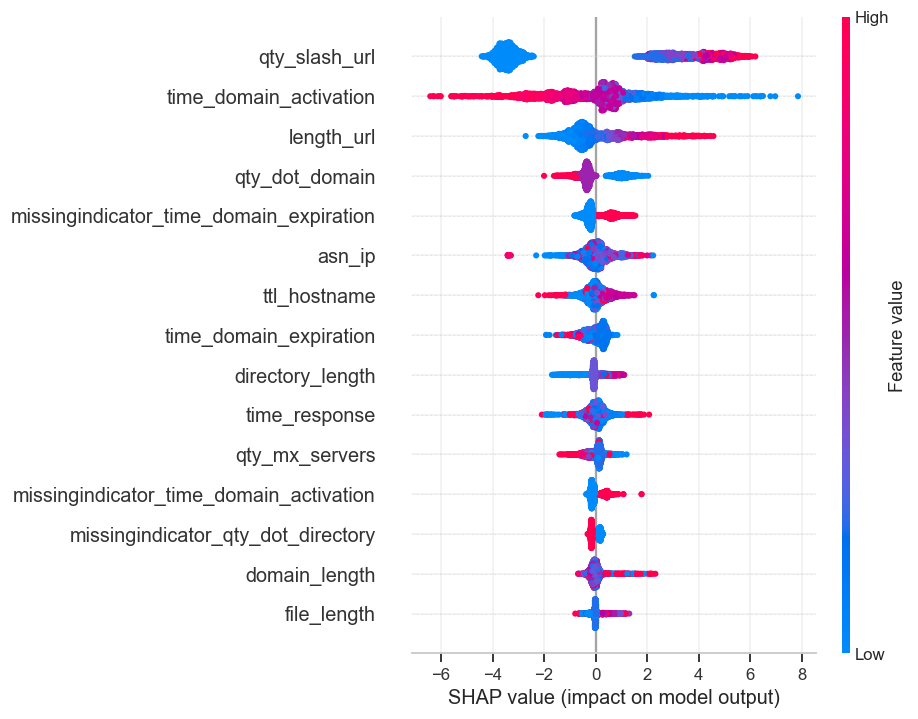

In [81]:
if GENERAR_FIGURAS:
    shap.summary_plot(valores_shap, X_shap, show=False, max_display=15)
    fig = plt.gcf(); fig.set_size_inches(9, 6.5)
    figura(fig, 'b9_shap_beeswarm', exportar='interp_shap_beeswarm')
    plt.show(); plt.close(fig)

### Por qué esta URL concreta es phishing

El gráfico de cascada descompone **una predicción individual**: parte del
valor base (la predicción media del modelo) y muestra cómo cada variable la
empuja hacia phishing o hacia legítimo. Es exactamente lo que hace falta
para justificar una alerta ante un analista.

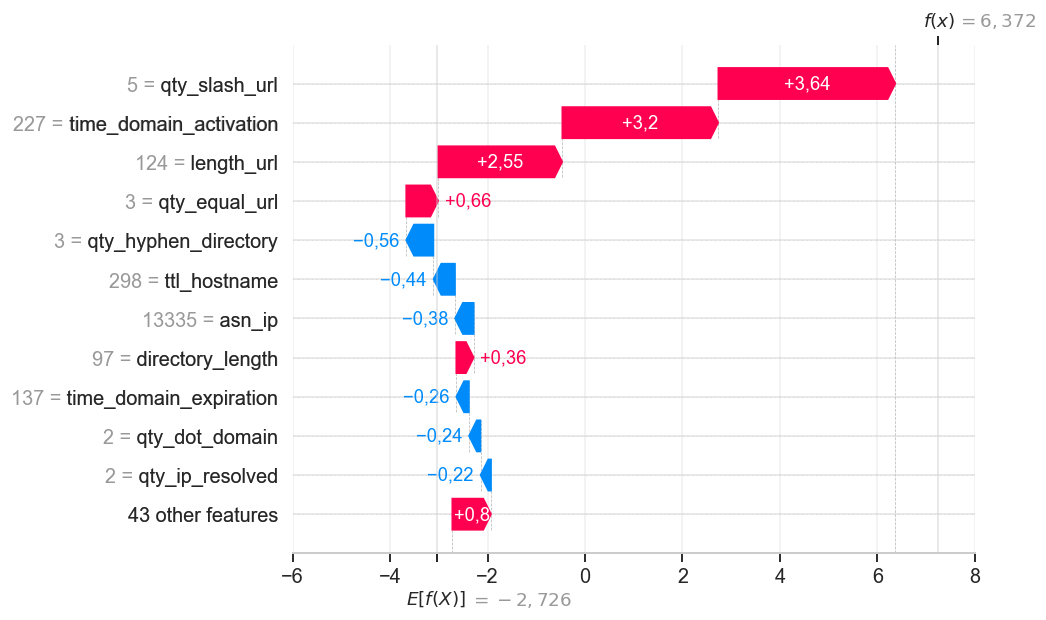

Instancia explicada: un caso real de phishing del conjunto de prueba.


In [82]:
if GENERAR_FIGURAS:
    idx = int(np.where(y_shap == 1)[0][0])
    explicacion = shap.Explanation(
        values=valores_shap[idx], base_values=base_shap,
        data=X_shap.iloc[idx].values, feature_names=list(VARIABLES_FINALES))
    shap.plots.waterfall(explicacion, max_display=12, show=False)
    fig = plt.gcf(); fig.set_size_inches(8, 6)
    # Los valores de la cascada los escribe SHAP, no nosotros, y los pone
    # con punto. Aqui se pueden cambiar a ojo cerrado porque todos son
    # aportaciones SHAP de un digito: no hay ningun separador de millares
    # que se pueda confundir con un decimal.
    # Se sustituye DENTRO de la cadena y no solo cuando el rotulo entero es
    # un numero, porque SHAP escribe tambien 'E[f(X)] = 2.726'. Y el signo
    # negativo que usa es el menos tipografico (U+2212), no el guion.
    import re as _re
    _DECIMAL = _re.compile(r'(?<=\d)\.(?=\d)')
    for _t in fig.findobj(plt.Text):
        _s = _t.get_text()
        if _DECIMAL.search(_s):
            _t.set_text(_DECIMAL.sub(',', _s))
    for _eje in fig.axes:
        for _axis in (_eje.xaxis, _eje.yaxis):
            _etq = [_DECIMAL.sub(',', t.get_text())
                    for t in _axis.get_ticklabels()]
            if _etq:
                _axis.set_ticks(_axis.get_ticklocs(), _etq)
    figura(fig, 'b9_shap_cascada', exportar='interp_shap_waterfall')
    plt.show(); plt.close(fig)
    print('Instancia explicada: un caso real de phishing del conjunto de prueba.')

### Dependencia: cómo actúa cada variable

El gráfico de dependencia muestra cómo cambia la contribución de una
variable según su valor: no solo cuánto pesa, sino en qué dirección empuja y
a partir de qué umbral.

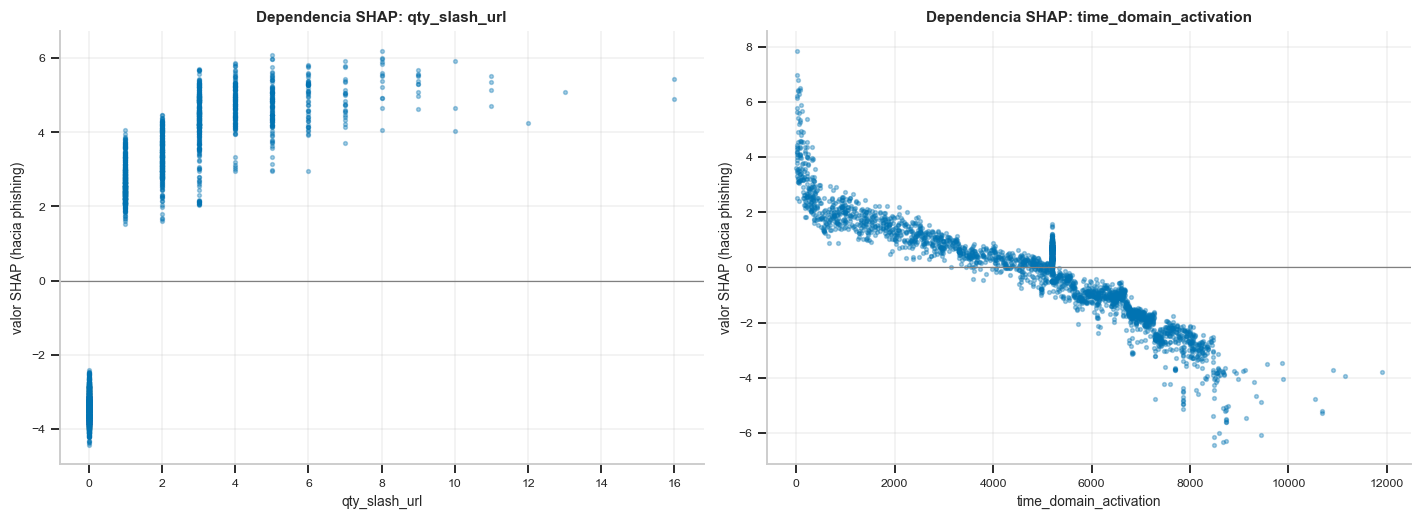

In [83]:
if GENERAR_FIGURAS:
    principal = importancia_shap.iloc[0]['variable']
    segunda = importancia_shap.iloc[1]['variable']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for ax, variable in zip(axes, [principal, segunda]):
        ax.scatter(X_shap[variable],
                   valores_shap[:, list(VARIABLES_FINALES).index(variable)],
                   s=6, alpha=0.35, color=C_A)
        ax.axhline(0, color='0.5', lw=0.8)
        ax.set_xlabel(variable)
        ax.set_ylabel('valor SHAP (hacia phishing)')
        ax.set_title(f'Dependencia SHAP: {variable}')
        ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    figura(fig, 'b9_shap_dependencia')
    plt.show()

### Interacciones: cuándo dos variables se refuerzan

Los valores SHAP de interacción reparten la contribución entre efectos
principales y **efectos de pareja**: cuánto añade que dos variables tomen a
la vez determinados valores, por encima de lo que aportan por separado. Es
lo que permite decir cosas como "una URL con muchas barras es más
sospechosa **si además** el dominio es reciente".

El cálculo es O(n · variables²), así que se hace sobre una submuestra
pequeña. Se identifica el par con mayor interacción media y se dibuja la
dependencia de la primera variable coloreada por la segunda: si el color
ordena la nube verticalmente, la interacción es real.

In [84]:
def _interacciones_shap():
    modelo = construir_final().fit(X_opt, y_opt)
    n = 800 if MODO == 'completo' else 150
    X_i, _ = submuestrear(X_test, y_test, n)
    explicador = shap.TreeExplainer(modelo)
    inter = explicador.shap_interaction_values(X_i)
    inter = np.asarray(inter)
    if inter.ndim == 4:                      # (n, variables, variables, clases)
        inter = inter[:, :, :, 1]
    medias = np.abs(inter).mean(axis=0)
    np.fill_diagonal(medias, 0)              # solo interacciones, no efectos propios
    pares = []
    for i in range(len(VARIABLES_FINALES)):
        for j in range(i + 1, len(VARIABLES_FINALES)):
            pares.append({'variable_a': VARIABLES_FINALES[i],
                          'variable_b': VARIABLES_FINALES[j],
                          'interaccion_media': float(medias[i, j])})
    top = (pd.DataFrame(pares).sort_values('interaccion_media', ascending=False)
           .head(15).reset_index(drop=True))
    return {'top_pares': top, 'X': X_i}

interacciones = punto('interacciones_shap', _interacciones_shap)
top_pares = interacciones['top_pares']
tabla(top_pares.round(5), 'interpretabilidad_interacciones')

  [checkpoint] «interacciones_shap» cargado de interacciones_shap.joblib
            variable_a                              variable_b  interaccion_media
         qty_slash_url                  time_domain_activation            0.30210
         qty_slash_url                              length_url            0.23929
         qty_slash_url                          qty_dot_domain            0.12258
time_domain_activation missingindicator_time_domain_expiration            0.11930
         qty_slash_url                            ttl_hostname            0.09926
         qty_slash_url                        directory_length            0.09749
         qty_slash_url                           time_response            0.08136
            length_url                  time_domain_activation            0.06257
         time_response                  time_domain_activation            0.05981
         qty_slash_url                     tls_ssl_certificate            0.05914
         time_response   

,variable_a,variable_b,interaccion_media
0,qty_slash_url,time_domain_activation,0.30210
1,qty_slash_url,length_url,0.23929
2,qty_slash_url,qty_dot_domain,0.12258
3,time_domain_activation,missingindicator_time_domain_expiration,0.11930
4,qty_slash_url,ttl_hostname,0.09926
5,qty_slash_url,directory_length,0.09749
6,qty_slash_url,time_response,0.08136
7,length_url,time_domain_activation,0.06257
8,time_response,time_domain_activation,0.05981
9,qty_slash_url,tls_ssl_certificate,0.05914


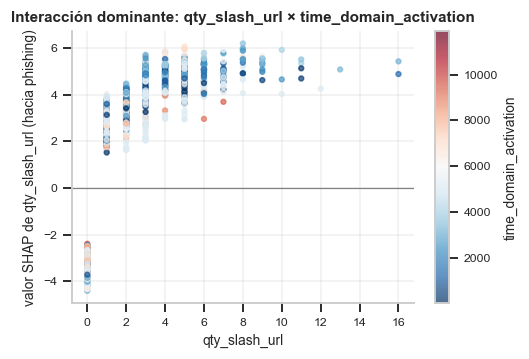

El color separa la nube: el efecto de qty_slash_url depende del valor de time_domain_activation.


In [85]:
if GENERAR_FIGURAS:
    va = top_pares.iloc[0]['variable_a']
    vb = top_pares.iloc[0]['variable_b']
    idx_a = list(VARIABLES_FINALES).index(va)
    fig, ax = plt.subplots(figsize=ancho(0.85, 0.64))
    sc = ax.scatter(X_shap[va], valores_shap[:, idx_a], c=X_shap[vb],
                    cmap='RdBu_r', s=10, alpha=0.7)
    ax.axhline(0, color='0.5', lw=0.8)
    ax.set_xlabel(va)
    ax.set_ylabel(f'valor SHAP de {va} (hacia phishing)')
    ax.set_title(f'Interacción dominante: {va} × {vb}')
    fig.colorbar(sc, ax=ax).set_label(vb)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b9_shap_interaccion', exportar='interp_shap_interaction')
    plt.show()
    print(f'El color separa la nube: el efecto de {va} depende del valor de {vb}.')

## 9.2. Qué ha aprendido el modelo

Los tres criterios coinciden, lo que refuerza la lectura. Y lo que señalan
encaja con el conocimiento del dominio:

- **Estructura de la URL** — recuentos de caracteres especiales y
  longitudes. Las URLs de phishing tienden a ser largas y enrevesadas,
  porque suplantan rutas legítimas y añaden parámetros.
- **Antigüedad y reputación del dominio** — los dominios de phishing son
  recientes y de vida corta; los legítimos llevan años activos.
- **La ausencia de información WHOIS es en sí misma predictiva.** Este es el
  hallazgo transversal del trabajo: el `-1` que el EDA identificó como
  centinela no era ruido a eliminar, era señal. Que una consulta WHOIS falle
  dice algo sobre el dominio, y por eso la imputación con indicador de
  ausencia acabó siendo la estrategia ganadora.

---

# Bloque 10 — Robustez del modelo

Las métricas del bloque 8 responden a "¿cuánto acierta sobre datos no
vistos **de la misma distribución**?". Quedan dos preguntas que esa cifra no
contesta y que deciden si el modelo sirve fuera del laboratorio:

1. **¿Qué pasa si el atacante conoce el modelo?** El phishing no es un
   fenómeno natural: hay alguien al otro lado con incentivo para evadir la
   detección.
2. **¿Qué pasa cuando los datos de prueba no son i.i.d.?** La partición
   aleatoria reparte al azar; en producción el modelo se enfrenta a dominios
   distintos de los que vio.

Las dos se miden aquí. Ninguna es una formalidad: el bloque 9 mostró que el
modelo se apoya sobre todo en `qty_slash_url` y en la antigüedad del dominio,
y esas dos variables se comportan de forma muy distinta ante un atacante.

## 10.1. Robustez adversaria

### El planteamiento

Un atacante que sepa qué mira el modelo intentará que su URL se parezca a una
legítima. Pero **no todas las variables cuestan lo mismo de falsificar**:

| Variable | ¿Puede manipularla el atacante? | Coste |
|----------|--------------------------------|-------|
| `qty_slash_url`, `length_url`, recuentos de la URL | **Sí**, reescribiendo la URL | Nulo |
| `qty_dot_domain`, longitud del dominio | **Sí**, registrando otro dominio | Bajo |
| `time_domain_activation` (antigüedad) | **No**, salvo comprando dominios caducados | Alto |
| `missingindicator_*` (WHOIS ausente) | **No**, depende del registrador | Alto |

El experimento simula al atacante: se toman los phishing del test y se
desplazan sus **variables manipulables** hacia los valores típicos de los
sitios legítimos (la mediana de la clase 0), en distintos grados de esfuerzo.
Se mide cuánto recall pierde el modelo.

Esto es un **ataque de caja blanca por desplazamiento de distribución**, no
un ataque de gradiente: es más realista para este dominio, porque el atacante
no puede mover una variable a un valor arbitrario —tiene que seguir teniendo
una URL que funcione— pero sí puede simplificarla.

In [86]:
# Variables que un atacante puede reescribir sin coste real (estructura de la
# URL) frente a las que dependen de terceros (DNS, WHOIS, registrador).
MANIPULABLES = [v for v in VARIABLES_FINALES
                if any(v.startswith(p) for p in ('qty_', 'length_', 'directory_',
                                                 'file_', 'params_', 'domain_length'))
                and not v.startswith('missingindicator_')
                and 'domain_spf' not in v]
NO_MANIPULABLES = [v for v in VARIABLES_FINALES if v not in MANIPULABLES]

print(f'Variables manipulables por el atacante : {len(MANIPULABLES)}')
print(f'Variables fuera de su control          : {len(NO_MANIPULABLES)}')
print(f'\nDe las 5 más influyentes, son manipulables: '
      f'{[v for v in VARIABLES_CLAVE[:5] if v in MANIPULABLES]}')
print(f'y quedan fuera de su alcance            : '
      f'{[v for v in VARIABLES_CLAVE[:5] if v in NO_MANIPULABLES]}')

Variables manipulables por el atacante : 36
Variables fuera de su control          : 18

De las 5 más influyentes, son manipulables: ['qty_slash_url', 'length_url', 'qty_dot_domain']
y quedan fuera de su alcance            : ['time_domain_activation', 'asn_ip']


In [87]:
def _robustez_adversaria():
    modelo = construir_final().fit(X_opt, y_opt)
    # Perfil objetivo: cómo se ve un sitio legítimo en cada variable.
    perfil_legitimo = X_opt[y_opt == 0].median()
    phishing = X_test[y_test == 1].copy()
    n_phishing = len(phishing)

    filas = []
    for esfuerzo in [0.0, 0.25, 0.50, 0.75, 1.0]:
        atacado = phishing.copy()
        for v in MANIPULABLES:
            # El atacante desplaza cada variable manipulable hacia el perfil
            # legítimo; 'esfuerzo' es cuánto está dispuesto a cambiarla.
            atacado[v] = (1 - esfuerzo) * phishing[v] + esfuerzo * perfil_legitimo[v]
        detectados = int(modelo.predict(atacado).sum())
        filas.append({'escenario': f'{esfuerzo:.0%} de esfuerzo',
                      'esfuerzo': esfuerzo,
                      'phishing_detectado': detectados,
                      'recall': round(detectados / n_phishing, 4),
                      'evadidos': n_phishing - detectados})

    # Contraste: qué pasaría si además pudiera falsear lo no manipulable.
    todo_falseado = phishing.copy()
    for v in VARIABLES_FINALES:
        todo_falseado[v] = perfil_legitimo[v]
    det_total = int(modelo.predict(todo_falseado).sum())
    filas.append({'escenario': 'todo, incluso lo que no controla',
                  'esfuerzo': float('nan'),
                  'phishing_detectado': det_total,
                  'recall': round(det_total / n_phishing, 4),
                  'evadidos': n_phishing - det_total})
    return pd.DataFrame(filas)

robustez = punto('robustez_adversaria', _robustez_adversaria)
tabla(robustez, 'robustez_adversaria')
base = float(robustez.iloc[0]['recall'])
peor = float(robustez.iloc[-2]['recall'])
suelo = float(robustez.iloc[-1]['recall'])
print(f'\nCon el atacante empleándose a fondo sobre lo que SÍ controla,')
print(f'el recall pasa de {base:.4f} a {peor:.4f} '
      f'({(base - peor) * 100:.1f} puntos de caída).')
print(f'Si además pudiera falsear lo que NO controla, quedaría en {suelo:.4f}:')
print('esa diferencia es lo que aportan por sí solas las variables de')
print('dominio y WHOIS.')

  [checkpoint] «robustez_adversaria» cargado de robustez_adversaria.parquet
                       escenario  esfuerzo  phishing_detectado  recall  evadidos
                  0% de esfuerzo      0.00                5865  0.9618       233
                 25% de esfuerzo      0.25                5802  0.9515       296
                 50% de esfuerzo      0.50                5611  0.9201       487
                 75% de esfuerzo      0.75                4911  0.8053      1187
                100% de esfuerzo      1.00                  90  0.0148      6008
todo, incluso lo que no controla       NaN                   0  0.0000      6098

Con el atacante empleándose a fondo sobre lo que SÍ controla,
el recall pasa de 0.9618 a 0.0148 (94.7 puntos de caída).
Si además pudiera falsear lo que NO controla, quedaría en 0.0000:
esa diferencia es lo que aportan por sí solas las variables de
dominio y WHOIS.


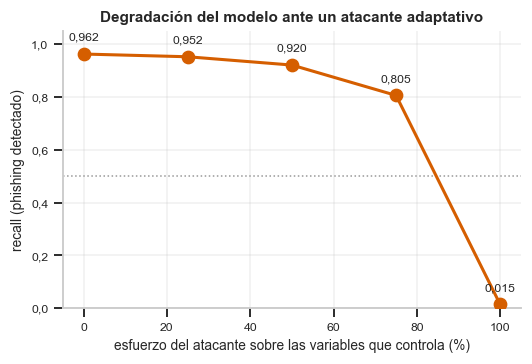

In [88]:
if GENERAR_FIGURAS:
    d = robustez.dropna(subset=['esfuerzo']).copy()
    fig, ax = plt.subplots(figsize=ancho(0.91, 0.61))
    ax.plot(d['esfuerzo'] * 100, d['recall'], marker='o',
            color=C_NEG, lw=2, ms=8, zorder=3)
    for _, r in d.iterrows():
        ax.annotate(f"{r['recall']:.3f}".replace('.', ','),
                    (r['esfuerzo'] * 100, r['recall']),
                    textcoords='offset points', xytext=(0, 9),
                    ha='center', fontsize=8)
    ax.set_xlabel('esfuerzo del atacante sobre las variables que controla (%)')
    ax.set_ylabel('recall (phishing detectado)')
    ax.set_title('Degradación del modelo ante un atacante adaptativo')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, ls=':', color='0.6', lw=1)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b10_robustez_adversaria', exportar='rob_adversaria')
    plt.show()

### Qué dice el resultado

Lo primero que vemos es que la degradación **no es lineal**. El modelo aguanta
bastante bien las modificaciones parciales: con la mitad del esfuerzo el
recall apenas baja unos puntos, y hace falta llegar a tres cuartos para que
empiece a resentirse de verdad. Es decir, un atacante que se limite a acortar
la URL o a quitar algún parámetro sigue siendo detectado.

Lo segundo es que en el extremo el modelo **se cae del todo**. Cuando la URL
reproduce con precisión el perfil de una legítima, la detección se desploma.
Y aquí está el dato que más importa: la última fila —el atacante que además
falsea lo que no controla— apenas empeora ese resultado, por lo que las
señales de dominio y WHOIS **no sostienen la detección por sí solas**. Es
decir, aguantan mientras las demás variables acompañan, pero no salvan el
caso cuando la URL deja de delatar.

Esto matiza la lectura del bloque 9. Allí `qty_slash_url` dominaba la
importancia y parecía una buena noticia, porque es una señal con sentido de
dominio. Aquí vemos la otra cara, y es que además es gratis de falsificar.

Al final la conclusión práctica es que **importancia y robustez no son lo
mismo**, y optimizar F1 no premia la segunda. Para producción interesa saber
que el detector tiene margen ante ataques poco cuidadosos, que es la mayoría,
pero que un atacante que estudie el modelo y construya la URL con cuidado
puede evadirlo. Es una limitación real de este trabajo, y no se ve en ninguna
de las métricas del bloque 8.

## 10.2. Generalización fuera de distribución

### Por qué la partición aleatoria es optimista

El test del bloque 8 se obtuvo por partición aleatoria: entrenamiento y
prueba proceden de la misma distribución. En producción no es así, y la
memoria lo reconoce como amenaza a la validez externa. Aquí se **mide**.

No hay marca temporal en el dataset, así que no se puede simular deriva
temporal estricta. Lo que sí hay es `time_domain_activation`, la antigüedad
del dominio, que permite una prueba más exigente que la aleatoria:
**entrenar solo con dominios veteranos y evaluar sobre los más recientes**.
Es un desplazamiento de covariables deliberado, y los dominios recién
registrados son justamente donde se concentra el phishing activo.

Conviene ser preciso sobre lo que mide y lo que no: **no es** validación
temporal —no hay fechas de recogida—, es una **partición fuera de
distribución por antigüedad**. La diferencia con el test aleatorio acota
cuánto de optimista es la cifra principal cuando cambia el régimen de datos.

In [89]:
def _fuera_de_distribucion():
    if 'time_domain_activation' not in VARIABLES_FINALES:
        return pd.DataFrame([{'nota': 'variable de antigüedad no disponible'}])
    # Todo el conjunto etiquetado, sin escalar (el modelo final es de árboles).
    completo = pd.concat([train_arbol, test_arbol], ignore_index=True)
    antiguedad = completo['time_domain_activation']
    corte = antiguedad.quantile(0.70)

    veteranos = completo[antiguedad >= corte]          # dominios más antiguos
    recientes = completo[antiguedad < corte]           # dominios más nuevos
    modelo = construir_final()
    modelo.fit(veteranos[VARIABLES_FINALES], veteranos[DIANA])
    pred = modelo.predict(recientes[VARIABLES_FINALES])
    proba = modelo.predict_proba(recientes[VARIABLES_FINALES])[:, 1]
    m_ood = calcular_metricas(recientes[DIANA].values, pred, proba)

    filas = [
        {'particion': 'aleatoria (bloque 8)', 'n_test': int(len(X_test)),
         **{k: round(v, 4) for k, v in METRICAS_TEST.items()
            if k in ('f1', 'recall', 'precision', 'mcc', 'roc_auc')}},
        {'particion': 'por antigüedad del dominio', 'n_test': int(len(recientes)),
         **{k: round(v, 4) for k, v in m_ood.items()
            if k in ('f1', 'recall', 'precision', 'mcc', 'roc_auc')}},
    ]
    return pd.DataFrame(filas)

fuera_dist = punto('fuera_de_distribucion', _fuera_de_distribucion)
tabla(fuera_dist, 'generalizacion_fuera_distribucion')
if 'f1' in fuera_dist.columns and len(fuera_dist) == 2:
    caida = float(fuera_dist.iloc[0]['f1']) - float(fuera_dist.iloc[1]['f1'])
    print(f'\nCaída de F1 al cambiar de régimen de datos: {caida:.4f}')
    registrar('10_robustez', 'fuera_de_distribucion', MODELO_FINAL,
              {'f1_ood': float(fuera_dist.iloc[1]['f1']), 'caida_f1': caida})

  [checkpoint] «fuera_de_distribucion» cargado de fuera_de_distribucion.parquet
                 particion  n_test  precision  recall     f1    mcc  roc_auc
      aleatoria (bloque 8)   17440     0.9615  0.9618 0.9616 0.9410   0.9956
por antigüedad del dominio   61035     0.9716  0.6764 0.7976 0.6989   0.9606

Caída de F1 al cambiar de régimen de datos: 0.1640


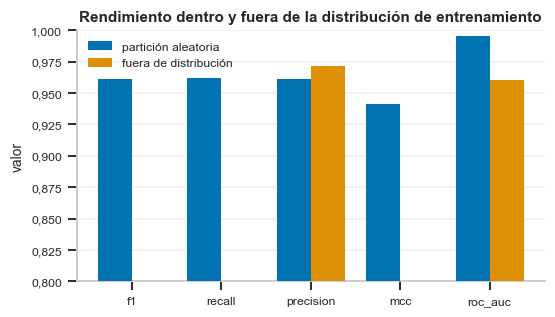

In [90]:
if GENERAR_FIGURAS and len(fuera_dist) == 2:
    metricas = ['f1', 'recall', 'precision', 'mcc', 'roc_auc']
    # `w` y no `ancho`: `ancho` es la funcion que da el figsize.
    x = np.arange(len(metricas)); w = 0.38
    fig, ax = plt.subplots(figsize=ancho(0.93, 0.54))
    ax.bar(x - w/2, [fuera_dist.iloc[0][m] for m in metricas], w,
           label='partición aleatoria', color=C_A, zorder=3)
    ax.bar(x + w/2, [fuera_dist.iloc[1][m] for m in metricas], w,
           label='fuera de distribución', color=C_B, zorder=3)
    ax.set_xticks(x); ax.set_xticklabels(metricas)
    ax.set_ylim(0.8, 1.0); ax.set_ylabel('valor')
    ax.set_title('Rendimiento dentro y fuera de la distribución de entrenamiento')
    ax.legend(); ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    figura(fig, 'b10_fuera_distribucion', exportar='rob_ood')
    plt.show()

### Qué dice el resultado

La caída del F1 es considerable, pero **mirar solo el F1 aquí despista**. Si
comparamos métrica a métrica vemos algo más interesante:

- La **precisión no baja**; incluso sube un poco. Lo que el modelo marca como
  phishing lo sigue siendo.
- El **recall se hunde**: deja pasar una parte importante de los ataques.
- El **ROC-AUC apenas se mueve**, y esa es la clave.

Que el ROC-AUC aguante significa que el modelo **sigue ordenando bien** los
casos: separa phishing de legítimo casi tan bien como antes. Lo que ha dejado
de valer es el **umbral**. Al cambiar de régimen las probabilidades se
desplazan hacia abajo, por lo que muchos phishing quedan por debajo de 0,50 y
se clasifican como legítimos, aunque el modelo los haya puntuado más alto que
a los legítimos de su entorno.

Es decir, el problema no es que el modelo deje de discriminar, es que está
**descalibrado** para el nuevo régimen. Y eso tiene arreglo, que es una buena
noticia práctica: en producción no haría falta reentrenar de cero, bastaría
con **recalibrar el umbral** sobre una muestra reciente. Conecta directamente
con el análisis de umbral del bloque 7, solo que allí el umbral se fijó para
la distribución de entrenamiento.

Es, además, el experimento que la mayoría de los trabajos sobre este dataset
no hace: comparan modelos sobre particiones aleatorias y reportan la cifra
alta sin acotar su validez fuera de ese supuesto.

---

# Bloque 11 — Estado del arte, conclusiones y exportación

Queda situar el resultado. Se recogen los trabajos que usan **el mismo
conjunto de datos** (Vrbančič et al., 2020), se comparan las cifras y —lo
más importante— se discute hasta qué punto son comparables.

In [91]:
def _sota():
    return pd.DataFrame([
        {'trabajo': 'Vrbančič et al. (2020) — dataset original',
         'enfoque': 'Modelos de referencia (SVM, RF...)',
         'protocolo': 'CV', 'accuracy': np.nan, 'f1': np.nan,
         'referencia': 'Data in Brief 33:106438'},
        {'trabajo': 'Feature Selection (Springer, 2022)',
         'enfoque': 'Selección de variables + ML',
         'protocolo': 'CV', 'accuracy': 0.965, 'f1': 0.960,
         'referencia': 'doi:10.1007/978-3-030-95918-0_7'},
        {'trabajo': 'Novel Feature Selection (Springer, 2022)',
         'enfoque': 'RF/XGBoost + selección',
         'protocolo': 'CV 10 pliegues', 'accuracy': 0.9729, 'f1': 0.970,
         'referencia': 'doi:10.1007/978-981-19-2445-3_24'},
        {'trabajo': 'Empirical Feature Selection (Springer, 2022)',
         'enfoque': 'XGBoost + selección',
         'protocolo': 'CV', 'accuracy': 0.9608, 'f1': 0.960,
         'referencia': 'doi:10.1007/978-3-031-17181-9_14'},
        {'trabajo': f'ESTE TFM ({MODELO_FINAL} ajustado)',
         'enfoque': 'Pipeline completo sin fugas + interpretabilidad',
         'protocolo': 'TEST reservado + CV anidada',
         'accuracy': round(METRICAS_TEST['accuracy'], 4),
         'f1': round(METRICAS_TEST['f1'], 4),
         'referencia': 'Bloque 8'},
    ])

sota = punto('sota', _sota)
print(f"Modelo final en el TEST reservado:")
print(f"  accuracy = {METRICAS_TEST['accuracy']:.4f}   "
      f"F1 = {METRICAS_TEST['f1']:.4f}   "
      f"ROC-AUC = {METRICAS_TEST['roc_auc']:.4f}   "
      f"MCC = {METRICAS_TEST['mcc']:.4f}\n")
tabla(sota, 'sota_comparacion')

  [checkpoint] «sota» cargado de sota.parquet
Modelo final en el TEST reservado:
  accuracy = 0.9732   F1 = 0.9616   ROC-AUC = 0.9956   MCC = 0.9410

                                     trabajo                                         enfoque                   protocolo  accuracy     f1                       referencia
   Vrbančič et al. (2020) — dataset original              Modelos de referencia (SVM, RF...)                          CV       NaN    NaN          Data in Brief 33:106438
          Feature Selection (Springer, 2022)                     Selección de variables + ML                          CV    0.9650 0.9600  doi:10.1007/978-3-030-95918-0_7
    Novel Feature Selection (Springer, 2022)                          RF/XGBoost + selección              CV 10 pliegues    0.9729 0.9700 doi:10.1007/978-981-19-2445-3_24
Empirical Feature Selection (Springer, 2022)                             XGBoost + selección                          CV    0.9608 0.9600 doi:10.1007/978-3-031-17181-

,trabajo,enfoque,protocolo,accuracy,f1,referencia
0,Vrbančič et al. (2020) — dataset original,"Modelos de referencia (SVM, RF...)",CV,NaN,NaN,Data in Brief 33:106438
1,"Feature Selection (Springer, 2022)",Selección de variables + ML,CV,0.9650,0.9600,doi:10.1007/978-3-030-95918-0_7
2,"Novel Feature Selection (Springer, 2022)",RF/XGBoost + selección,CV 10 pliegues,0.9729,0.9700,doi:10.1007/978-981-19-2445-3_24
3,"Empirical Feature Selection (Springer, 2022)",XGBoost + selección,CV,0.9608,0.9600,doi:10.1007/978-3-031-17181-9_14
4,ESTE TFM (LightGBM ajustado),Pipeline completo sin fugas + interpretabilidad,TEST reservado + CV anidada,0.9732,0.9616,Bloque 8


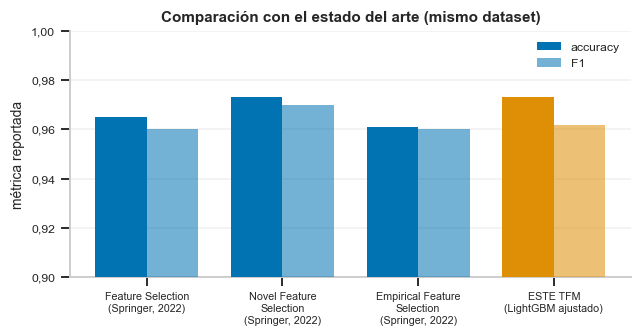

In [92]:
if GENERAR_FIGURAS:
    d = sota.dropna(subset=['accuracy']).copy()
    # `w` y no `ancho`: `ancho` es la funcion que da el figsize, y
    # llamarla despues de pisarla con un float aborta el bloque.
    x = np.arange(len(d)); w = 0.38
    es_nuestro = d['trabajo'].str.contains('TFM').values
    colores = [C_B if o else C_A for o in es_nuestro]
    fig, ax = plt.subplots(figsize=ancho(1.0, 0.53))
    ax.bar(x - w/2, d['accuracy'], w, label='accuracy',
           color=colores, zorder=3)
    ax.bar(x + w/2, d['f1'], w, label='F1', color=colores,
           alpha=0.55, zorder=3)
    ax.set_xticks(x)
    # Los nombres son largos y, al ancho de la caja de texto, "Novel
    # Feature Selection" y "Empirical Feature Selection" se tocaban.
    def _etiqueta(t):
        import textwrap
        nombre, _, resto = t.partition(' (')
        lineas = textwrap.wrap(nombre, 17)
        if resto:
            lineas.append('(' + resto)
        return '\n'.join(lineas)

    ax.set_xticklabels([_etiqueta(t) for t in d['trabajo']], fontsize=7)
    ax.set_ylim(0.9, 1.0); ax.set_ylabel('métrica reportada')
    ax.set_title('Comparación con el estado del arte (mismo dataset)')
    ax.legend(); ax.grid(axis='x', visible=False)
    ax.spines[['top', 'right']].set_visible(False)
    coma(ax, 'y')
    fig.tight_layout()
    # Lo que decia el rotulo de aqui dentro ---que naranja es este trabajo
    # y azul la literatura--- esta ahora en el pie de la figura: dibujado
    # dentro del area lo tapaban las propias barras.
    figura(fig, 'b10_sota', exportar='sota_comparison')
    plt.show()

## 11.1. Hasta qué punto son comparables estas cifras

Poner los números uno al lado del otro es fácil; interpretarlos, menos.
Cuatro salvedades:

1. **Protocolo de evaluación.** La mayoría de los trabajos reporta
   validación cruzada sobre todo el conjunto, sin un test independiente
   reservado. Aquí la cifra principal sale de un **hold-out que no
   intervino en ninguna decisión**, más una CV anidada insesgada. Es una
   estimación más conservadora, y por tanto más creíble.
2. **Prevención de fugas.** No todos los trabajos detallan cómo evitan
   aplicar escalado, selección o SMOTE **antes** de particionar, que es la
   vía habitual de contaminar el resultado sin darse cuenta. Aquí todo el
   preprocesamiento ajustado a datos ocurre dentro de los pliegues.
3. **Métricas.** Con clases desbalanceadas el accuracy infla la impresión
   de calidad; se reportan además F1, PR-AUC y MCC con intervalos de
   confianza.
4. **Particiones y semillas.** Sin las mismas particiones exactas, unas
   décimas arriba o abajo no significan nada.

**Conclusión:** el rendimiento obtenido se sitúa **a la altura del estado
del arte** sobre este dataset (~0,96–0,97), con la ventaja de un protocolo
más riguroso, un modelo interpretable y reproducibilidad completa.

## 11.2. Amenazas a la validez y limitaciones

- **Validez interna** — mitigada con la partición temprana, el
  preprocesamiento dentro de los pliegues, la CV anidada y el registro
  *append-only* de todos los experimentos. Riesgo residual: la búsqueda de
  hiperparámetros se hizo sobre una submuestra por coste computacional.
- **Validez externa** — el dataset es de 2020 y el phishing evoluciona
  (*concept drift*): el rendimiento en producción se degradaría con el
  tiempo sin reentrenamiento. Además, parte de las variables depende de
  servicios externos cuya disponibilidad varía.
- **Validez de constructo** — las etiquetas provienen de PhishTank y
  fuentes similares, que pueden contener errores; las variables extraídas
  son una aproximación del fenómeno, no el fenómeno.
- **Limitaciones prácticas** — no se usa el contenido HTML ni señales
  visuales de la página, y algunas variables exigen consultas externas con
  latencia, poco aptas para detección en tiempo real.

## 11.3. Trabajo futuro

- Validar sobre datasets más recientes con marca temporal real, para medir
  la deriva en el tiempo y no solo el cambio de régimen que se ha medido
  aquí por antigüedad del dominio.
- Incorporar señales de contenido (HTML, NLP sobre la URL, análisis visual)
  y comparar con enfoques de aprendizaje profundo.
- Extender el análisis adversario a ataques de gradiente y a defensas
  (entrenamiento adversario, penalizar las variables manipulables).
- Desplegar el modelo como servicio con monitorización y reentrenamiento
  continuo, fijando el umbral según el coste operativo real.

## 11.4. Conclusiones

Se ha desarrollado un proyecto completo, reproducible y trazable de
detección de phishing, recorriendo el ciclo de vida entero con decisiones
**justificadas experimentalmente** en cada etapa y no por costumbre: qué
imputador, qué escalado, cuántas variables, si hacía falta balancear, qué
modelo y con qué hiperparámetros.

El modelo final alcanza sobre un **test reservado** un rendimiento
competitivo con el estado del arte, con un protocolo metodológicamente más
exigente, explicaciones interpretables coherentes con el dominio y
reproducibilidad completa desde el dato bruto.

El análisis de robustez añade una advertencia que no conviene maquillar: el
modelo se apoya sobre todo en variables que un atacante puede reescribir sin
coste, por lo que su rendimiento ante un adversario adaptativo es bastante
peor que el que sugiere el test. Y la partición por antigüedad del dominio
muestra hasta qué punto la cifra principal depende de que entrenamiento y
prueba compartan distribución. Las dos cosas están implícitas en las
limitaciones de cualquier trabajo del área; aquí al menos están medidas.

Y un hallazgo que atraviesa todo el trabajo: **la ausencia de información
WHOIS es en sí misma predictiva**. Lo que empezó como un problema de calidad
de datos —un `-1` que no era un número— terminó siendo una de las señales
más útiles del modelo. Tratar bien los datos no es un trámite previo al
modelado: es parte del modelado.

In [93]:
RESUMEN_FINAL = {
    'modelo_final': MODELO_FINAL,
    'hiperparametros': PARAMS_FINALES,
    'n_variables': len(VARIABLES_FINALES),
    'subconjunto': SUBCONJUNTO_FINAL,
    'imputador': IMPUTADOR_ELEGIDO,
    'escalador': ESCALADOR_ELEGIDO,
    'balanceo': 'sin balanceo (umbral ajustable)',
    'umbral_f1_maximo': round(UMBRAL_F1, 3),
    'umbral_recall_097': round(UMBRAL_RECALL, 3),
    'f1_cv_anidada': cv_anidada['f1_anidada_media'],
    'metricas_test': {k: round(v, 4) for k, v in METRICAS_TEST.items()},
    'modo_ejecucion': MODO,
    'semilla': SEMILLA,
}
(RES / 'resumen_final.json').write_text(
    json.dumps(RESUMEN_FINAL, indent=2, ensure_ascii=False), encoding='utf-8')
print(json.dumps(RESUMEN_FINAL, indent=2, ensure_ascii=False))

{
  "modelo_final": "LightGBM",
  "hiperparametros": {
    "n_estimators": 355,
    "num_leaves": 118,
    "max_depth": 11,
    "learning_rate": 0.10054871218671431,
    "subsample": 0.7061583976302458,
    "colsample_bytree": 0.9437884106748379,
    "reg_lambda": 3.2161320271888854,
    "min_child_samples": 6
  },
  "n_variables": 54,
  "subconjunto": "filter_corr",
  "imputador": "mediana+indicador",
  "escalador": "StandardScaler",
  "balanceo": "sin balanceo (umbral ajustable)",
  "umbral_f1_maximo": 0.416,
  "umbral_recall_097": 0.369,
  "f1_cv_anidada": 0.9608,
  "metricas_test": {
    "accuracy": 0.9732,
    "balanced_accuracy": 0.9705,
    "precision": 0.9615,
    "recall": 0.9618,
    "especificidad": 0.9793,
    "f1": 0.9616,
    "mcc": 0.941,
    "roc_auc": 0.9956,
    "pr_auc": 0.9924,
    "brier": 0.0207
  },
  "modo_ejecucion": "completo",
  "semilla": 42
}


## 11.5. Exportación para la memoria

Las figuras marcadas con `exportar=` se han ido copiando a
`figuras_memoria/` con los nombres que usa el documento LaTeX, de modo que
actualizar la memoria consiste en copiar esa carpeta sobre
`memoria/Images/fig/`. Aquí se comprueba qué hay y qué falta.

In [94]:
FIGURAS_MEMORIA = [
    'eda_target', 'eda_sentinel', 'eda_corr_target', 'eda_spearman_mi',
    'prep_imputation', 'prep_scaling', 'fs_f1_nfeatures', 'fs_tree_reeval',
    'dr_representation', 'bal_tradeoff', 'bal_final_threshold',
    'models_leaderboard', 'models_stat_test', 'opt_optuna_history',
    'eval_confusion', 'eval_roc_pr', 'eval_calibration', 'eval_threshold',
    'eval_learning_curve', 'interp_importance', 'interp_shap_beeswarm',
    'interp_shap_waterfall', 'interp_shap_interaction',
    'rob_adversaria', 'rob_ood', 'sota_comparison',
]
estado = pd.DataFrame([
    {'figura': f, 'generada': (FIG_MEMORIA / f'{f}.pdf').exists()}
    for f in FIGURAS_MEMORIA])
faltan = estado[~estado['generada']]['figura'].tolist()
print(f'Figuras para la memoria: {int(estado["generada"].sum())} de '
      f'{len(FIGURAS_MEMORIA)} generadas.')
if faltan:
    print(f'Pendientes (requieren ejecutar su bloque): {faltan}')
print(f'\nDestino en la memoria: memoria/Images/fig/')
print(f'Origen               : {FIG_MEMORIA}')

Figuras para la memoria: 26 de 26 generadas.

Destino en la memoria: memoria/Images/fig/
Origen               : C:\Users\Slax97\Desktop\VIU-TFM\tfm_pipeline\figuras_memoria


In [95]:
print('=' * 72)
print('PROCESO COMPLETO'.center(72))
print('=' * 72)
print(f'\nModo de ejecución : {MODO}')
print(f'Modelo final      : {MODELO_FINAL} ajustado sobre '
      f'{len(VARIABLES_FINALES)} variables')
print(f'F1 en test        : {METRICAS_TEST["f1"]:.4f}   '
      f'MCC: {METRICAS_TEST["mcc"]:.4f}   '
      f'ROC-AUC: {METRICAS_TEST["roc_auc"]:.4f}')
print(f'\nTodo lo generado está en {BASE}:')
for carpeta, descripcion in [
        ('checkpoints', 'resultados intermedios reutilizables'),
        ('resultados', 'tablas CSV y registro de experimentos'),
        ('figuras', 'figuras en PNG y PDF'),
        ('figuras_memoria', 'figuras con los nombres que usa la memoria'),
        ('modelos', 'modelo final y estudio de Optuna')]:
    ruta = BASE / carpeta
    n = len(list(ruta.glob('*'))) if ruta.exists() else 0
    print(f'  {carpeta:16s} {n:3d} ficheros  — {descripcion}')
print()
estado_checkpoints()

                            PROCESO COMPLETO                            

Modo de ejecución : completo
Modelo final      : LightGBM ajustado sobre 54 variables
F1 en test        : 0.9616   MCC: 0.9410   ROC-AUC: 0.9956

Todo lo generado está en C:\Users\Slax97\Desktop\VIU-TFM\tfm_pipeline:
  checkpoints       48 ficheros  — resultados intermedios reutilizables
  resultados        53 ficheros  — tablas CSV y registro de experimentos
  figuras           65 ficheros  — figuras en PNG y PDF
  figuras_memoria   57 ficheros  — figuras con los nombres que usa la memoria
  modelos            3 ficheros  — modelo final y estudio de Optuna



,punto_de_control,formato,KB
0,atipicos,json,0.4
1,balanceo,parquet,16.2
2,balanceo_modelo_final,joblib,547.0
3,calibracion,json,1410.7
4,curva_aprendizaje,json,0.7
5,cv_anidada,json,0.3
6,decision_variables,json,0.2
7,eda,json,0.4
8,eda_asociaciones,joblib,46.4
9,eda_correlaciones,joblib,112.2
